In [1]:
# CELULA 1 - Configurare cai principale, split-uri si augmentari

from pathlib import Path
import os
import shutil
import numpy as np
import pandas as pd

DATASET_ROOT = Path(
    r"D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset"
)

TVT_ROOT = DATASET_ROOT / "TVT"

TRAINING_DIR = TVT_ROOT / "training"
VALIDATION_DIR = TVT_ROOT / "validation"
TESTING_DIR = TVT_ROOT / "testing"

MODELE_DIR = DATASET_ROOT / "modele_v2"
MODELE_DIR.mkdir(parents=True, exist_ok=True)

EXERCISES = ["e6", "e7", "e8"]
AUGMENTATION_VARIANTS = ["p1", "p2", "p3"]

SPLIT_DIRS = {
    "training": TRAINING_DIR,
    "validation": VALIDATION_DIR,
    "testing": TESTING_DIR,
}

ORIGINAL_SUBJECT_SPLIT = {
    "s2": "training",
    "s3": "training",
    "s4": "training",
    "s11": "training",
    "s12": "training",

    "s13": "validation",

    "s5": "testing",
    "s14": "testing",
}

AUGMENTED_JOBS = [
    # Augmentari existente deja in structura originala din ZIP
    {"source_subject": "s2", "variant": "p1", "target_split": "validation"},
    {"source_subject": "s2", "variant": "p2", "target_split": "training"},
    {"source_subject": "s2", "variant": "p3", "target_split": "training"},

    {"source_subject": "s3", "variant": "p1", "target_split": "training"},
    {"source_subject": "s3", "variant": "p2", "target_split": "validation"},
    {"source_subject": "s3", "variant": "p3", "target_split": "training"},

    {"source_subject": "s4", "variant": "p1", "target_split": "training"},
    {"source_subject": "s4", "variant": "p2", "target_split": "training"},
    {"source_subject": "s4", "variant": "p3", "target_split": "validation"},

    {"source_subject": "s5", "variant": "p1", "target_split": "testing"},
    {"source_subject": "s5", "variant": "p2", "target_split": "testing"},
    {"source_subject": "s5", "variant": "p3", "target_split": "testing"},

    # Augmentari noi pentru pacientii noi
    {"source_subject": "s11", "variant": "p1", "target_split": "training"},
    {"source_subject": "s11", "variant": "p2", "target_split": "training"},
    {"source_subject": "s11", "variant": "p3", "target_split": "training"},

    {"source_subject": "s12", "variant": "p1", "target_split": "training"},
    {"source_subject": "s12", "variant": "p2", "target_split": "training"},
    {"source_subject": "s12", "variant": "p3", "target_split": "training"},

    {"source_subject": "s13", "variant": "p1", "target_split": "validation"},
    {"source_subject": "s13", "variant": "p2", "target_split": "validation"},
    {"source_subject": "s13", "variant": "p3", "target_split": "validation"},

    {"source_subject": "s14", "variant": "p1", "target_split": "testing"},
    {"source_subject": "s14", "variant": "p2", "target_split": "testing"},
    {"source_subject": "s14", "variant": "p3", "target_split": "testing"},
]

print("DATASET_ROOT:", DATASET_ROOT)
print("TVT_ROOT:", TVT_ROOT)
print("TRAINING_DIR:", TRAINING_DIR)
print("VALIDATION_DIR:", VALIDATION_DIR)
print("TESTING_DIR:", TESTING_DIR)
print("MODELE_DIR:", MODELE_DIR)

DATASET_ROOT: D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset
TVT_ROOT: D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\TVT
TRAINING_DIR: D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\TVT\training
VALIDATION_DIR: D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\TVT\validation
TESTING_DIR: D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\TVT\testing
MODELE_DIR: D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\modele_v2


In [2]:
# CELULA 2 - Functii pentru obtinerea cailor originale si augmentate

def get_original_subject_dir(subject):
    split_name = ORIGINAL_SUBJECT_SPLIT[subject]
    return SPLIT_DIRS[split_name] / subject


def get_augmented_subject_name(source_subject, variant):
    return f"{source_subject}_{variant}"


def get_augmented_subject_dir(source_subject, variant, target_split):
    augmented_subject_name = get_augmented_subject_name(source_subject, variant)
    return SPLIT_DIRS[target_split] / "augmented" / augmented_subject_name


def get_augmented_root(split_name):
    return SPLIT_DIRS[split_name] / "augmented"


def ensure_augmented_roots_exist():
    for split_name in ["training", "validation", "testing"]:
        augmented_root = get_augmented_root(split_name)
        augmented_root.mkdir(parents=True, exist_ok=True)
        print(f"Folder verificat: {augmented_root}")


ensure_augmented_roots_exist()

Folder verificat: D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\TVT\training\augmented
Folder verificat: D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\TVT\validation\augmented
Folder verificat: D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\TVT\testing\augmented


In [3]:
# CELULA 3 - Verificare structura originala si augmentari existente

def count_files_in_folder(folder_path):
    if not folder_path.exists():
        return 0

    return sum(
        1 for item in folder_path.rglob("*")
        if item.is_file()
    )


def check_original_subjects():
    print("=" * 80)
    print("VERIFICARE FOLDERE ORIGINALE")
    print("=" * 80)

    for subject, split_name in ORIGINAL_SUBJECT_SPLIT.items():
        subject_dir = get_original_subject_dir(subject)
        status = "EXISTA" if subject_dir.exists() else "LIPSESTE"
        file_count = count_files_in_folder(subject_dir)

        print(f"{subject:>4} | {split_name:<10} | {status:<8} | fisiere: {file_count:<4} | {subject_dir}")


def check_augmented_subjects():
    print("=" * 80)
    print("VERIFICARE FOLDERE AUGMENTED")
    print("=" * 80)

    for job in AUGMENTED_JOBS:
        source_subject = job["source_subject"]
        variant = job["variant"]
        target_split = job["target_split"]

        augmented_subject_name = get_augmented_subject_name(source_subject, variant)
        augmented_subject_dir = get_augmented_subject_dir(source_subject, variant, target_split)

        status = "EXISTA" if augmented_subject_dir.exists() else "LIPSESTE"
        file_count = count_files_in_folder(augmented_subject_dir)

        print(
            f"{augmented_subject_name:>7} | {target_split:<10} | "
            f"{status:<8} | fisiere: {file_count:<4} | {augmented_subject_dir}"
        )


check_original_subjects()
print()
check_augmented_subjects()

VERIFICARE FOLDERE ORIGINALE
  s2 | training   | EXISTA   | fisiere: 94   | D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\TVT\training\s2
  s3 | training   | EXISTA   | fisiere: 88   | D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\TVT\training\s3
  s4 | training   | EXISTA   | fisiere: 88   | D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\TVT\training\s4
 s11 | training   | EXISTA   | fisiere: 14   | D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\TVT\training\s11
 s12 | training   | EXISTA   | fisiere: 14   | D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\TVT\training\s12
 s13 | validation | EXISTA   | fisiere: 14   | D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\TVT\validation\s13
  s5 | testi

In [4]:
# CELULA 4 - Configurare fisiere si coloane pentru augmentare

SENSOR = "u2"

SIGNAL_COLUMNS = [
    "acc_x",
    "acc_y",
    "acc_z",
    "gyr_x",
    "gyr_y",
    "gyr_z",
]

PERCENT_FACTOR = 0.02
RANDOM_SEED = 42

# False inseamna ca nu suprascriem augmentarile deja existente
OVERWRITE_AUGMENTED = False


def get_template_time_files(exercise_dir):
    """
    Gaseste fisierele de tip template_times din folderul exercitiului.
    Functioneaza atat pentru:
    - template_times.txt
    - template_times_long.txt
    - template_times_scrt.txt
    - template_times_scrt_v2.txt
    """

    if not exercise_dir.exists():
        return []

    return sorted(
        [
            file_path
            for file_path in exercise_dir.glob("template_times*.txt")
            if file_path.is_file()
        ]
    )


def get_signal_files(sensor_dir):
    """
    Gaseste fisierele TXT de semnal din folderul senzorului u2.
    Functioneaza atat pentru formatul vechi:
    - template_session.txt
    - test.txt

    cat si pentru formatul nou:
    - ex6_long_...txt
    - ex6_scrt_...txt
    - ex7_scrt_v2_...txt
    """

    if not sensor_dir.exists():
        return []

    return sorted(
        [
            file_path
            for file_path in sensor_dir.glob("*.txt")
            if file_path.is_file()
        ]
    )

In [5]:
# CELULA 5 - Verificare augmentari complete sau lipsa

def get_expected_augmented_files(source_subject, variant, target_split):
    """
    Construieste lista fisierelor care trebuie sa existe
    pentru o augmentare completa.
    """

    source_subject_dir = get_original_subject_dir(source_subject)
    target_subject_dir = get_augmented_subject_dir(
        source_subject,
        variant,
        target_split,
    )

    expected_files = []

    for exercise in EXERCISES:
        source_exercise_dir = source_subject_dir / exercise
        source_sensor_dir = source_exercise_dir / SENSOR

        target_exercise_dir = target_subject_dir / exercise
        target_sensor_dir = target_exercise_dir / SENSOR

        template_time_files = get_template_time_files(source_exercise_dir)
        signal_files = get_signal_files(source_sensor_dir)

        for source_file in template_time_files:
            expected_files.append({
                "source_file": source_file,
                "target_file": target_exercise_dir / source_file.name,
                "file_type": "template_times",
                "exercise": exercise,
            })

        for source_file in signal_files:
            expected_files.append({
                "source_file": source_file,
                "target_file": target_sensor_dir / source_file.name,
                "file_type": "signal",
                "exercise": exercise,
            })

    return expected_files


def check_single_augmentation_job(job):
    source_subject = job["source_subject"]
    variant = job["variant"]
    target_split = job["target_split"]

    augmented_subject_name = get_augmented_subject_name(
        source_subject,
        variant,
    )

    expected_files = get_expected_augmented_files(
        source_subject,
        variant,
        target_split,
    )

    missing_files = [
        item
        for item in expected_files
        if not item["target_file"].exists()
    ]

    source_missing_files = [
        item
        for item in expected_files
        if not item["source_file"].exists()
    ]

    is_complete = (
        len(expected_files) > 0
        and len(missing_files) == 0
        and len(source_missing_files) == 0
    )

    return {
        "augmented_subject": augmented_subject_name,
        "source_subject": source_subject,
        "variant": variant,
        "target_split": target_split,
        "expected_files": len(expected_files),
        "missing_files": len(missing_files),
        "source_missing_files": len(source_missing_files),
        "is_complete": is_complete,
        "target_folder": str(
            get_augmented_subject_dir(
                source_subject,
                variant,
                target_split,
            )
        ),
    }


def check_all_augmentation_jobs():
    results = []

    for job in AUGMENTED_JOBS:
        results.append(
            check_single_augmentation_job(job)
        )

    return pd.DataFrame(results)


augmentation_status_df = check_all_augmentation_jobs()

display(augmentation_status_df)

,augmented_subject,source_subject,variant,target_split,expected_files,missing_files,source_missing_files,is_complete,target_folder
0,s2_p1,s2,p1,validation,9,0,0,True,D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\a...
1,s2_p2,s2,p2,training,9,0,0,True,D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\a...
2,s2_p3,s2,p3,training,9,0,0,True,D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\a...
3,s3_p1,s3,p1,training,9,0,0,True,D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\a...
4,s3_p2,s3,p2,validation,9,0,0,True,D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\a...
5,s3_p3,s3,p3,training,9,0,0,True,D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\a...
6,s4_p1,s4,p1,training,9,0,0,True,D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\a...
7,s4_p2,s4,p2,training,9,0,0,True,D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\a...
8,s4_p3,s4,p3,validation,9,0,0,True,D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\a...
9,s5_p1,s5,p1,testing,9,0,0,True,D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\a...


In [6]:
# CELULA 6 - Selectare augmentari care trebuie generate

jobs_to_generate = []

for job in AUGMENTED_JOBS:
    status = check_single_augmentation_job(job)

    if status["is_complete"]:
        print(
            f"SARIM: {status['augmented_subject']} exista deja complet in {status['target_split']}/augmented"
        )
    else:
        print(
            f"GENERAM: {status['augmented_subject']} in {status['target_split']}/augmented "
            f"(lipsesc {status['missing_files']} din {status['expected_files']} fisiere)"
        )

        jobs_to_generate.append(job)


print("=" * 80)
print("Numar augmentari care trebuie generate:", len(jobs_to_generate))

for job in jobs_to_generate:
    augmented_subject_name = get_augmented_subject_name(
        job["source_subject"],
        job["variant"],
    )

    print(
        f"{augmented_subject_name} -> {job['target_split']}/augmented"
    )

SARIM: s2_p1 exista deja complet in validation/augmented
SARIM: s2_p2 exista deja complet in training/augmented
SARIM: s2_p3 exista deja complet in training/augmented
SARIM: s3_p1 exista deja complet in training/augmented
SARIM: s3_p2 exista deja complet in validation/augmented
SARIM: s3_p3 exista deja complet in training/augmented
SARIM: s4_p1 exista deja complet in training/augmented
SARIM: s4_p2 exista deja complet in training/augmented
SARIM: s4_p3 exista deja complet in validation/augmented
SARIM: s5_p1 exista deja complet in testing/augmented
SARIM: s5_p2 exista deja complet in testing/augmented
SARIM: s5_p3 exista deja complet in testing/augmented
GENERAM: s11_p1 in training/augmented (lipsesc 14 din 14 fisiere)
GENERAM: s11_p2 in training/augmented (lipsesc 14 din 14 fisiere)
GENERAM: s11_p3 in training/augmented (lipsesc 14 din 14 fisiere)
GENERAM: s12_p1 in training/augmented (lipsesc 14 din 14 fisiere)
GENERAM: s12_p2 in training/augmented (lipsesc 14 din 14 fisiere)
GENERAM

In [7]:
# CELULA 7 - Functii pentru citirea si salvarea fisierelor TXT

import hashlib


NEW_SUBJECTS = ["s11", "s12", "s13", "s14"]

MAG_COLUMNS = [
    "mag_x",
    "mag_y",
    "mag_z",
]

NEW_SUBJECT_OUTPUT_COLUMNS = SIGNAL_COLUMNS + MAG_COLUMNS


def citeste_fisier_semnale(cale_fisier, source_subject):
    """
    Citeste un fisier TXT cu separator punct si virgula.

    Pentru pacientii noi s11, s12, s13, s14, pastreaza doar coloanele:
    acc_x, acc_y, acc_z, gyr_x, gyr_y, gyr_z, mag_x, mag_y, mag_z.

    Pentru pacientii vechi, pastreaza toate coloanele existente.
    Augmentarea se aplica doar pe acc si gyr.
    """

    df = pd.read_csv(
        cale_fisier,
        sep=";",
    )

    df.columns = df.columns.str.strip()

    if source_subject in NEW_SUBJECTS:
        coloane_lipsa = [
            coloana
            for coloana in NEW_SUBJECT_OUTPUT_COLUMNS
            if coloana not in df.columns
        ]

        if len(coloane_lipsa) > 0:
            raise ValueError(
                f"Fisierul {cale_fisier} nu contine coloanele necesare: {coloane_lipsa}"
            )

        df = df[
            NEW_SUBJECT_OUTPUT_COLUMNS
        ].copy()

    return df


def salveaza_fisier_semnale(df, cale_fisier):
    """
    Salveaza un fisier TXT cu separator punct si virgula.
    """

    cale_fisier.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    df.to_csv(
        cale_fisier,
        sep=";",
        index=False,
        float_format="%.10f",
    )


def copiaza_fisier(cale_sursa, cale_destinatie):
    """
    Copiaza un fisier fara modificari.
    Este folosita pentru template_times*.txt.
    """

    cale_destinatie.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    shutil.copy2(
        cale_sursa,
        cale_destinatie,
    )

In [8]:
# CELULA 8 - Functii pentru generarea variantelor augmentate p1, p2 si p3

def get_deterministic_seed(text):
    """
    Creeaza un seed stabil pentru fiecare fisier si fiecare varianta.
    Astfel, p1 ramane reproductibil.
    """

    text_encoded = text.encode("utf-8")

    digest = hashlib.md5(
        text_encoded
    ).hexdigest()

    seed_int = int(
        digest[:8],
        16,
    )

    return RANDOM_SEED + seed_int


def verifica_coloane_semnal(df, cale_fisier):
    """
    Verifica daca fisierul contine coloanele necesare pentru augmentare.
    Se verifica doar coloanele acc si gyr.
    """

    coloane_lipsa = [
        coloana
        for coloana in SIGNAL_COLUMNS
        if coloana not in df.columns
    ]

    if len(coloane_lipsa) > 0:
        raise ValueError(
            f"Fisierul {cale_fisier} nu contine coloanele necesare pentru augmentare: {coloane_lipsa}"
        )


def genereaza_dataframe_augmentat(df_original, varianta, random_key):
    """
    Genereaza un dataframe augmentat pentru varianta ceruta.

    Se modifica doar coloanele:
    acc_x, acc_y, acc_z, gyr_x, gyr_y, gyr_z.

    Coloanele mag_x, mag_y, mag_z raman in fisier,
    dar nu sunt modificate.
    """

    df_nou = df_original.copy()

    valori_originale = df_original[
        SIGNAL_COLUMNS
    ].to_numpy(
        dtype=float,
    )

    if varianta == "p1":
        seed = get_deterministic_seed(
            random_key
        )

        generator_random = np.random.default_rng(
            seed
        )

        procente_random = generator_random.uniform(
            low=-PERCENT_FACTOR,
            high=PERCENT_FACTOR,
            size=valori_originale.shape,
        )

        valori_noi = valori_originale * (
            1.0 + procente_random
        )

    elif varianta == "p2":
        valori_noi = valori_originale * (
            1.0 + PERCENT_FACTOR
        )

    elif varianta == "p3":
        valori_noi = valori_originale * (
            1.0 - PERCENT_FACTOR
        )

    else:
        raise ValueError(
            f"Varianta necunoscuta: {varianta}"
        )

    df_nou.loc[
        :,
        SIGNAL_COLUMNS,
    ] = valori_noi

    return df_nou

In [9]:
# CELULA 9 - Functie pentru generarea unui singur folder augmentat

def genereaza_un_job_augmentare(job):
    source_subject = job["source_subject"]
    variant = job["variant"]
    target_split = job["target_split"]

    source_subject_dir = get_original_subject_dir(
        source_subject
    )

    target_subject_dir = get_augmented_subject_dir(
        source_subject,
        variant,
        target_split,
    )

    augmented_subject_name = get_augmented_subject_name(
        source_subject,
        variant,
    )

    if not source_subject_dir.exists():
        raise FileNotFoundError(
            f"Folderul original nu exista: {source_subject_dir}"
        )

    target_subject_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    numar_template_copiate = 0
    numar_semnale_generate = 0
    numar_fisiere_sarite = 0

    for exercise in EXERCISES:
        source_exercise_dir = (
            source_subject_dir
            / exercise
        )

        source_sensor_dir = (
            source_exercise_dir
            / SENSOR
        )

        target_exercise_dir = (
            target_subject_dir
            / exercise
        )

        target_sensor_dir = (
            target_exercise_dir
            / SENSOR
        )

        if not source_exercise_dir.exists():
            print(
                f"ATENTIE: lipseste folderul exercitiului: {source_exercise_dir}"
            )
            continue

        if not source_sensor_dir.exists():
            print(
                f"ATENTIE: lipseste folderul senzorului: {source_sensor_dir}"
            )
            continue

        template_time_files = get_template_time_files(
            source_exercise_dir
        )

        signal_files = get_signal_files(
            source_sensor_dir
        )

        for source_template_file in template_time_files:
            target_template_file = (
                target_exercise_dir
                / source_template_file.name
            )

            if target_template_file.exists() and not OVERWRITE_AUGMENTED:
                numar_fisiere_sarite += 1
                continue

            copiaza_fisier(
                source_template_file,
                target_template_file,
            )

            numar_template_copiate += 1

        for source_signal_file in signal_files:
            target_signal_file = (
                target_sensor_dir
                / source_signal_file.name
            )

            if target_signal_file.exists() and not OVERWRITE_AUGMENTED:
                numar_fisiere_sarite += 1
                continue

            df_original = citeste_fisier_semnale(
                source_signal_file,
                source_subject,
            )

            verifica_coloane_semnal(
                df_original,
                source_signal_file,
            )

            random_key = (
                f"{augmented_subject_name}_"
                f"{exercise}_"
                f"{source_signal_file.name}"
            )

            df_augmentat = genereaza_dataframe_augmentat(
                df_original=df_original,
                varianta=variant,
                random_key=random_key,
            )

            salveaza_fisier_semnale(
                df_augmentat,
                target_signal_file,
            )

            numar_semnale_generate += 1

    rezultat = {
        "augmented_subject": augmented_subject_name,
        "target_split": target_split,
        "target_folder": str(target_subject_dir),
        "template_copiate": numar_template_copiate,
        "semnale_generate": numar_semnale_generate,
        "fisiere_sarite": numar_fisiere_sarite,
    }

    return rezultat

In [10]:
# CELULA 10 - Executare augmentari lipsa

rezultate_augmentare = []

if len(jobs_to_generate) == 0:
    print("Nu exista augmentari lipsa. Toate folderele augmentate sunt deja complete.")
else:
    print("Incep generarea augmentarilor lipsa...")
    print("Numar augmentari de generat:", len(jobs_to_generate))

    for job in jobs_to_generate:
        source_subject = job["source_subject"]
        variant = job["variant"]
        target_split = job["target_split"]

        augmented_subject_name = get_augmented_subject_name(
            source_subject,
            variant,
        )

        print("=" * 80)
        print(f"Generez: {augmented_subject_name}")
        print(f"Sursa: {source_subject}")
        print(f"Varianta: {variant}")
        print(f"Split destinatie: {target_split}")
        print(
            "Folder destinatie:",
            get_augmented_subject_dir(
                source_subject,
                variant,
                target_split,
            )
        )

        rezultat = genereaza_un_job_augmentare(
            job
        )

        rezultate_augmentare.append(
            rezultat
        )

    print("=" * 80)
    print("Augmentarile lipsa au fost generate.")

rezultate_augmentare_df = pd.DataFrame(
    rezultate_augmentare
)

display(
    rezultate_augmentare_df
)

Incep generarea augmentarilor lipsa...
Numar augmentari de generat: 12
Generez: s11_p1
Sursa: s11
Varianta: p1
Split destinatie: training
Folder destinatie: D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\TVT\training\augmented\s11_p1
Generez: s11_p2
Sursa: s11
Varianta: p2
Split destinatie: training
Folder destinatie: D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\TVT\training\augmented\s11_p2
Generez: s11_p3
Sursa: s11
Varianta: p3
Split destinatie: training
Folder destinatie: D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\TVT\training\augmented\s11_p3
Generez: s12_p1
Sursa: s12
Varianta: p1
Split destinatie: training
Folder destinatie: D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\TVT\training\augmented\s12_p1
Generez: s12_p2
Sursa: s12
Varianta: p2
Split destinatie: training
Folder destina

,augmented_subject,target_split,target_folder,template_copiate,semnale_generate,fisiere_sarite
0,s11_p1,training,D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\a...,7,7,0
1,s11_p2,training,D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\a...,7,7,0
2,s11_p3,training,D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\a...,7,7,0
3,s12_p1,training,D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\a...,7,7,0
4,s12_p2,training,D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\a...,7,7,0
5,s12_p3,training,D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\a...,7,7,0
6,s13_p1,validation,D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\a...,7,7,0
7,s13_p2,validation,D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\a...,7,7,0
8,s13_p3,validation,D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\a...,7,7,0
9,s14_p1,testing,D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\a...,6,6,0


In [11]:
# CELULA 11 - Verificare finala dupa executarea augmentarii

augmentation_status_df = check_all_augmentation_jobs()

display(
    augmentation_status_df
)

augmentari_incomplete = augmentation_status_df[
    augmentation_status_df["is_complete"] == False
]

print("=" * 80)

if len(augmentari_incomplete) == 0:
    print("Toate augmentarile sunt complete.")
else:
    print("ATENTIE: exista augmentari incomplete.")
    print("Verifica randurile de mai jos:")

    display(
        augmentari_incomplete
    )

,augmented_subject,source_subject,variant,target_split,expected_files,missing_files,source_missing_files,is_complete,target_folder
0,s2_p1,s2,p1,validation,9,0,0,True,D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\a...
1,s2_p2,s2,p2,training,9,0,0,True,D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\a...
2,s2_p3,s2,p3,training,9,0,0,True,D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\a...
3,s3_p1,s3,p1,training,9,0,0,True,D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\a...
4,s3_p2,s3,p2,validation,9,0,0,True,D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\a...
5,s3_p3,s3,p3,training,9,0,0,True,D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\a...
6,s4_p1,s4,p1,training,9,0,0,True,D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\a...
7,s4_p2,s4,p2,training,9,0,0,True,D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\a...
8,s4_p3,s4,p3,validation,9,0,0,True,D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\a...
9,s5_p1,s5,p1,testing,9,0,0,True,D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\a...


Toate augmentarile sunt complete.


In [12]:
# CELULA 12 - Verificare distributie augmentari pe split-uri

def listeaza_foldere_augmented(split_name):
    augmented_root = get_augmented_root(
        split_name
    )

    if not augmented_root.exists():
        return []

    return sorted(
        [
            folder.name
            for folder in augmented_root.iterdir()
            if folder.is_dir()
        ]
    )


training_augmented_folders = listeaza_foldere_augmented(
    "training"
)

validation_augmented_folders = listeaza_foldere_augmented(
    "validation"
)

testing_augmented_folders = listeaza_foldere_augmented(
    "testing"
)

print("=" * 80)
print("TRAINING / augmented")
print(training_augmented_folders)

print("=" * 80)
print("VALIDATION / augmented")
print(validation_augmented_folders)

print("=" * 80)
print("TESTING / augmented")
print(testing_augmented_folders)

TRAINING / augmented
['s11_p1', 's11_p2', 's11_p3', 's12_p1', 's12_p2', 's12_p3', 's2_p2', 's2_p3', 's3_p1', 's3_p3', 's4_p1', 's4_p2']
VALIDATION / augmented
['s13_p1', 's13_p2', 's13_p3', 's2_p1', 's3_p2', 's4_p3']
TESTING / augmented
['s14_p1', 's14_p2', 's14_p3', 's5_p1', 's5_p2', 's5_p3']


In [14]:
# Construim tabelele cu folderele care vor intra în training, validation & testing

In [15]:
# CELULA 13 - Construire lista foldere u2 pentru un split TVT

def extrage_original_subject(subject_name):
    """
    Extrage pacientul original din numele folderului.

    Exemple:
    s2      -> s2
    s2_p1   -> s2
    s11_p3  -> s11
    """

    return subject_name.split("_")[0]


def construieste_foldere_split(split_name):
    """
    Construieste lista folderelor u2 pentru un split:
    training, validation sau testing.

    Include:
    - pacientii originali din split
    - pacientii augmentati din split/augmented

    Nu muta nimic intre split-uri.
    """

    split_dir = SPLIT_DIRS[
        split_name
    ]

    foldere = []

    # 1. Foldere originale: TVT/training/s2, TVT/training/s11 etc.
    for subject_dir in sorted(split_dir.iterdir()):
        if not subject_dir.is_dir():
            continue

        if subject_dir.name == "augmented":
            continue

        subject_name = subject_dir.name

        for exercise in EXERCISES:
            folder_u2 = (
                subject_dir
                / exercise
                / SENSOR
            )

            foldere.append({
                "split": split_name,
                "source_kind": "original",
                "original_subject": subject_name,
                "subject": subject_name,
                "exercise": exercise,
                "sensor": SENSOR,
                "folder_path": folder_u2,
                "exists": folder_u2.exists(),
            })

    # 2. Foldere augmentate: TVT/training/augmented/s2_p2 etc.
    augmented_root = (
        split_dir
        / "augmented"
    )

    if augmented_root.exists():
        for subject_dir in sorted(augmented_root.iterdir()):
            if not subject_dir.is_dir():
                continue

            subject_name = subject_dir.name
            original_subject = extrage_original_subject(
                subject_name
            )

            for exercise in EXERCISES:
                folder_u2 = (
                    subject_dir
                    / exercise
                    / SENSOR
                )

                foldere.append({
                    "split": split_name,
                    "source_kind": "augmented",
                    "original_subject": original_subject,
                    "subject": subject_name,
                    "exercise": exercise,
                    "sensor": SENSOR,
                    "folder_path": folder_u2,
                    "exists": folder_u2.exists(),
                })

    return pd.DataFrame(
        foldere
    )

In [17]:
# CELULA 14 - Construire tabele training, validation si testing

train_folders_df = construieste_foldere_split(
    "training"
)

validation_folders_df = construieste_foldere_split(
    "validation"
)

test_folders_df = construieste_foldere_split(
    "testing"
)

print("=" * 80)
print("Foldere training:", len(train_folders_df))
display(
    train_folders_df
)

print("=" * 80)
print("Foldere validation:", len(validation_folders_df))
display(
    validation_folders_df
)

print("=" * 80)
print("Foldere testing:", len(test_folders_df))
display(
    test_folders_df
)

Foldere training: 51


,split,source_kind,original_subject,subject,exercise,sensor,folder_path,exists
0,training,original,s11,s11,e6,u2,D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\a...,True
1,training,original,s11,s11,e7,u2,D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\a...,True
2,training,original,s11,s11,e8,u2,D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\a...,True
3,training,original,s12,s12,e6,u2,D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\a...,True
4,training,original,s12,s12,e7,u2,D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\a...,True
5,training,original,s12,s12,e8,u2,D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\a...,True
6,training,original,s2,s2,e6,u2,D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\a...,True
7,training,original,s2,s2,e7,u2,D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\a...,True
8,training,original,s2,s2,e8,u2,D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\a...,True
9,training,original,s3,s3,e6,u2,D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\a...,True


Foldere validation: 21


,split,source_kind,original_subject,subject,exercise,sensor,folder_path,exists
0,validation,original,s13,s13,e6,u2,D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\a...,True
1,validation,original,s13,s13,e7,u2,D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\a...,True
2,validation,original,s13,s13,e8,u2,D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\a...,True
3,validation,augmented,s13,s13_p1,e6,u2,D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\a...,True
4,validation,augmented,s13,s13_p1,e7,u2,D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\a...,True
5,validation,augmented,s13,s13_p1,e8,u2,D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\a...,True
6,validation,augmented,s13,s13_p2,e6,u2,D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\a...,True
7,validation,augmented,s13,s13_p2,e7,u2,D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\a...,True
8,validation,augmented,s13,s13_p2,e8,u2,D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\a...,True
9,validation,augmented,s13,s13_p3,e6,u2,D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\a...,True


Foldere testing: 24


,split,source_kind,original_subject,subject,exercise,sensor,folder_path,exists
0,testing,original,s14,s14,e6,u2,D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\a...,True
1,testing,original,s14,s14,e7,u2,D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\a...,True
2,testing,original,s14,s14,e8,u2,D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\a...,True
3,testing,original,s5,s5,e6,u2,D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\a...,True
4,testing,original,s5,s5,e7,u2,D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\a...,True
5,testing,original,s5,s5,e8,u2,D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\a...,True
6,testing,augmented,s14,s14_p1,e6,u2,D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\a...,True
7,testing,augmented,s14,s14_p1,e7,u2,D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\a...,True
8,testing,augmented,s14,s14_p1,e8,u2,D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\a...,True
9,testing,augmented,s14,s14_p2,e6,u2,D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\a...,True


In [18]:
# CELULA 15 - Verificare foldere u2 lipsa

def verifica_foldere_lipsa(tabel_foldere, nume_set):
    foldere_lipsa = tabel_foldere[
        tabel_foldere["exists"] == False
    ].copy()

    print("=" * 80)
    print(f"Verificare foldere lipsa pentru {nume_set}")

    if len(foldere_lipsa) == 0:
        print("Nu exista foldere u2 lipsa.")
    else:
        print("ATENTIE: exista foldere u2 lipsa:")
        display(
            foldere_lipsa
        )


verifica_foldere_lipsa(
    train_folders_df,
    "training",
)

verifica_foldere_lipsa(
    validation_folders_df,
    "validation",
)

verifica_foldere_lipsa(
    test_folders_df,
    "testing",
)

Verificare foldere lipsa pentru training
Nu exista foldere u2 lipsa.
Verificare foldere lipsa pentru validation
Nu exista foldere u2 lipsa.
Verificare foldere lipsa pentru testing
Nu exista foldere u2 lipsa.


In [19]:
# CELULA 16 - Salvare split-uri foldere in modele_v2

train_folders_df.to_csv(
    MODELE_DIR / "split_train_foldere.csv",
    index=False,
)

validation_folders_df.to_csv(
    MODELE_DIR / "split_validation_foldere.csv",
    index=False,
)

test_folders_df.to_csv(
    MODELE_DIR / "split_test_foldere.csv",
    index=False,
)

print("Split-urile au fost salvate in:")
print(MODELE_DIR)

Split-urile au fost salvate in:
D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\modele_v2


In [20]:
# CELULA 17 - Definire etichete pentru calitatea executiei

QUALITY_NAMES = {
    1: "normal",
    2: "rapid",
    3: "amplitudine_mica",
}

In [21]:
# CELULA 18 - Functii generale pentru citirea semnalelor si a fisierelor template_times

def citeste_semnal_pentru_model(cale_fisier):
    """
    Citeste un fisier TXT de semnal si pastreaza pentru model doar coloanele:
    acc_x, acc_y, acc_z, gyr_x, gyr_y, gyr_z.

    Coloanele mag_x, mag_y, mag_z pot exista in fisier, dar nu sunt folosite.
    Coloanele quat_w, quat_x, quat_y, quat_z pot exista in fisier, dar nu sunt folosite.
    """

    df = pd.read_csv(
        cale_fisier,
        sep=";",
    )

    df.columns = df.columns.str.strip()

    coloane_lipsa = [
        coloana
        for coloana in SIGNAL_COLUMNS
        if coloana not in df.columns
    ]

    if len(coloane_lipsa) > 0:
        raise ValueError(
            f"Fisierul {cale_fisier} nu contine coloanele necesare: {coloane_lipsa}"
        )

    df_signal = df[
        SIGNAL_COLUMNS
    ].copy()

    for coloana in SIGNAL_COLUMNS:
        df_signal[coloana] = pd.to_numeric(
            df_signal[coloana],
            errors="coerce",
        )

    df_signal = df_signal.dropna(
        subset=SIGNAL_COLUMNS
    ).reset_index(
        drop=True
    )

    return df_signal


def citeste_semnal_cu_index(cale_fisier):
    """
    Citeste fisierul de semnal si pastreaza:
    - coloana time index, daca exista
    - coloanele acc si gyr folosite la model

    Aceasta functie este folosita pentru extragerea segmentelor dupa start/end.
    """

    df = pd.read_csv(
        cale_fisier,
        sep=";",
    )

    df.columns = df.columns.str.strip()

    coloane_lipsa = [
        coloana
        for coloana in SIGNAL_COLUMNS
        if coloana not in df.columns
    ]

    if len(coloane_lipsa) > 0:
        raise ValueError(
            f"Fisierul {cale_fisier} nu contine coloanele necesare: {coloane_lipsa}"
        )

    coloana_index = None

    if "time index" in df.columns:
        coloana_index = "time index"
    elif "time_index" in df.columns:
        coloana_index = "time_index"

    coloane_de_pastrat = []

    if coloana_index is not None:
        coloane_de_pastrat.append(
            coloana_index
        )

    coloane_de_pastrat.extend(
        SIGNAL_COLUMNS
    )

    df = df[
        coloane_de_pastrat
    ].copy()

    if coloana_index is not None:
        df[coloana_index] = pd.to_numeric(
            df[coloana_index],
            errors="coerce",
        )

    for coloana in SIGNAL_COLUMNS:
        df[coloana] = pd.to_numeric(
            df[coloana],
            errors="coerce",
        )

    df = df.dropna(
        subset=SIGNAL_COLUMNS
    ).reset_index(
        drop=True
    )

    return df, coloana_index


def citeste_template_times(cale_fisier):
    """
    Citeste un fisier template_times*.txt.

    Exemple:
    - template_times.txt
    - template_times_long.txt
    - template_times_scrt.txt
    - template_times_scrt_v2.txt
    """

    df_times = pd.read_csv(
        cale_fisier,
        sep=";",
    )

    df_times.columns = df_times.columns.str.strip()

    coloane_necesare = [
        "execution type",
        "start",
        "end",
    ]

    coloane_lipsa = [
        coloana
        for coloana in coloane_necesare
        if coloana not in df_times.columns
    ]

    if len(coloane_lipsa) > 0:
        raise ValueError(
            f"Fisierul {cale_fisier} nu contine coloanele necesare: {coloane_lipsa}"
        )

    return df_times

In [22]:
# CELULA 19 - Asociere intre template_times si fisierele de semnal

def extrage_tip_din_template_times(cale_template_times):
    """
    Extrage tipul fisierului din numele template_times.

    Exemple:
    template_times.txt -> template
    template_times_long.txt -> long
    template_times_scrt.txt -> scrt
    template_times_scrt_v2.txt -> scrt_v2
    """

    nume = cale_template_times.stem

    if nume == "template_times":
        return "template"

    prefix = "template_times_"

    if nume.startswith(prefix):
        return nume.replace(
            prefix,
            "",
        )

    return None


def gaseste_fisiere_semnal_pentru_template(cale_folder_u2, cale_template_times):
    """
    Gaseste fisierele de semnal care corespund unui fisier template_times.
    """

    cale_folder_u2 = Path(
        cale_folder_u2
    )

    tip_template = extrage_tip_din_template_times(
        cale_template_times
    )

    fisiere_txt = sorted(
        [
            fisier
            for fisier in cale_folder_u2.glob("*.txt")
            if fisier.is_file()
        ]
    )

    if tip_template == "template":
        fisiere_potrivite = [
            fisier
            for fisier in fisiere_txt
            if fisier.name == "template_session.txt"
        ]

        return fisiere_potrivite

    fisiere_potrivite = []

    for fisier in fisiere_txt:
        stem = fisier.stem

        # Cazuri de tip:
        # ex6_long_bno055_...
        # ex7_scrt_bno055_...
        # ex8_scrt_v2_bno055_...
        if f"_{tip_template}_" in stem:
            fisiere_potrivite.append(
                fisier
            )

    return fisiere_potrivite

In [23]:
# CELULA 20 - Extragere segmente folosind fisierele template_times

def extrage_segment_dupa_start_end(
    df_signal,
    coloana_index,
    start,
    end,
):
    """
    Extrage un segment folosind start si end.

    Daca exista coloana time index, selecteaza dupa valorile acesteia.
    Daca nu exista, foloseste pozitia randurilor.
    """

    segment = None

    if coloana_index is not None:
        valori_index = pd.to_numeric(
            df_signal[coloana_index],
            errors="coerce",
        )

        masca = (
            (valori_index >= start)
            &
            (valori_index <= end)
        )

        if masca.any():
            segment = df_signal.loc[
                masca,
                SIGNAL_COLUMNS,
            ].copy()

    if segment is None or len(segment) == 0:
        start_python = max(
            0,
            int(start) - 1,
        )

        end_python = min(
            len(df_signal),
            int(end),
        )

        segment = df_signal.iloc[
            start_python:end_python
        ][
            SIGNAL_COLUMNS
        ].copy()

    return segment


def extrage_segmente_din_template_times(
    cale_folder_u2,
    cale_template_times,
    subject,
    original_subject,
    exercise,
    source_kind,
    split_name,
):
    """
    Extrage segmentele pentru un fisier template_times anume.
    """

    fisiere_semnal = gaseste_fisiere_semnal_pentru_template(
        cale_folder_u2,
        cale_template_times,
    )

    if len(fisiere_semnal) == 0:
        print(
            f"ATENTIE: nu am gasit fisier de semnal pentru {cale_template_times}"
        )
        return []

    df_times = citeste_template_times(
        cale_template_times
    )

    segmente = []

    exercise_label = int(
        exercise.replace(
            "e",
            "",
        )
    )

    for fisier_semnal in fisiere_semnal:
        df_signal, coloana_index = citeste_semnal_cu_index(
            fisier_semnal
        )

        for _, rand in df_times.iterrows():
            quality_label = int(
                float(
                    rand["execution type"]
                )
            )

            start = int(
                float(
                    rand["start"]
                )
            )

            end = int(
                float(
                    rand["end"]
                )
            )

            segment = extrage_segment_dupa_start_end(
                df_signal=df_signal,
                coloana_index=coloana_index,
                start=start,
                end=end,
            )

            if len(segment) == 0:
                print(
                    f"ATENTIE: segment gol in {fisier_semnal}, start={start}, end={end}"
                )
                continue

            segmente.append({
                "split": split_name,
                "source_kind": source_kind,
                "original_subject": original_subject,
                "subject": subject,
                "exercise": exercise,
                "exercise_label": exercise_label,
                "quality_label": quality_label,
                "quality_name": QUALITY_NAMES[
                    quality_label
                ],
                "source_file": fisier_semnal.name,
                "template_file": cale_template_times.name,
                "samples": len(segment),
                "data": segment.to_numpy(
                    dtype=float
                ),
            })

    return segmente

In [24]:
# CELULA 21 - Construire exemple din template_times pentru un set de foldere

def construieste_exemple_din_template_times(tabel_foldere):
    exemple = []

    for _, rand in tabel_foldere.iterrows():
        if not rand["exists"]:
            print(
                f"ATENTIE: folderul nu exista si va fi sarit: {rand['folder_path']}"
            )
            continue

        cale_folder_u2 = Path(
            rand["folder_path"]
        )

        cale_exercitiu = cale_folder_u2.parent

        fisiere_template_times = get_template_time_files(
            cale_exercitiu
        )

        if len(fisiere_template_times) == 0:
            print(
                f"ATENTIE: nu exista fisiere template_times in {cale_exercitiu}"
            )
            continue

        for cale_template_times in fisiere_template_times:
            segmente = extrage_segmente_din_template_times(
                cale_folder_u2=cale_folder_u2,
                cale_template_times=cale_template_times,
                subject=rand["subject"],
                original_subject=rand["original_subject"],
                exercise=rand["exercise"],
                source_kind=rand["source_kind"],
                split_name=rand["split"],
            )

            exemple.extend(
                segmente
            )

    return exemple

In [25]:
# CELULA 22 - Citire exemple pentru training, validation si testing

train_examples = construieste_exemple_din_template_times(
    train_folders_df
)

validation_examples = construieste_exemple_din_template_times(
    validation_folders_df
)

test_examples = construieste_exemple_din_template_times(
    test_folders_df
)

print("=" * 80)
print("Numar exemple extrase pentru training:", len(train_examples))

print("=" * 80)
print("Numar exemple extrase pentru validation:", len(validation_examples))

print("=" * 80)
print("Numar exemple extrase pentru testing:", len(test_examples))

Numar exemple extrase pentru training: 273
Numar exemple extrase pentru validation: 123
Numar exemple extrase pentru testing: 108


In [27]:
# CELULA 23 - Verificare exemple extrase cu afisare clara

def afiseaza_rezumat_exemple(exemple, nume_set):
    print("=" * 80)
    print(f"Rezumat pentru {nume_set}")
    print("=" * 80)

    if len(exemple) == 0:
        print("Nu exista exemple extrase.")
        return None

    df_rezumat = pd.DataFrame([
        {
            "split": exemplu["split"],
            "source_kind": exemplu["source_kind"],
            "original_subject": exemplu["original_subject"],
            "subject": exemplu["subject"],
            "exercise": exemplu["exercise"],
            "exercise_label": exemplu["exercise_label"],
            "quality_label": exemplu["quality_label"],
            "quality_name": exemplu["quality_name"],
            "source_file": exemplu["source_file"],
            "template_file": exemplu["template_file"],
            "samples": exemplu["samples"],
            "data_shape": exemplu["data"].shape,
        }
        for exemplu in exemple
    ])

    print("Primele 20 de exemple:")
    display(
        df_rezumat.head(20)
    )

    print()
    print("Numar total exemple:", len(df_rezumat))

    print()
    print("Distributie pe exercitii:")
    distributie_exercitii = (
        df_rezumat["exercise"]
        .value_counts()
        .sort_index()
        .reset_index()
    )
    distributie_exercitii.columns = [
        "exercise",
        "numar_exemple",
    ]
    display(
        distributie_exercitii
    )

    print()
    print("Distributie pe calitate:")
    distributie_calitate = (
        df_rezumat["quality_name"]
        .value_counts()
        .reset_index()
    )
    distributie_calitate.columns = [
        "quality_name",
        "numar_exemple",
    ]
    display(
        distributie_calitate
    )

    print()
    print("Distributie pe original_subject:")
    distributie_subiecti = (
        df_rezumat["original_subject"]
        .value_counts()
        .sort_index()
        .reset_index()
    )
    distributie_subiecti.columns = [
        "original_subject",
        "numar_exemple",
    ]
    display(
        distributie_subiecti
    )

    print()
    print("Dimensiuni data gasite:")
    distributie_dimensiuni = (
        df_rezumat["data_shape"]
        .value_counts()
        .reset_index()
    )
    distributie_dimensiuni.columns = [
        "data_shape",
        "numar_exemple",
    ]
    display(
        distributie_dimensiuni
    )

    print()
    print("Verificare numar coloane folosite pentru model:")

    numar_coloane_data = sorted(
        list(
            set(
                [
                    shape[1]
                    for shape in df_rezumat["data_shape"]
                ]
            )
        )
    )

    print("Numar coloane gasite in data:", numar_coloane_data)

    if numar_coloane_data == [6]:
        print("OK: toate exemplele folosesc doar cele 6 coloane acc si gyr.")
    else:
        print("ATENTIE: exista exemple care nu au exact 6 coloane.")

    return df_rezumat


train_summary_df = afiseaza_rezumat_exemple(
    train_examples,
    "training",
)

validation_summary_df = afiseaza_rezumat_exemple(
    validation_examples,
    "validation",
)

test_summary_df = afiseaza_rezumat_exemple(
    test_examples,
    "testing",
)

Rezumat pentru training
Primele 20 de exemple:


,split,source_kind,original_subject,subject,exercise,exercise_label,quality_label,quality_name,source_file,template_file,samples,data_shape
0,training,original,s11,s11,e6,6,1,normal,ex6_long_bno055_20260616_183236_081602_reverse...,template_times_long.txt,1541,"(1541, 6)"
1,training,original,s11,s11,e6,6,2,rapid,ex6_long_bno055_20260616_183236_081602_reverse...,template_times_long.txt,301,"(301, 6)"
2,training,original,s11,s11,e6,6,3,amplitudine_mica,ex6_long_bno055_20260616_183236_081602_reverse...,template_times_long.txt,1501,"(1501, 6)"
3,training,original,s11,s11,e6,6,1,normal,ex6_scrt_bno055_20260616_183236_081602_reverse...,template_times_scrt.txt,482,"(482, 6)"
4,training,original,s11,s11,e6,6,2,rapid,ex6_scrt_bno055_20260616_183236_081602_reverse...,template_times_scrt.txt,95,"(95, 6)"
5,training,original,s11,s11,e6,6,3,amplitudine_mica,ex6_scrt_bno055_20260616_183236_081602_reverse...,template_times_scrt.txt,405,"(405, 6)"
6,training,original,s11,s11,e7,7,1,normal,ex7_long_bno055_20260616_184508_892753_reverse...,template_times_long.txt,1995,"(1995, 6)"
7,training,original,s11,s11,e7,7,2,rapid,ex7_long_bno055_20260616_184508_892753_reverse...,template_times_long.txt,476,"(476, 6)"
8,training,original,s11,s11,e7,7,3,amplitudine_mica,ex7_long_bno055_20260616_184508_892753_reverse...,template_times_long.txt,1817,"(1817, 6)"
9,training,original,s11,s11,e7,7,1,normal,ex7_scrt_bno055_20260616_184030_561451_reverse...,template_times_scrt.txt,531,"(531, 6)"



Numar total exemple: 273

Distributie pe exercitii:


,exercise,numar_exemple
0,e6,75
1,e7,123
2,e8,75



Distributie pe calitate:


...


Distributie pe original_subject:


,original_subject,numar_exemple
0,s14,72
1,s5,36



Dimensiuni data gasite:


,data_shape,numar_exemple
0,"(1475, 6)",4
1,"(346, 6)",4
2,"(1501, 6)",4
3,"(464, 6)",4
4,"(148, 6)",4
5,"(443, 6)",4
6,"(1511, 6)",4
7,"(461, 6)",4
8,"(1516, 6)",4
9,"(491, 6)",4



Verificare numar coloane folosite pentru model:
Numar coloane gasite in data: [6]
OK: toate exemplele folosesc doar cele 6 coloane acc si gyr.


In [28]:
# Transformam segmentele citite in trasaturi numerice pentru modele

In [36]:
# CELULA 24 - Configurare frecventa si trasaturi folosite la model
# NOU: am adaugat median, IQR, mean_abs pentru fiecare axa
# NOU: am adaugat zero_crossings pentru fiecare axa
# NOU: am adaugat trasaturi pe diferenta dintre esantioane consecutive
# NOU: am adaugat mai multe trasaturi pe magnitudinea acceleratiei si giroscopului
# NOU: am adaugat trasaturi de tip jerk pentru acc si gyr
# NOU: am adaugat corelatii intre axele acc si intre axele gyr

FS = 25

PER_AXIS_FEATURE_STATISTICS = [
    "mean",
    "std",
    "min",
    "max",
    "range",
    "rms",
    "median",
    "iqr",
    "mean_abs",
    "zero_crossings",
    "diff_mean_abs",
    "diff_std",
    "diff_rms",
]

MAGNITUDE_FEATURE_STATISTICS = [
    "mean",
    "std",
    "min",
    "max",
    "range",
    "rms",
    "median",
    "iqr",
]

JERK_FEATURE_STATISTICS = [
    "mean_abs",
    "std",
    "rms",
]

CORRELATION_FEATURES = [
    "acc_corr_xy",
    "acc_corr_xz",
    "acc_corr_yz",
    "gyr_corr_xy",
    "gyr_corr_xz",
    "gyr_corr_yz",
    "acc_gyr_corr_x",
    "acc_gyr_corr_y",
    "acc_gyr_corr_z",
]

FEATURE_NAMES = []

# Trasaturi calculate separat pe fiecare axa:
# acc_x, acc_y, acc_z, gyr_x, gyr_y, gyr_z
for coloana in SIGNAL_COLUMNS:
    for statistica in PER_AXIS_FEATURE_STATISTICS:
        FEATURE_NAMES.append(
            f"{coloana}_{statistica}"
        )

# Durata segmentului si energia generala
FEATURE_NAMES.extend([
    "duration_seconds",
    "acc_energy",
    "gyr_energy",
])

# Trasaturi calculate pe magnitudinea acceleratiei si giroscopului
for prefix in ["acc", "gyr"]:
    for statistica in MAGNITUDE_FEATURE_STATISTICS:
        FEATURE_NAMES.append(
            f"{prefix}_magnitude_{statistica}"
        )

# Trasaturi de tip jerk, adica viteza de schimbare a semnalului
for prefix in ["acc", "gyr"]:
    for statistica in JERK_FEATURE_STATISTICS:
        FEATURE_NAMES.append(
            f"{prefix}_jerk_{statistica}"
        )

# Corelatii intre axe
FEATURE_NAMES.extend(
    CORRELATION_FEATURES
)

print("Numar total de trasaturi:", len(FEATURE_NAMES))
print(FEATURE_NAMES)

Numar total de trasaturi: 112
['acc_x_mean', 'acc_x_std', 'acc_x_min', 'acc_x_max', 'acc_x_range', 'acc_x_rms', 'acc_x_median', 'acc_x_iqr', 'acc_x_mean_abs', 'acc_x_zero_crossings', 'acc_x_diff_mean_abs', 'acc_x_diff_std', 'acc_x_diff_rms', 'acc_y_mean', 'acc_y_std', 'acc_y_min', 'acc_y_max', 'acc_y_range', 'acc_y_rms', 'acc_y_median', 'acc_y_iqr', 'acc_y_mean_abs', 'acc_y_zero_crossings', 'acc_y_diff_mean_abs', 'acc_y_diff_std', 'acc_y_diff_rms', 'acc_z_mean', 'acc_z_std', 'acc_z_min', 'acc_z_max', 'acc_z_range', 'acc_z_rms', 'acc_z_median', 'acc_z_iqr', 'acc_z_mean_abs', 'acc_z_zero_crossings', 'acc_z_diff_mean_abs', 'acc_z_diff_std', 'acc_z_diff_rms', 'gyr_x_mean', 'gyr_x_std', 'gyr_x_min', 'gyr_x_max', 'gyr_x_range', 'gyr_x_rms', 'gyr_x_median', 'gyr_x_iqr', 'gyr_x_mean_abs', 'gyr_x_zero_crossings', 'gyr_x_diff_mean_abs', 'gyr_x_diff_std', 'gyr_x_diff_rms', 'gyr_y_mean', 'gyr_y_std', 'gyr_y_min', 'gyr_y_max', 'gyr_y_range', 'gyr_y_rms', 'gyr_y_median', 'gyr_y_iqr', 'gyr_y_mean_abs

In [37]:
# CELULA 25 - Functie pentru extragerea trasaturilor dintr-un segment
# NOU: functia extrage acum si median, IQR, mean_abs, zero_crossings
# NOU: functia extrage si trasaturi pe diferente consecutive, utile pentru ritm
# NOU: functia extrage mai multe trasaturi pe magnitudine
# NOU: functia extrage jerk pentru acc si gyr
# NOU: functia extrage corelatii intre axe

def calculeaza_rms(valori):
    valori = np.asarray(
        valori,
        dtype=float,
    )

    return np.sqrt(
        np.mean(
            valori ** 2
        )
    )


def calculeaza_iqr(valori):
    valori = np.asarray(
        valori,
        dtype=float,
    )

    q75 = np.percentile(
        valori,
        75,
    )

    q25 = np.percentile(
        valori,
        25,
    )

    return q75 - q25


def calculeaza_zero_crossings(valori):
    """
    Calculeaza de cate ori semnalul isi schimba semnul.
    Poate ajuta la diferentierea miscarilor lente de cele rapide.
    """

    valori = np.asarray(
        valori,
        dtype=float,
    )

    semne = np.sign(
        valori
    )

    semne_fara_zero = semne[
        semne != 0
    ]

    if len(semne_fara_zero) < 2:
        return 0

    return np.sum(
        semne_fara_zero[1:] != semne_fara_zero[:-1]
    )


def calculeaza_corelatie(x, y):
    """
    Calculeaza corelatia dintre doua axe.
    Daca una dintre axe este constanta, returneaza 0.
    """

    x = np.asarray(
        x,
        dtype=float,
    )

    y = np.asarray(
        y,
        dtype=float,
    )

    if len(x) < 2 or len(y) < 2:
        return 0.0

    if np.std(x) == 0 or np.std(y) == 0:
        return 0.0

    return np.corrcoef(
        x,
        y,
    )[0, 1]


def calculeaza_statistici_vector(valori):
    """
    Calculeaza statisticile principale pentru un vector 1D.
    """

    valori = np.asarray(
        valori,
        dtype=float,
    )

    valoare_minima = np.min(
        valori
    )

    valoare_maxima = np.max(
        valori
    )

    return [
        np.mean(valori),
        np.std(valori),
        valoare_minima,
        valoare_maxima,
        valoare_maxima - valoare_minima,
        calculeaza_rms(valori),
        np.median(valori),
        calculeaza_iqr(valori),
    ]


def extrage_trasaturi_segment(date_segment, fs=FS):
    """
    Extrage trasaturi numerice dintr-un segment.

    Segmentul trebuie sa contina doar cele 6 coloane:
    acc_x, acc_y, acc_z, gyr_x, gyr_y, gyr_z.

    Nu se folosesc mag_x, mag_y, mag_z la antrenare.
    """

    date_segment = np.asarray(
        date_segment,
        dtype=float,
    )

    if date_segment.ndim != 2:
        raise ValueError(
            "Segmentul trebuie sa fie matrice 2D."
        )

    if date_segment.shape[1] != len(SIGNAL_COLUMNS):
        raise ValueError(
            f"Segmentul trebuie sa aiba {len(SIGNAL_COLUMNS)} coloane, dar are {date_segment.shape[1]}."
        )

    trasaturi = []

    # Trasaturi pe fiecare axa separat
    for index_coloana in range(date_segment.shape[1]):
        valori = date_segment[
            :,
            index_coloana,
        ]

        valoare_minima = np.min(
            valori
        )

        valoare_maxima = np.max(
            valori
        )

        diferente = np.diff(
            valori
        )

        if len(diferente) == 0:
            diferente = np.array(
                [0.0]
            )

        # Vechi: mean, std, min, max, range, rms
        # NOU: median, IQR, mean_abs, zero_crossings
        # NOU: diff_mean_abs, diff_std, diff_rms
        trasaturi.extend([
            np.mean(valori),
            np.std(valori),
            valoare_minima,
            valoare_maxima,
            valoare_maxima - valoare_minima,
            calculeaza_rms(valori),
            np.median(valori),
            calculeaza_iqr(valori),
            np.mean(np.abs(valori)),
            calculeaza_zero_crossings(valori),
            np.mean(np.abs(diferente)),
            np.std(diferente),
            calculeaza_rms(diferente),
        ])

    acc = date_segment[
        :,
        0:3,
    ]

    gyr = date_segment[
        :,
        3:6,
    ]

    acc_magnitude = np.linalg.norm(
        acc,
        axis=1,
    )

    gyr_magnitude = np.linalg.norm(
        gyr,
        axis=1,
    )

    duration_seconds = (
        len(date_segment)
        / fs
    )

    acc_energy = np.mean(
        np.sum(
            acc ** 2,
            axis=1,
        )
    )

    gyr_energy = np.mean(
        np.sum(
            gyr ** 2,
            axis=1,
        )
    )

    trasaturi.extend([
        duration_seconds,
        acc_energy,
        gyr_energy,
    ])

    # NOU: mai multe statistici pentru magnitudinea acceleratiei si giroscopului
    trasaturi.extend(
        calculeaza_statistici_vector(
            acc_magnitude
        )
    )

    trasaturi.extend(
        calculeaza_statistici_vector(
            gyr_magnitude
        )
    )

    # NOU: jerk = diferenta dintre esantioane consecutive inmultita cu frecventa
    # Ajuta la detectarea miscarilor rapide sau bruste
    if len(acc) > 1:
        acc_jerk = np.diff(
            acc,
            axis=0,
        ) * fs

        gyr_jerk = np.diff(
            gyr,
            axis=0,
        ) * fs
    else:
        acc_jerk = np.zeros(
            (1, 3)
        )

        gyr_jerk = np.zeros(
            (1, 3)
        )

    acc_jerk_magnitude = np.linalg.norm(
        acc_jerk,
        axis=1,
    )

    gyr_jerk_magnitude = np.linalg.norm(
        gyr_jerk,
        axis=1,
    )

    trasaturi.extend([
        np.mean(np.abs(acc_jerk_magnitude)),
        np.std(acc_jerk_magnitude),
        calculeaza_rms(acc_jerk_magnitude),
    ])

    trasaturi.extend([
        np.mean(np.abs(gyr_jerk_magnitude)),
        np.std(gyr_jerk_magnitude),
        calculeaza_rms(gyr_jerk_magnitude),
    ])

    # NOU: corelatii intre axe
    acc_x = acc[
        :,
        0,
    ]

    acc_y = acc[
        :,
        1,
    ]

    acc_z = acc[
        :,
        2,
    ]

    gyr_x = gyr[
        :,
        0,
    ]

    gyr_y = gyr[
        :,
        1,
    ]

    gyr_z = gyr[
        :,
        2,
    ]

    trasaturi.extend([
        calculeaza_corelatie(acc_x, acc_y),
        calculeaza_corelatie(acc_x, acc_z),
        calculeaza_corelatie(acc_y, acc_z),
        calculeaza_corelatie(gyr_x, gyr_y),
        calculeaza_corelatie(gyr_x, gyr_z),
        calculeaza_corelatie(gyr_y, gyr_z),
        calculeaza_corelatie(acc_x, gyr_x),
        calculeaza_corelatie(acc_y, gyr_y),
        calculeaza_corelatie(acc_z, gyr_z),
    ])

    trasaturi = np.asarray(
        trasaturi,
        dtype=float,
    )

    if len(trasaturi) != len(FEATURE_NAMES):
        raise ValueError(
            f"Numarul de trasaturi nu corespunde. Extras: {len(trasaturi)}, asteptat: {len(FEATURE_NAMES)}"
        )

    return trasaturi

In [44]:
# CELULA 26 - Testare extragere trasaturi pe primul exemplu de training

exemplu_test = train_examples[0]

trasaturi_test = extrage_trasaturi_segment(
    exemplu_test["data"]
)

print("=" * 80)
print("Verificare extragere trasaturi")
print("=" * 80)

print("Forma segmentului:", exemplu_test["data"].shape)
print("Numar trasaturi extrase:", len(trasaturi_test))
print("Numar trasaturi asteptate:", len(FEATURE_NAMES))

print()
print("Exercitiu:", exemplu_test["exercise_label"])
print("Calitate:", exemplu_test["quality_label"])
print("Subiect:", exemplu_test["subject"])
print("Fisier sursa:", exemplu_test["source_file"])
print("Fisier template:", exemplu_test["template_file"])

print()
if len(trasaturi_test) == len(FEATURE_NAMES):
    print("OK: numarul de trasaturi este corect.")
else:
    print("ATENTIE: numarul de trasaturi nu este corect.")

Verificare extragere trasaturi
Forma segmentului: (1541, 6)
Numar trasaturi extrase: 112
Numar trasaturi asteptate: 112

Exercitiu: 6
Calitate: 1
Subiect: s11
Fisier sursa: ex6_long_bno055_20260616_183236_081602_reversed.txt
Fisier template: template_times_long.txt

OK: numarul de trasaturi este corect.


In [45]:
# CELULA 27 - Construire matrice X, etichete y si metadate

def construieste_matrice_date(exemple):
    X = []
    y_exercise = []
    y_quality = []
    metadata = []

    for exemplu in exemple:
        trasaturi = extrage_trasaturi_segment(
            exemplu["data"]
        )

        X.append(
            trasaturi
        )

        y_exercise.append(
            exemplu["exercise_label"]
        )

        y_quality.append(
            exemplu["quality_label"]
        )

        metadata.append({
            "split": exemplu["split"],
            "source_kind": exemplu["source_kind"],
            "original_subject": exemplu["original_subject"],
            "subject": exemplu["subject"],
            "exercise": exemplu["exercise"],
            "exercise_label": exemplu["exercise_label"],
            "quality_label": exemplu["quality_label"],
            "quality_name": exemplu["quality_name"],
            "source_file": exemplu["source_file"],
            "template_file": exemplu["template_file"],
            "samples": exemplu["samples"],
            "duration_seconds": exemplu["samples"] / FS,
        })

    X = np.asarray(
        X,
        dtype=float,
    )

    y_exercise = np.asarray(
        y_exercise,
        dtype=int,
    )

    y_quality = np.asarray(
        y_quality,
        dtype=int,
    )

    metadata_df = pd.DataFrame(
        metadata
    )

    return X, y_exercise, y_quality, metadata_df

In [46]:
# CELULA 28 - Construire date finale pentru training, validation si testing

X_train, y_train_exercise, y_train_quality, metadata_train = construieste_matrice_date(
    train_examples
)

X_validation, y_validation_exercise, y_validation_quality, metadata_validation = construieste_matrice_date(
    validation_examples
)

X_test, y_test_exercise, y_test_quality, metadata_test = construieste_matrice_date(
    test_examples
)

print("=" * 80)
print("Training")
print("X_train:", X_train.shape)
print("y_train_exercise:", y_train_exercise.shape)
print("y_train_quality:", y_train_quality.shape)

print("=" * 80)
print("Validation")
print("X_validation:", X_validation.shape)
print("y_validation_exercise:", y_validation_exercise.shape)
print("y_validation_quality:", y_validation_quality.shape)

print("=" * 80)
print("Testing")
print("X_test:", X_test.shape)
print("y_test_exercise:", y_test_exercise.shape)
print("y_test_quality:", y_test_quality.shape)

print("=" * 80)
print("Verificare numar feature-uri")
print("Numar feature-uri asteptate:", len(FEATURE_NAMES))
print("Numar feature-uri X_train:", X_train.shape[1])
print("Numar feature-uri X_validation:", X_validation.shape[1])
print("Numar feature-uri X_test:", X_test.shape[1])

Training
X_train: (273, 112)
y_train_exercise: (273,)
y_train_quality: (273,)
Validation
X_validation: (123, 112)
y_validation_exercise: (123,)
y_validation_quality: (123,)
Testing
X_test: (108, 112)
y_test_exercise: (108,)
y_test_quality: (108,)
Verificare numar feature-uri
Numar feature-uri asteptate: 112
Numar feature-uri X_train: 112
Numar feature-uri X_validation: 112
Numar feature-uri X_test: 112


In [50]:
# CELULA 29 - Construire tabele cu metadate si trasaturi
# CORECTAT: nu mai adaugam coloanele una cate una
# CORECTAT: construim un DataFrame separat pentru trasaturi si il unim cu metadatele
# ASTA elimina PerformanceWarning legat de DataFrame fragmentation

def construieste_features_df(metadata_df, X):
    features_only_df = pd.DataFrame(
        X,
        columns=FEATURE_NAMES,
    )

    metadata_df_resetat = metadata_df.reset_index(
        drop=True,
    )

    features_df = pd.concat(
        [
            metadata_df_resetat,
            features_only_df,
        ],
        axis=1,
    )

    return features_df.copy()


train_features_df = construieste_features_df(
    metadata_train,
    X_train,
)

validation_features_df = construieste_features_df(
    metadata_validation,
    X_validation,
)

test_features_df = construieste_features_df(
    metadata_test,
    X_test,
)

print("train_features_df:", train_features_df.shape)
print("validation_features_df:", validation_features_df.shape)
print("test_features_df:", test_features_df.shape)

display(
    train_features_df.head()
)

train_features_df: (273, 124)
validation_features_df: (123, 124)
test_features_df: (108, 124)


,split,source_kind,original_subject,subject,exercise,exercise_label,quality_label,quality_name,source_file,template_file,...,gyr_jerk_rms,acc_corr_xy,acc_corr_xz,acc_corr_yz,gyr_corr_xy,gyr_corr_xz,gyr_corr_yz,acc_gyr_corr_x,acc_gyr_corr_y,acc_gyr_corr_z
0,training,original,s11,s11,e6,6,1,normal,ex6_long_bno055_20260616_183236_081602_reverse...,template_times_long.txt,...,632.450758,0.399872,-0.959123,-0.423861,-0.324892,-0.418109,-0.035735,0.060750,0.053341,0.051235
1,training,original,s11,s11,e6,6,2,rapid,ex6_long_bno055_20260616_183236_081602_reverse...,template_times_long.txt,...,2266.370391,0.476482,-0.925850,-0.501822,-0.244336,-0.458126,0.675013,0.017895,-0.062658,0.122985
2,training,original,s11,s11,e6,6,3,amplitudine_mica,ex6_long_bno055_20260616_183236_081602_reverse...,template_times_long.txt,...,576.309952,0.548503,-0.877361,-0.585477,-0.099085,-0.315719,0.758925,0.015296,-0.049285,-0.056298
3,training,original,s11,s11,e6,6,1,normal,ex6_scrt_bno055_20260616_183236_081602_reverse...,template_times_scrt.txt,...,727.994542,0.599367,-0.960481,-0.583398,-0.382292,-0.279416,-0.408760,0.020111,-0.032817,0.010809
4,training,original,s11,s11,e6,6,2,rapid,ex6_scrt_bno055_20260616_183236_081602_reverse...,template_times_scrt.txt,...,2435.414858,0.331333,-0.930841,-0.385317,-0.487320,-0.444176,0.013463,-0.004736,-0.129442,0.098872


In [51]:
# CELULA 30 - Salvare fisiere CSV cu trasaturi in modele_v2

train_features_df.to_csv(
    MODELE_DIR / "train_features.csv",
    index=False,
)

validation_features_df.to_csv(
    MODELE_DIR / "validation_features.csv",
    index=False,
)

test_features_df.to_csv(
    MODELE_DIR / "test_features.csv",
    index=False,
)

print("Fisierele cu trasaturi au fost salvate in:")
print(MODELE_DIR)

print("train_features.csv")
print("validation_features.csv")
print("test_features.csv")

Fisierele cu trasaturi au fost salvate in:
D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\modele_v2
train_features.csv
validation_features.csv
test_features.csv


In [43]:
# Antrenarea modelului pentru identificarea exercițiului

In [107]:
# CELULA 31.1 - Configurare foldere pentru matrici, modele joblib si rezultate Excel
# NOU: imaginile matricilor de confuzie se salveaza pe foldere separate
# NOU: modelele .joblib se salveaza pe foldere separate pentru fiecare task
# NOU: rezultatele modelelor se salveaza ca Excel in acelasi folder cu modelele .joblib

CONFUSION_MATRICES_ROOT = MODELE_DIR / "confusion_matrices"
JOBLIB_MODELS_ROOT = MODELE_DIR / "modele_joblib"

MODEL_TASKS = [
    "identificare_exercitii",
    "calitate_e6",
    "calitate_e7",
    "calitate_e8",
]


def get_confusion_matrices_dir(task_name):
    folder = CONFUSION_MATRICES_ROOT / task_name

    folder.mkdir(
        parents=True,
        exist_ok=True,
    )

    return folder


def get_joblib_models_dir(task_name):
    folder = JOBLIB_MODELS_ROOT / task_name

    folder.mkdir(
        parents=True,
        exist_ok=True,
    )

    return folder


def salveaza_rezultate_excel(rezultate_df, task_name, nume_fisier):
    """
    Salveaza rezultatele modelelor in format Excel.
    Fisierul este pus in folderul modele_joblib/task_name.
    """

    output_dir = get_joblib_models_dir(
        task_name
    )

    output_path = output_dir / nume_fisier

    rezultate_df.to_excel(
        output_path,
        index=False,
        sheet_name="rezultate_modele",
    )

    print("Rezultatele au fost salvate in Excel:")
    print(output_path)

    return output_path


for task_name in MODEL_TASKS:
    print("Folder matrici:", get_confusion_matrices_dir(task_name))
    print("Folder modele si Excel:", get_joblib_models_dir(task_name))
    print()

Folder matrici: D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\modele_v2\confusion_matrices\identificare_exercitii
Folder modele si Excel: D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\modele_v2\modele_joblib\identificare_exercitii

Folder matrici: D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\modele_v2\confusion_matrices\calitate_e6
Folder modele si Excel: D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\modele_v2\modele_joblib\calitate_e6

Folder matrici: D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\modele_v2\confusion_matrices\calitate_e7
Folder modele si Excel: D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\modele_v2\modele_joblib\calitate_e7

Folder matrici: D:\Personal\FAKULTHA\AC\anul4\LI

In [53]:
# CELULA 32 - Functie generala pentru evaluarea unui model

def evalueaza_model_clasificare(
    model,
    X,
    y,
    nume_set,
    labels,
    target_names,
):
    y_pred = model.predict(
        X
    )

    accuracy = accuracy_score(
        y,
        y_pred,
    )

    f1_macro = f1_score(
        y,
        y_pred,
        average="macro",
    )

    print("=" * 80)
    print(f"Evaluare pe {nume_set}")
    print("=" * 80)
    print("Accuracy:", accuracy)
    print("F1 macro:", f1_macro)

    print()
    print("Classification report:")
    print(
        classification_report(
            y,
            y_pred,
            labels=labels,
            target_names=target_names,
            zero_division=0,
        )
    )

    print()
    print("Confusion matrix:")
    cm = confusion_matrix(
        y,
        y_pred,
        labels=labels,
    )

    cm_df = pd.DataFrame(
        cm,
        index=target_names,
        columns=target_names,
    )

    display(
        cm_df
    )

    return {
        "accuracy": accuracy,
        "f1_macro": f1_macro,
        "y_pred": y_pred,
        "confusion_matrix": cm,
    }

In [54]:
# CELULA 33 - Definire modele candidate pentru identificarea exercitiului

EXERCISE_LABELS = [
    6,
    7,
    8,
]

EXERCISE_TARGET_NAMES = [
    "e6",
    "e7",
    "e8",
]

exercise_candidate_models = {
    "random_forest": RandomForestClassifier(
        random_state=RANDOM_SEED,
        class_weight="balanced",
        n_jobs=-1,
    ),

    "extra_trees": ExtraTreesClassifier(
        random_state=RANDOM_SEED,
        class_weight="balanced",
        n_jobs=-1,
    ),

    "svm_rbf": Pipeline([
        (
            "scaler",
            StandardScaler(),
        ),
        (
            "model",
            SVC(
                kernel="rbf",
                class_weight="balanced",
                probability=True,
                random_state=RANDOM_SEED,
            ),
        ),
    ]),

    "logistic_regression": Pipeline([
        (
            "scaler",
            StandardScaler(),
        ),
        (
            "model",
            LogisticRegression(
                max_iter=3000,
                class_weight="balanced",
                random_state=RANDOM_SEED,
            ),
        ),
    ]),
}

In [55]:
# CELULA 34 - Antrenare si validare modele candidate pentru identificarea exercitiului

exercise_results = []

for model_name, model in exercise_candidate_models.items():
    print("=" * 80)
    print(f"Antrenez modelul: {model_name}")

    model.fit(
        X_train,
        y_train_exercise,
    )

    y_validation_pred = model.predict(
        X_validation
    )

    validation_accuracy = accuracy_score(
        y_validation_exercise,
        y_validation_pred,
    )

    validation_f1_macro = f1_score(
        y_validation_exercise,
        y_validation_pred,
        average="macro",
    )

    exercise_results.append({
        "model_name": model_name,
        "validation_accuracy": validation_accuracy,
        "validation_f1_macro": validation_f1_macro,
    })

    print("Validation accuracy:", validation_accuracy)
    print("Validation F1 macro:", validation_f1_macro)

exercise_results_df = pd.DataFrame(
    exercise_results
).sort_values(
    by=[
        "validation_f1_macro",
        "validation_accuracy",
    ],
    ascending=False,
)

display(
    exercise_results_df
)

Antrenez modelul: random_forest
Validation accuracy: 0.8373983739837398
Validation F1 macro: 0.8491704374057315
Antrenez modelul: extra_trees
Validation accuracy: 0.926829268292683
Validation F1 macro: 0.9314285714285714
Antrenez modelul: svm_rbf
Validation accuracy: 0.9349593495934959
Validation F1 macro: 0.9360551917427978
Antrenez modelul: logistic_regression
Validation accuracy: 0.967479674796748
Validation F1 macro: 0.9671951886276654


,model_name,validation_accuracy,validation_f1_macro
3,logistic_regression,0.967480,0.967195
2,svm_rbf,0.934959,0.936055
1,extra_trees,0.926829,0.931429
0,random_forest,0.837398,0.849170


In [76]:
# CELULA 35 - Evaluare toate modelele candidate pe validation si testing
# NOU: pastram toate cele 4 modele pana la testare
# NOU: calculam accuracy, precision_macro, recall_macro si f1_macro
# NOU: comparam modelele atat pe validation, cat si pe testing

from sklearn.metrics import precision_score, recall_score


def calculeaza_metrici_clasificare(model, X, y):
    y_pred = model.predict(
        X
    )

    accuracy = accuracy_score(
        y,
        y_pred,
    )

    precision_macro = precision_score(
        y,
        y_pred,
        average="macro",
        zero_division=0,
    )

    recall_macro = recall_score(
        y,
        y_pred,
        average="macro",
        zero_division=0,
    )

    f1_macro = f1_score(
        y,
        y_pred,
        average="macro",
        zero_division=0,
    )

    return {
        "accuracy": accuracy,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "y_pred": y_pred,
    }


exercise_full_results = []
exercise_predictions = {}

for model_name, model in exercise_candidate_models.items():
    print("=" * 80)
    print(f"Evaluez modelul: {model_name}")

    validation_metrics = calculeaza_metrici_clasificare(
        model,
        X_validation,
        y_validation_exercise,
    )

    test_metrics = calculeaza_metrici_clasificare(
        model,
        X_test,
        y_test_exercise,
    )

    exercise_predictions[model_name] = {
        "validation_pred": validation_metrics["y_pred"],
        "test_pred": test_metrics["y_pred"],
    }

    exercise_full_results.append({
        "model_name": model_name,

        "validation_accuracy": validation_metrics["accuracy"],
        "validation_precision_macro": validation_metrics["precision_macro"],
        "validation_recall_macro": validation_metrics["recall_macro"],
        "validation_f1_macro": validation_metrics["f1_macro"],

        "test_accuracy": test_metrics["accuracy"],
        "test_precision_macro": test_metrics["precision_macro"],
        "test_recall_macro": test_metrics["recall_macro"],
        "test_f1_macro": test_metrics["f1_macro"],
    })

exercise_full_results_df = pd.DataFrame(
    exercise_full_results
)

exercise_full_results_df = exercise_full_results_df.sort_values(
    by=[
        "validation_f1_macro",
        "validation_accuracy",
        "test_f1_macro",
        "test_accuracy",
    ],
    ascending=False,
).reset_index(
    drop=True
)

display(
    exercise_full_results_df
)

Evaluez modelul: random_forest
Evaluez modelul: extra_trees
Evaluez modelul: svm_rbf
Evaluez modelul: logistic_regression


,model_name,validation_accuracy,validation_precision_macro,validation_recall_macro,validation_f1_macro,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro
0,logistic_regression,0.967480,0.978142,0.959596,0.967195,0.851852,0.897436,0.851852,0.844156
1,svm_rbf,0.934959,0.940572,0.936204,0.936055,0.888889,0.916667,0.888889,0.885714
2,extra_trees,0.926829,0.928571,0.947368,0.931429,0.777778,0.866667,0.777778,0.750000
3,random_forest,0.837398,0.851852,0.866029,0.849170,0.842593,0.893082,0.842593,0.833299


In [77]:
# CELULA 36 - Alegere model recomandat folosind atat validation, cat si testing
# NOU: calculam un scor combinat intre validation si testing
# NOU: alegem modelul care are performanta buna pe ambele seturi

exercise_full_results_df["combined_f1_macro"] = (
    exercise_full_results_df["validation_f1_macro"]
    + exercise_full_results_df["test_f1_macro"]
) / 2

exercise_full_results_df["combined_accuracy"] = (
    exercise_full_results_df["validation_accuracy"]
    + exercise_full_results_df["test_accuracy"]
) / 2

exercise_full_results_df = exercise_full_results_df.sort_values(
    by=[
        "combined_f1_macro",
        "combined_accuracy",
        "validation_f1_macro",
        "test_f1_macro",
    ],
    ascending=False,
).reset_index(
    drop=True
)

best_exercise_model_name = exercise_full_results_df.iloc[0]["model_name"]

best_exercise_model = exercise_candidate_models[
    best_exercise_model_name
]

print("=" * 80)
print("Rezultate modele identificare exercitiu, sortate dupa scor combinat")
display(
    exercise_full_results_df
)

print("=" * 80)
print("Model selectat pentru identificarea exercitiului:")
print(best_exercise_model_name)

print()
print("Criteriu folosit:")
print("combined_f1_macro = media dintre validation_f1_macro si test_f1_macro")

Rezultate modele identificare exercitiu, sortate dupa scor combinat


,model_name,validation_accuracy,validation_precision_macro,validation_recall_macro,validation_f1_macro,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,combined_f1_macro,combined_accuracy
0,svm_rbf,0.934959,0.940572,0.936204,0.936055,0.888889,0.916667,0.888889,0.885714,0.910885,0.911924
1,logistic_regression,0.967480,0.978142,0.959596,0.967195,0.851852,0.897436,0.851852,0.844156,0.905676,0.909666
2,random_forest,0.837398,0.851852,0.866029,0.849170,0.842593,0.893082,0.842593,0.833299,0.841235,0.839995
3,extra_trees,0.926829,0.928571,0.947368,0.931429,0.777778,0.866667,0.777778,0.750000,0.840714,0.852304


Model selectat pentru identificarea exercitiului:
svm_rbf

Criteriu folosit:
combined_f1_macro = media dintre validation_f1_macro si test_f1_macro


In [52]:
# CELULA 31 - Importuri pentru antrenarea si evaluarea modelelor

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import ParameterGrid
import joblib

MODEL: random_forest

VALIDATION


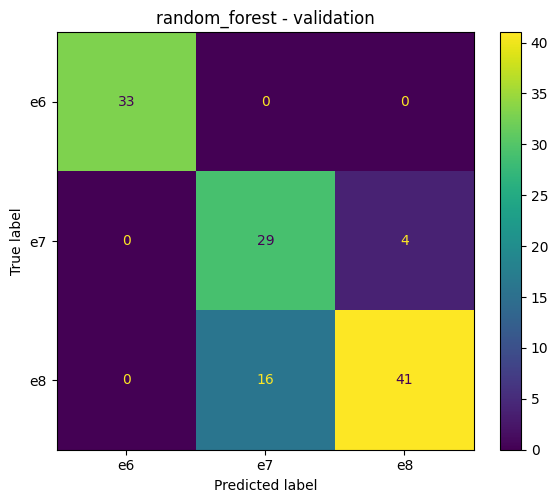

Matrice salvata in:
D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\modele_v2\confusion_matrices\identificare_exercitii\confusion_matrix_random_forest_validation.png

TESTING


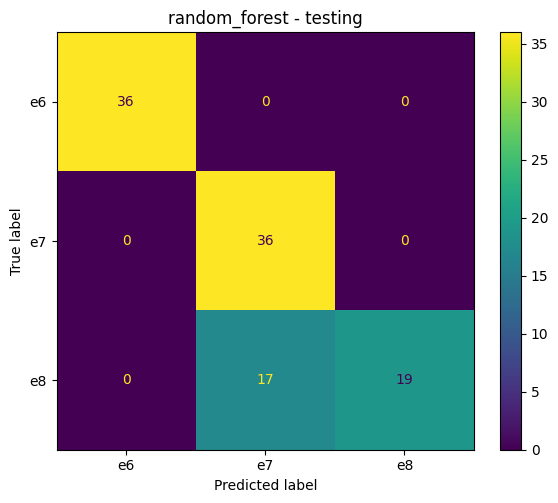

Matrice salvata in:
D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\modele_v2\confusion_matrices\identificare_exercitii\confusion_matrix_random_forest_testing.png
MODEL: extra_trees

VALIDATION


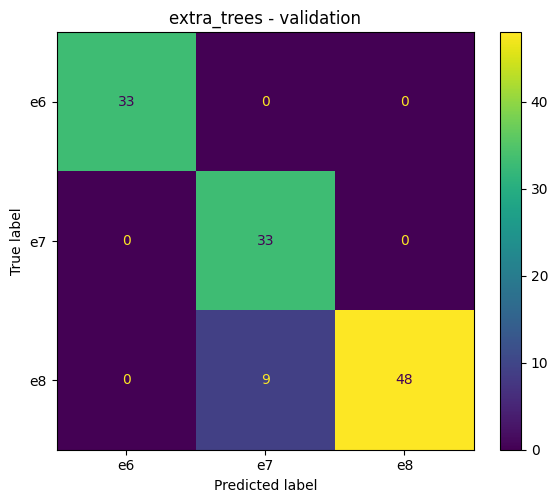

Matrice salvata in:
D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\modele_v2\confusion_matrices\identificare_exercitii\confusion_matrix_extra_trees_validation.png

TESTING


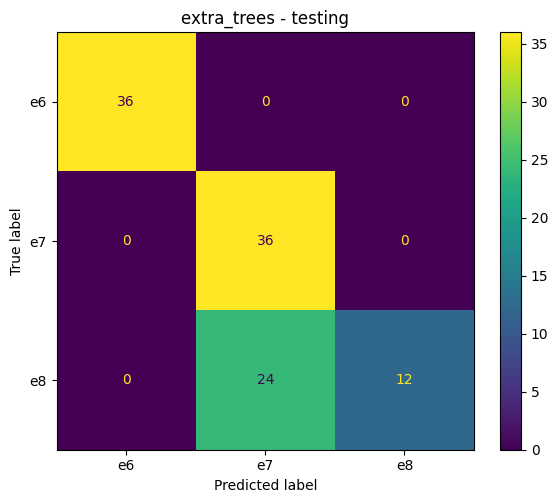

Matrice salvata in:
D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\modele_v2\confusion_matrices\identificare_exercitii\confusion_matrix_extra_trees_testing.png
MODEL: svm_rbf

VALIDATION


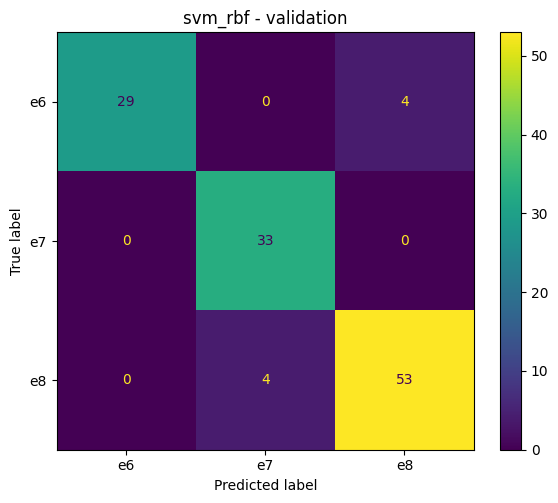

Matrice salvata in:
D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\modele_v2\confusion_matrices\identificare_exercitii\confusion_matrix_svm_rbf_validation.png

TESTING


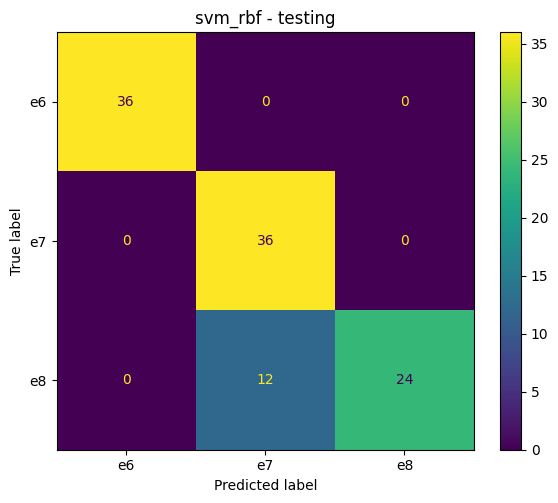

Matrice salvata in:
D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\modele_v2\confusion_matrices\identificare_exercitii\confusion_matrix_svm_rbf_testing.png
MODEL: logistic_regression

VALIDATION


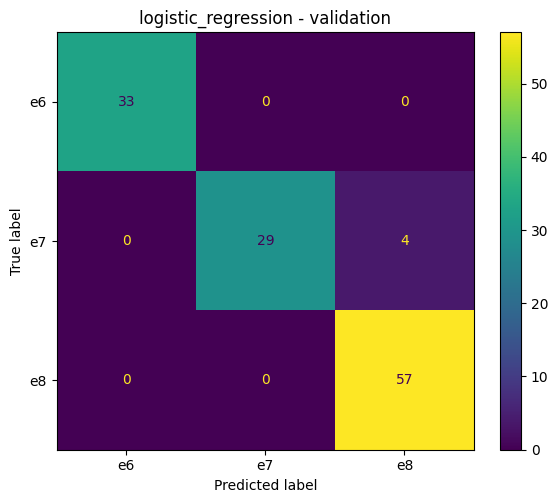

Matrice salvata in:
D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\modele_v2\confusion_matrices\identificare_exercitii\confusion_matrix_logistic_regression_validation.png

TESTING


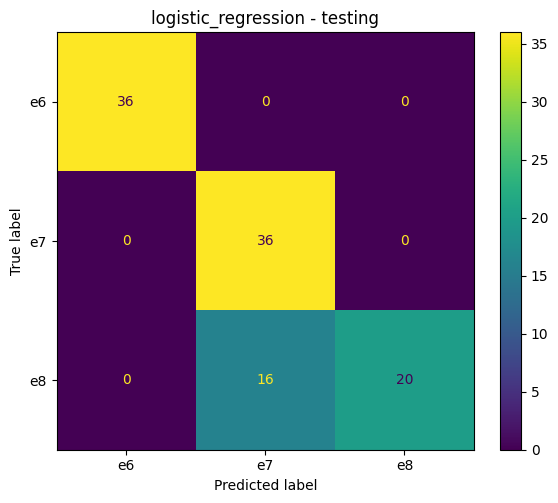

Matrice salvata in:
D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\modele_v2\confusion_matrices\identificare_exercitii\confusion_matrix_logistic_regression_testing.png


In [108]:
# CELULA 37 - Reprezentare grafica matrici de confuzie pentru toate modelele
# NOU: pozele se salveaza in confusion_matrices/identificare_exercitii

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay


def afiseaza_si_salveaza_matrice_confuzie(
    y_true,
    y_pred,
    labels,
    display_labels,
    model_name,
    set_name,
    output_dir,
):
    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=labels,
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=display_labels,
    )

    fig, ax = plt.subplots(
        figsize=(6, 5)
    )

    disp.plot(
        ax=ax,
        values_format="d",
    )

    ax.set_title(
        f"{model_name} - {set_name}"
    )

    plt.tight_layout()

    output_path = output_dir / f"confusion_matrix_{model_name}_{set_name}.png"

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    print("Matrice salvata in:")
    print(output_path)

    return cm


exercise_confusion_matrices = {}

exercise_confusion_dir = get_confusion_matrices_dir(
    "identificare_exercitii"
)

for model_name in exercise_candidate_models.keys():
    print("=" * 100)
    print(f"MODEL: {model_name}")
    print("=" * 100)

    print()
    print("VALIDATION")

    validation_cm = afiseaza_si_salveaza_matrice_confuzie(
        y_true=y_validation_exercise,
        y_pred=exercise_predictions[model_name]["validation_pred"],
        labels=EXERCISE_LABELS,
        display_labels=EXERCISE_TARGET_NAMES,
        model_name=model_name,
        set_name="validation",
        output_dir=exercise_confusion_dir,
    )

    print()
    print("TESTING")

    test_cm = afiseaza_si_salveaza_matrice_confuzie(
        y_true=y_test_exercise,
        y_pred=exercise_predictions[model_name]["test_pred"],
        labels=EXERCISE_LABELS,
        display_labels=EXERCISE_TARGET_NAMES,
        model_name=model_name,
        set_name="testing",
        output_dir=exercise_confusion_dir,
    )

    exercise_confusion_matrices[model_name] = {
        "validation": validation_cm,
        "testing": test_cm,
    }

In [79]:
# CELULA 38 - Rapoarte detaliate pentru toate modelele de identificare exercitiu
# NOU: pastram si raportul text, pe langa matricea grafica
# NOU: afisam classification report si confusion matrix tabelar pentru validation si testing

for model_name, model in exercise_candidate_models.items():
    print("=" * 100)
    print(f"MODEL: {model_name}")
    print("=" * 100)

    print()
    print("VALIDATION")
    print(
        classification_report(
            y_validation_exercise,
            exercise_predictions[model_name]["validation_pred"],
            labels=EXERCISE_LABELS,
            target_names=EXERCISE_TARGET_NAMES,
            zero_division=0,
        )
    )

    validation_cm = confusion_matrix(
        y_validation_exercise,
        exercise_predictions[model_name]["validation_pred"],
        labels=EXERCISE_LABELS,
    )

    validation_cm_df = pd.DataFrame(
        validation_cm,
        index=EXERCISE_TARGET_NAMES,
        columns=EXERCISE_TARGET_NAMES,
    )

    print("Confusion matrix validation:")
    display(
        validation_cm_df
    )

    print()
    print("TESTING")
    print(
        classification_report(
            y_test_exercise,
            exercise_predictions[model_name]["test_pred"],
            labels=EXERCISE_LABELS,
            target_names=EXERCISE_TARGET_NAMES,
            zero_division=0,
        )
    )

    test_cm = confusion_matrix(
        y_test_exercise,
        exercise_predictions[model_name]["test_pred"],
        labels=EXERCISE_LABELS,
    )

    test_cm_df = pd.DataFrame(
        test_cm,
        index=EXERCISE_TARGET_NAMES,
        columns=EXERCISE_TARGET_NAMES,
    )

    print("Confusion matrix testing:")
    display(
        test_cm_df
    )

MODEL: random_forest

VALIDATION
              precision    recall  f1-score   support

          e6       1.00      1.00      1.00        33
          e7       0.64      0.88      0.74        33
          e8       0.91      0.72      0.80        57

    accuracy                           0.84       123
   macro avg       0.85      0.87      0.85       123
weighted avg       0.86      0.84      0.84       123

Confusion matrix validation:


,e6,e7,e8
e6,33,0,0
e7,0,29,4
e8,0,16,41



TESTING
              precision    recall  f1-score   support

          e6       1.00      1.00      1.00        36
          e7       0.68      1.00      0.81        36
          e8       1.00      0.53      0.69        36

    accuracy                           0.84       108
   macro avg       0.89      0.84      0.83       108
weighted avg       0.89      0.84      0.83       108

Confusion matrix testing:


,e6,e7,e8
e6,36,0,0
e7,0,36,0
e8,0,17,19


MODEL: extra_trees

VALIDATION
              precision    recall  f1-score   support

          e6       1.00      1.00      1.00        33
          e7       0.79      1.00      0.88        33
          e8       1.00      0.84      0.91        57

    accuracy                           0.93       123
   macro avg       0.93      0.95      0.93       123
weighted avg       0.94      0.93      0.93       123

Confusion matrix validation:


...

,e6,e7,e8
e6,36,0,0
e7,0,36,0
e8,0,12,24


MODEL: logistic_regression

VALIDATION
              precision    recall  f1-score   support

          e6       1.00      1.00      1.00        33
          e7       1.00      0.88      0.94        33
          e8       0.93      1.00      0.97        57

    accuracy                           0.97       123
   macro avg       0.98      0.96      0.97       123
weighted avg       0.97      0.97      0.97       123

Confusion matrix validation:


,e6,e7,e8
e6,33,0,0
e7,0,29,4
e8,0,0,57



TESTING
              precision    recall  f1-score   support

          e6       1.00      1.00      1.00        36
          e7       0.69      1.00      0.82        36
          e8       1.00      0.56      0.71        36

    accuracy                           0.85       108
   macro avg       0.90      0.85      0.84       108
weighted avg       0.90      0.85      0.84       108

Confusion matrix testing:


,e6,e7,e8
e6,36,0,0
e7,0,36,0
e8,0,16,20


In [109]:
# CELULA 39 - Salvare rezultate comparatie modele identificare exercitiu
# NOU: rezultatele se salveaza ca Excel in modele_joblib/identificare_exercitii
# NOU: salvam si CSV in acelasi folder

exercise_results_excel_path = salveaza_rezultate_excel(
    rezultate_df=exercise_full_results_df,
    task_name="identificare_exercitii",
    nume_fisier="rezultate_identificare_exercitii.xlsx",
)

exercise_results_csv_path = get_joblib_models_dir(
    "identificare_exercitii"
) / "rezultate_identificare_exercitii.csv"

exercise_full_results_df.to_csv(
    exercise_results_csv_path,
    index=False,
)

print("Rezultatele au fost salvate si ca CSV:")
print(exercise_results_csv_path)

Rezultatele au fost salvate in Excel:
D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\modele_v2\modele_joblib\identificare_exercitii\rezultate_identificare_exercitii.xlsx
Rezultatele au fost salvate si ca CSV:
D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\modele_v2\modele_joblib\identificare_exercitii\rezultate_identificare_exercitii.csv


In [110]:
# CELULA 40 - Salvare toate modelele candidate pentru identificarea exercitiului
# NOU: modelele se salveaza in modele_joblib/identificare_exercitii

saved_exercise_model_paths = {}

exercise_models_dir = get_joblib_models_dir(
    "identificare_exercitii"
)

for model_name, model in exercise_candidate_models.items():
    model_path = exercise_models_dir / f"model_identificare_exercitii_{model_name}.joblib"

    joblib.dump(
        model,
        model_path,
    )

    saved_exercise_model_paths[model_name] = str(
        model_path
    )

    print(f"Model salvat: {model_name}")
    print(model_path)
    print()

print("=" * 80)
print("Toate modelele de identificare exercitiu au fost salvate.")

Model salvat: random_forest
D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\modele_v2\modele_joblib\identificare_exercitii\model_identificare_exercitii_random_forest.joblib

Model salvat: extra_trees
D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\modele_v2\modele_joblib\identificare_exercitii\model_identificare_exercitii_extra_trees.joblib

Model salvat: svm_rbf
D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\modele_v2\modele_joblib\identificare_exercitii\model_identificare_exercitii_svm_rbf.joblib

Model salvat: logistic_regression
D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\modele_v2\modele_joblib\identificare_exercitii\model_identificare_exercitii_logistic_regression.joblib

Toate modelele de identificare exercitiu au fost salvate.


In [111]:
# CELULA 41 - Salvare model identificare exercitii selectat pentru GUI
# NOU: modelul standard se salveaza in modele_joblib/identificare_exercitii

exercise_models_dir = get_joblib_models_dir(
    "identificare_exercitii"
)

model_identificare_exercitii_path = exercise_models_dir / "model_identificare_exercitii.joblib"

joblib.dump(
    best_exercise_model,
    model_identificare_exercitii_path,
)

print("Modelul selectat pentru GUI este:")
print(best_exercise_model_name)

print()
print("Modelul a fost salvat cu numele standard:")
print(model_identificare_exercitii_path)

Modelul selectat pentru GUI este:
svm_rbf

Modelul a fost salvat cu numele standard:
D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\modele_v2\modele_joblib\identificare_exercitii\model_identificare_exercitii.joblib


In [83]:
# Antrenare model de calitate

In [88]:
# CELULA 42 - Pregatire date pentru modelul de calitate e6
# CORECTAT: distributia claselor este afisata ca DataFrame, nu ca Series
# Modelul e6 va clasifica executia in: normal, rapid, amplitudine_mica

QUALITY_LABELS = [
    1,
    2,
    3,
]

QUALITY_TARGET_NAMES = [
    "normal",
    "rapid",
    "amplitudine_mica",
]

QUALITY_LABEL_TO_NAME = {
    1: "normal",
    2: "rapid",
    3: "amplitudine_mica",
}

EXERCISE_FOR_QUALITY = 6

train_mask_e6 = (
    y_train_exercise == EXERCISE_FOR_QUALITY
)

validation_mask_e6 = (
    y_validation_exercise == EXERCISE_FOR_QUALITY
)

test_mask_e6 = (
    y_test_exercise == EXERCISE_FOR_QUALITY
)

X_train_e6 = X_train[
    train_mask_e6
]

y_train_quality_e6 = y_train_quality[
    train_mask_e6
]

X_validation_e6 = X_validation[
    validation_mask_e6
]

y_validation_quality_e6 = y_validation_quality[
    validation_mask_e6
]

X_test_e6 = X_test[
    test_mask_e6
]

y_test_quality_e6 = y_test_quality[
    test_mask_e6
]


def afiseaza_distributie_calitate(y, nume_set):
    distributie_df = (
        pd.Series(y)
        .value_counts()
        .sort_index()
        .reset_index()
    )

    distributie_df.columns = [
        "quality_label",
        "numar_exemple",
    ]

    distributie_df["quality_name"] = distributie_df[
        "quality_label"
    ].map(
        QUALITY_LABEL_TO_NAME
    )

    distributie_df = distributie_df[
        [
            "quality_label",
            "quality_name",
            "numar_exemple",
        ]
    ]

    print()
    print(f"Distributie clase {nume_set}:")
    display(
        distributie_df
    )

    return distributie_df


print("=" * 80)
print("Date pentru model_calitate_e6")

print()
print("Training:")
print("X_train_e6:", X_train_e6.shape)
print("y_train_quality_e6:", y_train_quality_e6.shape)

print()
print("Validation:")
print("X_validation_e6:", X_validation_e6.shape)
print("y_validation_quality_e6:", y_validation_quality_e6.shape)

print()
print("Testing:")
print("X_test_e6:", X_test_e6.shape)
print("y_test_quality_e6:", y_test_quality_e6.shape)

train_distribution_e6 = afiseaza_distributie_calitate(
    y_train_quality_e6,
    "training",
)

validation_distribution_e6 = afiseaza_distributie_calitate(
    y_validation_quality_e6,
    "validation",
)

test_distribution_e6 = afiseaza_distributie_calitate(
    y_test_quality_e6,
    "testing",
)

Date pentru model_calitate_e6

Training:
X_train_e6: (75, 112)
y_train_quality_e6: (75,)

Validation:
X_validation_e6: (33, 112)
y_validation_quality_e6: (33,)

Testing:
X_test_e6: (36, 112)
y_test_quality_e6: (36,)

Distributie clase training:


,quality_label,quality_name,numar_exemple
0,1,normal,25
1,2,rapid,25
2,3,amplitudine_mica,25



Distributie clase validation:


,quality_label,quality_name,numar_exemple
0,1,normal,11
1,2,rapid,11
2,3,amplitudine_mica,11



Distributie clase testing:


,quality_label,quality_name,numar_exemple
0,1,normal,12
1,2,rapid,12
2,3,amplitudine_mica,12


In [89]:
# CELULA 43 - Definire modele candidate pentru modelul de calitate e6
# NOU: folosim aceiasi 4 clasificatori ca la identificarea exercitiului
# NOU: cream modele noi, curate, special pentru calitatea exercitiului e6
# NOU: nu refolosim modelele deja antrenate pentru identificarea exercitiului

def creeaza_modele_candidate_calitate():
    candidate_models = {
        "random_forest": RandomForestClassifier(
            random_state=RANDOM_SEED,
            class_weight="balanced",
            n_jobs=-1,
        ),

        "extra_trees": ExtraTreesClassifier(
            random_state=RANDOM_SEED,
            class_weight="balanced",
            n_jobs=-1,
        ),

        "svm_rbf": Pipeline([
            (
                "scaler",
                StandardScaler(),
            ),
            (
                "model",
                SVC(
                    kernel="rbf",
                    class_weight="balanced",
                    probability=True,
                    random_state=RANDOM_SEED,
                ),
            ),
        ]),

        "logistic_regression": Pipeline([
            (
                "scaler",
                StandardScaler(),
            ),
            (
                "model",
                LogisticRegression(
                    max_iter=3000,
                    class_weight="balanced",
                    random_state=RANDOM_SEED,
                ),
            ),
        ]),
    }

    return candidate_models


quality_e6_candidate_models = creeaza_modele_candidate_calitate()

print("Modele candidate pentru model_calitate_e6:")
print(
    list(
        quality_e6_candidate_models.keys()
    )
)

Modele candidate pentru model_calitate_e6:
['random_forest', 'extra_trees', 'svm_rbf', 'logistic_regression']


In [90]:
# CELULA 44 - Antrenare modele candidate pentru modelul de calitate e6
# NOU: antrenam toate cele 4 modele pentru calitatea exercitiului e6
# NOU: validam fiecare model pe X_validation_e6 si y_validation_quality_e6

quality_e6_validation_results = []

for model_name, model in quality_e6_candidate_models.items():
    print("=" * 80)
    print(f"Antrenez modelul pentru e6: {model_name}")

    model.fit(
        X_train_e6,
        y_train_quality_e6,
    )

    y_validation_pred = model.predict(
        X_validation_e6
    )

    validation_accuracy = accuracy_score(
        y_validation_quality_e6,
        y_validation_pred,
    )

    validation_f1_macro = f1_score(
        y_validation_quality_e6,
        y_validation_pred,
        average="macro",
        zero_division=0,
    )

    quality_e6_validation_results.append({
        "model_name": model_name,
        "validation_accuracy": validation_accuracy,
        "validation_f1_macro": validation_f1_macro,
    })

    print("Validation accuracy:", validation_accuracy)
    print("Validation F1 macro:", validation_f1_macro)

quality_e6_validation_results_df = pd.DataFrame(
    quality_e6_validation_results
).sort_values(
    by=[
        "validation_f1_macro",
        "validation_accuracy",
    ],
    ascending=False,
).reset_index(
    drop=True
)

display(
    quality_e6_validation_results_df
)

Antrenez modelul pentru e6: random_forest
Validation accuracy: 1.0
Validation F1 macro: 1.0
Antrenez modelul pentru e6: extra_trees
Validation accuracy: 1.0
Validation F1 macro: 1.0
Antrenez modelul pentru e6: svm_rbf
Validation accuracy: 1.0
Validation F1 macro: 1.0
Antrenez modelul pentru e6: logistic_regression
Validation accuracy: 1.0
Validation F1 macro: 1.0


,model_name,validation_accuracy,validation_f1_macro
0,random_forest,1.0,1.0
1,extra_trees,1.0,1.0
2,svm_rbf,1.0,1.0
3,logistic_regression,1.0,1.0


In [91]:
# EVALUARE

In [92]:
# CELULA 45 - Evaluare toate modelele candidate pentru calitate e6 pe validation si testing
# NOU: pastram toate cele 4 modele pana la testare
# NOU: calculam accuracy, precision_macro, recall_macro si f1_macro
# NOU: comparam modelele atat pe validation, cat si pe testing

quality_e6_full_results = []
quality_e6_predictions = {}

for model_name, model in quality_e6_candidate_models.items():
    print("=" * 80)
    print(f"Evaluez modelul pentru e6: {model_name}")

    validation_metrics = calculeaza_metrici_clasificare(
        model,
        X_validation_e6,
        y_validation_quality_e6,
    )

    test_metrics = calculeaza_metrici_clasificare(
        model,
        X_test_e6,
        y_test_quality_e6,
    )

    quality_e6_predictions[model_name] = {
        "validation_pred": validation_metrics["y_pred"],
        "test_pred": test_metrics["y_pred"],
    }

    quality_e6_full_results.append({
        "model_name": model_name,

        "validation_accuracy": validation_metrics["accuracy"],
        "validation_precision_macro": validation_metrics["precision_macro"],
        "validation_recall_macro": validation_metrics["recall_macro"],
        "validation_f1_macro": validation_metrics["f1_macro"],

        "test_accuracy": test_metrics["accuracy"],
        "test_precision_macro": test_metrics["precision_macro"],
        "test_recall_macro": test_metrics["recall_macro"],
        "test_f1_macro": test_metrics["f1_macro"],
    })

quality_e6_full_results_df = pd.DataFrame(
    quality_e6_full_results
)

quality_e6_full_results_df["combined_f1_macro"] = (
    quality_e6_full_results_df["validation_f1_macro"]
    + quality_e6_full_results_df["test_f1_macro"]
) / 2

quality_e6_full_results_df["combined_accuracy"] = (
    quality_e6_full_results_df["validation_accuracy"]
    + quality_e6_full_results_df["test_accuracy"]
) / 2

quality_e6_full_results_df = quality_e6_full_results_df.sort_values(
    by=[
        "combined_f1_macro",
        "combined_accuracy",
        "validation_f1_macro",
        "test_f1_macro",
    ],
    ascending=False,
).reset_index(
    drop=True
)

display(
    quality_e6_full_results_df
)

Evaluez modelul pentru e6: random_forest
Evaluez modelul pentru e6: extra_trees
Evaluez modelul pentru e6: svm_rbf
Evaluez modelul pentru e6: logistic_regression


,model_name,validation_accuracy,validation_precision_macro,validation_recall_macro,validation_f1_macro,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,combined_f1_macro,combined_accuracy
0,random_forest,1.0,1.0,1.0,1.0,0.916667,0.933333,0.916667,0.915344,0.957672,0.958333
1,extra_trees,1.0,1.0,1.0,1.0,0.888889,0.916667,0.888889,0.885714,0.942857,0.944444
2,svm_rbf,1.0,1.0,1.0,1.0,0.888889,0.916667,0.888889,0.885714,0.942857,0.944444
3,logistic_regression,1.0,1.0,1.0,1.0,0.888889,0.916667,0.888889,0.885714,0.942857,0.944444


In [93]:
# CELULA 46 - Alegere model recomandat pentru model_calitate_e6
# NOU: alegem modelul dupa scor combinat validation + testing

best_quality_e6_model_name = quality_e6_full_results_df.iloc[0]["model_name"]

best_quality_e6_model = quality_e6_candidate_models[
    best_quality_e6_model_name
]

print("=" * 80)
print("Rezultate modele calitate e6, sortate dupa scor combinat")
display(
    quality_e6_full_results_df
)

print("=" * 80)
print("Model selectat pentru model_calitate_e6:")
print(best_quality_e6_model_name)

print()
print("Criteriu folosit:")
print("combined_f1_macro = media dintre validation_f1_macro si test_f1_macro")

Rezultate modele calitate e6, sortate dupa scor combinat


,model_name,validation_accuracy,validation_precision_macro,validation_recall_macro,validation_f1_macro,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,combined_f1_macro,combined_accuracy
0,random_forest,1.0,1.0,1.0,1.0,0.916667,0.933333,0.916667,0.915344,0.957672,0.958333
1,extra_trees,1.0,1.0,1.0,1.0,0.888889,0.916667,0.888889,0.885714,0.942857,0.944444
2,svm_rbf,1.0,1.0,1.0,1.0,0.888889,0.916667,0.888889,0.885714,0.942857,0.944444
3,logistic_regression,1.0,1.0,1.0,1.0,0.888889,0.916667,0.888889,0.885714,0.942857,0.944444


Model selectat pentru model_calitate_e6:
random_forest

Criteriu folosit:
combined_f1_macro = media dintre validation_f1_macro si test_f1_macro


MODEL CALITATE E6: random_forest

VALIDATION


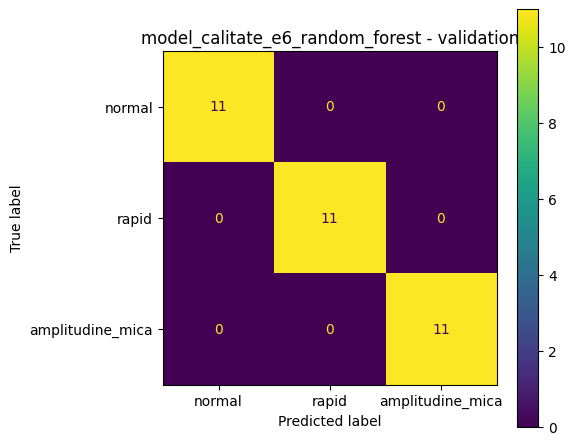

Matrice salvata in:
D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\modele_v2\confusion_matrices\calitate_e6\confusion_matrix_model_calitate_e6_random_forest_validation.png

TESTING


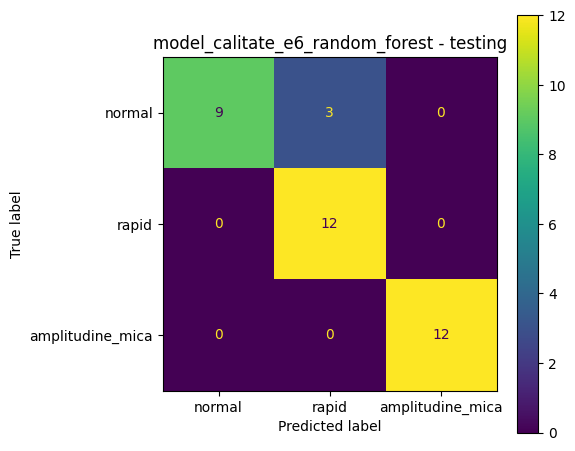

Matrice salvata in:
D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\modele_v2\confusion_matrices\calitate_e6\confusion_matrix_model_calitate_e6_random_forest_testing.png
MODEL CALITATE E6: extra_trees

VALIDATION


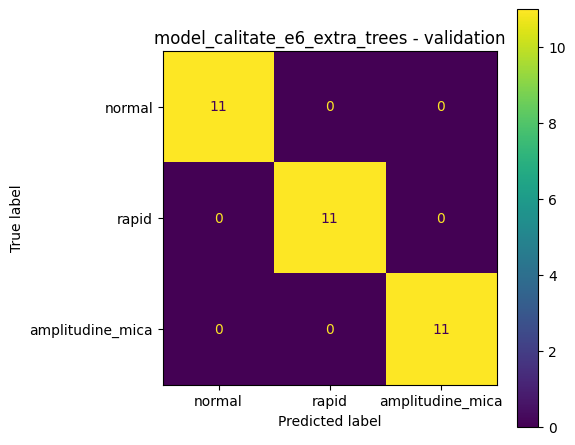

Matrice salvata in:
D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\modele_v2\confusion_matrices\calitate_e6\confusion_matrix_model_calitate_e6_extra_trees_validation.png

TESTING


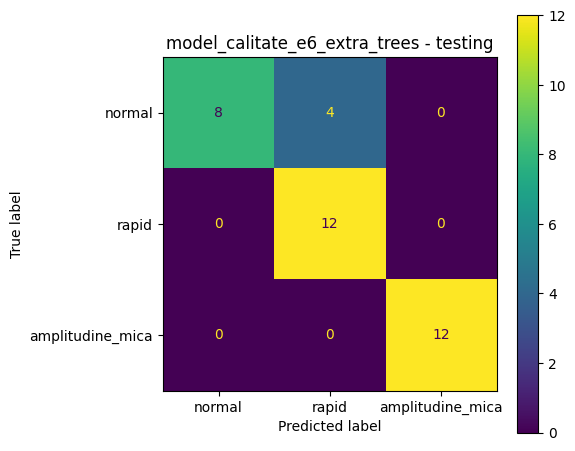

Matrice salvata in:
D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\modele_v2\confusion_matrices\calitate_e6\confusion_matrix_model_calitate_e6_extra_trees_testing.png
MODEL CALITATE E6: svm_rbf

VALIDATION


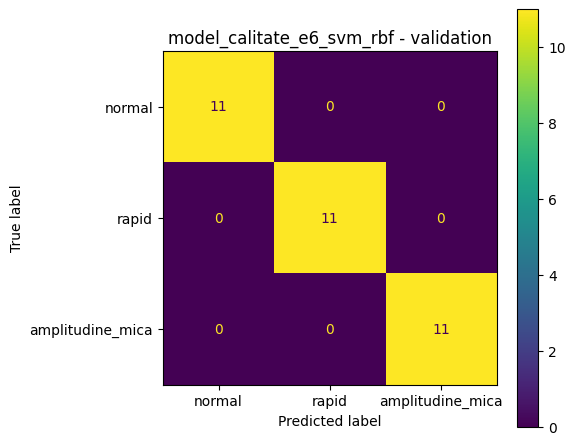

Matrice salvata in:
D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\modele_v2\confusion_matrices\calitate_e6\confusion_matrix_model_calitate_e6_svm_rbf_validation.png

TESTING


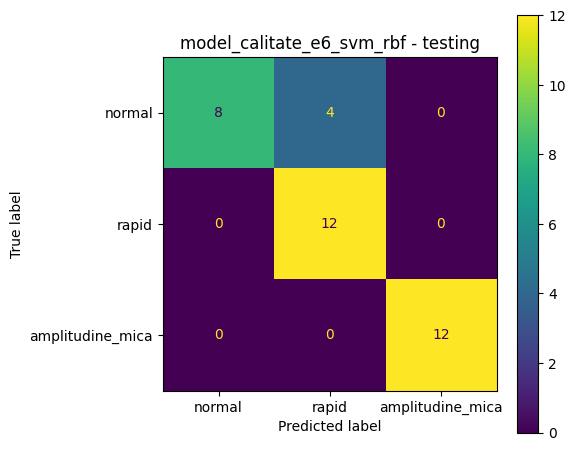

Matrice salvata in:
D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\modele_v2\confusion_matrices\calitate_e6\confusion_matrix_model_calitate_e6_svm_rbf_testing.png
MODEL CALITATE E6: logistic_regression

VALIDATION


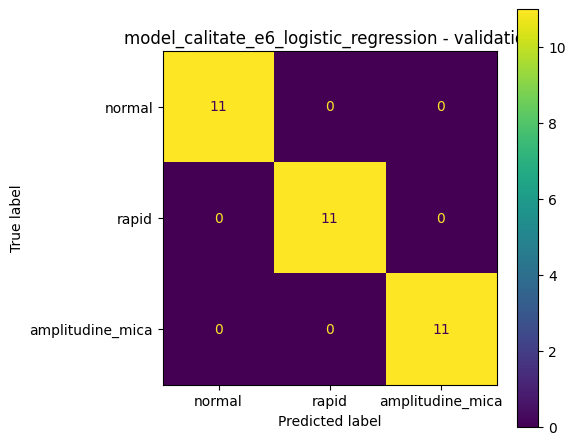

Matrice salvata in:
D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\modele_v2\confusion_matrices\calitate_e6\confusion_matrix_model_calitate_e6_logistic_regression_validation.png

TESTING


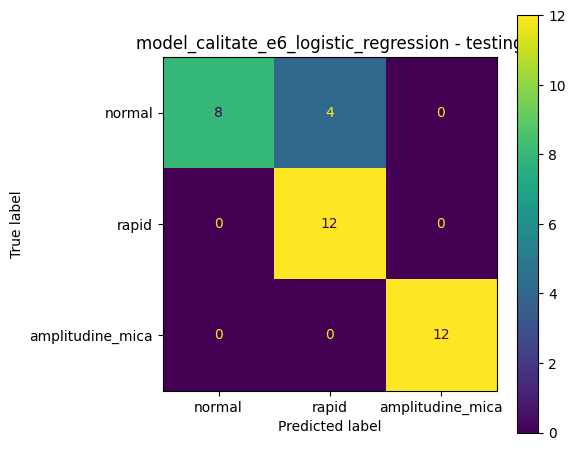

Matrice salvata in:
D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\modele_v2\confusion_matrices\calitate_e6\confusion_matrix_model_calitate_e6_logistic_regression_testing.png


In [112]:
# CELULA 47 - Reprezentare grafica matrici de confuzie pentru modelele e6
# NOU: pozele se salveaza in confusion_matrices/calitate_e6

quality_e6_confusion_matrices = {}

quality_e6_confusion_dir = get_confusion_matrices_dir(
    "calitate_e6"
)

for model_name in quality_e6_candidate_models.keys():
    print("=" * 100)
    print(f"MODEL CALITATE E6: {model_name}")
    print("=" * 100)

    print()
    print("VALIDATION")

    validation_cm = afiseaza_si_salveaza_matrice_confuzie(
        y_true=y_validation_quality_e6,
        y_pred=quality_e6_predictions[model_name]["validation_pred"],
        labels=QUALITY_LABELS,
        display_labels=QUALITY_TARGET_NAMES,
        model_name=f"model_calitate_e6_{model_name}",
        set_name="validation",
        output_dir=quality_e6_confusion_dir,
    )

    print()
    print("TESTING")

    test_cm = afiseaza_si_salveaza_matrice_confuzie(
        y_true=y_test_quality_e6,
        y_pred=quality_e6_predictions[model_name]["test_pred"],
        labels=QUALITY_LABELS,
        display_labels=QUALITY_TARGET_NAMES,
        model_name=f"model_calitate_e6_{model_name}",
        set_name="testing",
        output_dir=quality_e6_confusion_dir,
    )

    quality_e6_confusion_matrices[model_name] = {
        "validation": validation_cm,
        "testing": test_cm,
    }

In [95]:
# CELULA 48 - Rapoarte detaliate pentru toate modelele de calitate e6
# NOU: pastram si raportul text, pe langa matricea grafica
# NOU: afisam classification report si confusion matrix tabelar pentru validation si testing

for model_name, model in quality_e6_candidate_models.items():
    print("=" * 100)
    print(f"MODEL CALITATE E6: {model_name}")
    print("=" * 100)

    print()
    print("VALIDATION")
    print(
        classification_report(
            y_validation_quality_e6,
            quality_e6_predictions[model_name]["validation_pred"],
            labels=QUALITY_LABELS,
            target_names=QUALITY_TARGET_NAMES,
            zero_division=0,
        )
    )

    validation_cm = confusion_matrix(
        y_validation_quality_e6,
        quality_e6_predictions[model_name]["validation_pred"],
        labels=QUALITY_LABELS,
    )

    validation_cm_df = pd.DataFrame(
        validation_cm,
        index=QUALITY_TARGET_NAMES,
        columns=QUALITY_TARGET_NAMES,
    )

    print("Confusion matrix validation:")
    display(
        validation_cm_df
    )

    print()
    print("TESTING")
    print(
        classification_report(
            y_test_quality_e6,
            quality_e6_predictions[model_name]["test_pred"],
            labels=QUALITY_LABELS,
            target_names=QUALITY_TARGET_NAMES,
            zero_division=0,
        )
    )

    test_cm = confusion_matrix(
        y_test_quality_e6,
        quality_e6_predictions[model_name]["test_pred"],
        labels=QUALITY_LABELS,
    )

    test_cm_df = pd.DataFrame(
        test_cm,
        index=QUALITY_TARGET_NAMES,
        columns=QUALITY_TARGET_NAMES,
    )

    print("Confusion matrix testing:")
    display(
        test_cm_df
    )

MODEL CALITATE E6: random_forest

VALIDATION
                  precision    recall  f1-score   support

          normal       1.00      1.00      1.00        11
           rapid       1.00      1.00      1.00        11
amplitudine_mica       1.00      1.00      1.00        11

        accuracy                           1.00        33
       macro avg       1.00      1.00      1.00        33
    weighted avg       1.00      1.00      1.00        33

Confusion matrix validation:


,normal,rapid,amplitudine_mica
normal,11,0,0
rapid,0,11,0
amplitudine_mica,0,0,11



TESTING
                  precision    recall  f1-score   support

          normal       1.00      0.75      0.86        12
           rapid       0.80      1.00      0.89        12
amplitudine_mica       1.00      1.00      1.00        12

        accuracy                           0.92        36
       macro avg       0.93      0.92      0.92        36
    weighted avg       0.93      0.92      0.92        36

Confusion matrix testing:


,normal,rapid,amplitudine_mica
normal,9,3,0
rapid,0,12,0
amplitudine_mica,0,0,12


MODEL CALITATE E6: extra_trees

VALIDATION
                  precision    recall  f1-score   support

          normal       1.00      1.00      1.00        11
           rapid       1.00      1.00      1.00        11
amplitudine_mica       1.00      1.00      1.00        11

        accuracy                           1.00        33
       macro avg       1.00      1.00      1.00        33
    weighted avg       1.00      1.00      1.00        33

Confusion matrix validation:


...

,normal,rapid,amplitudine_mica
normal,8,4,0
rapid,0,12,0
amplitudine_mica,0,0,12


MODEL CALITATE E6: logistic_regression

VALIDATION
                  precision    recall  f1-score   support

          normal       1.00      1.00      1.00        11
           rapid       1.00      1.00      1.00        11
amplitudine_mica       1.00      1.00      1.00        11

        accuracy                           1.00        33
       macro avg       1.00      1.00      1.00        33
    weighted avg       1.00      1.00      1.00        33

Confusion matrix validation:


,normal,rapid,amplitudine_mica
normal,11,0,0
rapid,0,11,0
amplitudine_mica,0,0,11



TESTING
                  precision    recall  f1-score   support

          normal       1.00      0.67      0.80        12
           rapid       0.75      1.00      0.86        12
amplitudine_mica       1.00      1.00      1.00        12

        accuracy                           0.89        36
       macro avg       0.92      0.89      0.89        36
    weighted avg       0.92      0.89      0.89        36

Confusion matrix testing:


,normal,rapid,amplitudine_mica
normal,8,4,0
rapid,0,12,0
amplitudine_mica,0,0,12


In [113]:
# CELULA 49 - Salvare rezultate comparatie modele calitate e6
# NOU: rezultatele se salveaza ca Excel in modele_joblib/calitate_e6
# NOU: salvam si CSV in acelasi folder

quality_e6_full_results_df = quality_e6_full_results_df.sort_values(
    by=[
        "combined_f1_macro",
        "combined_accuracy",
        "test_f1_macro",
        "test_accuracy",
    ],
    ascending=False,
).reset_index(
    drop=True
)

best_quality_e6_model_name = quality_e6_full_results_df.iloc[0]["model_name"]

best_quality_e6_model = quality_e6_candidate_models[
    best_quality_e6_model_name
]

print("=" * 80)
print("Model selectat pentru model_calitate_e6:")
print(best_quality_e6_model_name)

print()
print("Rezultate finale e6:")
display(
    quality_e6_full_results_df
)

quality_e6_results_excel_path = salveaza_rezultate_excel(
    rezultate_df=quality_e6_full_results_df,
    task_name="calitate_e6",
    nume_fisier="rezultate_calitate_e6.xlsx",
)

quality_e6_results_csv_path = get_joblib_models_dir(
    "calitate_e6"
) / "rezultate_calitate_e6.csv"

quality_e6_full_results_df.to_csv(
    quality_e6_results_csv_path,
    index=False,
)

print("Rezultatele e6 au fost salvate si ca CSV:")
print(quality_e6_results_csv_path)

Model selectat pentru model_calitate_e6:
random_forest

Rezultate finale e6:


,model_name,validation_accuracy,validation_precision_macro,validation_recall_macro,validation_f1_macro,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,combined_f1_macro,combined_accuracy
0,random_forest,1.0,1.0,1.0,1.0,0.916667,0.933333,0.916667,0.915344,0.957672,0.958333
1,extra_trees,1.0,1.0,1.0,1.0,0.888889,0.916667,0.888889,0.885714,0.942857,0.944444
2,svm_rbf,1.0,1.0,1.0,1.0,0.888889,0.916667,0.888889,0.885714,0.942857,0.944444
3,logistic_regression,1.0,1.0,1.0,1.0,0.888889,0.916667,0.888889,0.885714,0.942857,0.944444


Rezultatele au fost salvate in Excel:
D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\modele_v2\modele_joblib\calitate_e6\rezultate_calitate_e6.xlsx
Rezultatele e6 au fost salvate si ca CSV:
D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\modele_v2\modele_joblib\calitate_e6\rezultate_calitate_e6.csv


In [114]:
# CELULA 50 - Salvare toate modelele candidate pentru calitate e6
# NOU: modelele se salveaza in modele_joblib/calitate_e6

saved_quality_e6_model_paths = {}

quality_e6_models_dir = get_joblib_models_dir(
    "calitate_e6"
)

for model_name, model in quality_e6_candidate_models.items():
    model_path = quality_e6_models_dir / f"model_calitate_e6_{model_name}.joblib"

    joblib.dump(
        model,
        model_path,
    )

    saved_quality_e6_model_paths[model_name] = str(
        model_path
    )

    print(f"Model e6 salvat: {model_name}")
    print(model_path)
    print()

print("=" * 80)
print("Toate modelele pentru calitate e6 au fost salvate.")

Model e6 salvat: random_forest
D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\modele_v2\modele_joblib\calitate_e6\model_calitate_e6_random_forest.joblib

Model e6 salvat: extra_trees
D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\modele_v2\modele_joblib\calitate_e6\model_calitate_e6_extra_trees.joblib

Model e6 salvat: svm_rbf
D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\modele_v2\modele_joblib\calitate_e6\model_calitate_e6_svm_rbf.joblib

Model e6 salvat: logistic_regression
D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\modele_v2\modele_joblib\calitate_e6\model_calitate_e6_logistic_regression.joblib

Toate modelele pentru calitate e6 au fost salvate.


In [115]:
# CELULA 51 - Salvare model_calitate_e6 selectat pentru GUI
# NOU: modelul standard se salveaza in modele_joblib/calitate_e6

quality_e6_models_dir = get_joblib_models_dir(
    "calitate_e6"
)

model_calitate_e6_path = quality_e6_models_dir / "model_calitate_e6.joblib"

joblib.dump(
    best_quality_e6_model,
    model_calitate_e6_path,
)

print("Modelul selectat pentru GUI la e6 este:")
print(best_quality_e6_model_name)

print()
print("Modelul a fost salvat cu numele standard:")
print(model_calitate_e6_path)

Modelul selectat pentru GUI la e6 este:
random_forest

Modelul a fost salvat cu numele standard:
D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\modele_v2\modele_joblib\calitate_e6\model_calitate_e6.joblib


In [116]:
# Trecem la model_calitate_e7

In [117]:
# CELULA 52 - Pregatire date pentru modelul de calitate e7
# Modelul e7 va clasifica executia in: normal, rapid, amplitudine_mica
# Folosim doar exemplele la care exercitiul este e7

EXERCISE_FOR_QUALITY = 7

train_mask_e7 = (
    y_train_exercise == EXERCISE_FOR_QUALITY
)

validation_mask_e7 = (
    y_validation_exercise == EXERCISE_FOR_QUALITY
)

test_mask_e7 = (
    y_test_exercise == EXERCISE_FOR_QUALITY
)

X_train_e7 = X_train[
    train_mask_e7
]

y_train_quality_e7 = y_train_quality[
    train_mask_e7
]

X_validation_e7 = X_validation[
    validation_mask_e7
]

y_validation_quality_e7 = y_validation_quality[
    validation_mask_e7
]

X_test_e7 = X_test[
    test_mask_e7
]

y_test_quality_e7 = y_test_quality[
    test_mask_e7
]

print("=" * 80)
print("Date pentru model_calitate_e7")

print()
print("Training:")
print("X_train_e7:", X_train_e7.shape)
print("y_train_quality_e7:", y_train_quality_e7.shape)

print()
print("Validation:")
print("X_validation_e7:", X_validation_e7.shape)
print("y_validation_quality_e7:", y_validation_quality_e7.shape)

print()
print("Testing:")
print("X_test_e7:", X_test_e7.shape)
print("y_test_quality_e7:", y_test_quality_e7.shape)

train_distribution_e7 = afiseaza_distributie_calitate(
    y_train_quality_e7,
    "training",
)

validation_distribution_e7 = afiseaza_distributie_calitate(
    y_validation_quality_e7,
    "validation",
)

test_distribution_e7 = afiseaza_distributie_calitate(
    y_test_quality_e7,
    "testing",
)

Date pentru model_calitate_e7

Training:
X_train_e7: (123, 112)
y_train_quality_e7: (123,)

Validation:
X_validation_e7: (33, 112)
y_validation_quality_e7: (33,)

Testing:
X_test_e7: (36, 112)
y_test_quality_e7: (36,)

Distributie clase training:


,quality_label,quality_name,numar_exemple
0,1,normal,41
1,2,rapid,41
2,3,amplitudine_mica,41



Distributie clase validation:


,quality_label,quality_name,numar_exemple
0,1,normal,11
1,2,rapid,11
2,3,amplitudine_mica,11



Distributie clase testing:


,quality_label,quality_name,numar_exemple
0,1,normal,12
1,2,rapid,12
2,3,amplitudine_mica,12


In [118]:
# CELULA 53 - Definire modele candidate pentru modelul de calitate e7
# NOU: folosim aceiasi 4 clasificatori ca la e6
# NOU: cream modele noi, curate, special pentru calitatea exercitiului e7

quality_e7_candidate_models = creeaza_modele_candidate_calitate()

print("Modele candidate pentru model_calitate_e7:")
print(
    list(
        quality_e7_candidate_models.keys()
    )
)

Modele candidate pentru model_calitate_e7:
['random_forest', 'extra_trees', 'svm_rbf', 'logistic_regression']


In [119]:
# CELULA 54 - Antrenare modele candidate pentru modelul de calitate e7
# NOU: antrenam toate cele 4 modele pentru calitatea exercitiului e7
# NOU: validam fiecare model pe X_validation_e7 si y_validation_quality_e7

quality_e7_validation_results = []

for model_name, model in quality_e7_candidate_models.items():
    print("=" * 80)
    print(f"Antrenez modelul pentru e7: {model_name}")

    model.fit(
        X_train_e7,
        y_train_quality_e7,
    )

    y_validation_pred = model.predict(
        X_validation_e7
    )

    validation_accuracy = accuracy_score(
        y_validation_quality_e7,
        y_validation_pred,
    )

    validation_f1_macro = f1_score(
        y_validation_quality_e7,
        y_validation_pred,
        average="macro",
        zero_division=0,
    )

    quality_e7_validation_results.append({
        "model_name": model_name,
        "validation_accuracy": validation_accuracy,
        "validation_f1_macro": validation_f1_macro,
    })

    print("Validation accuracy:", validation_accuracy)
    print("Validation F1 macro:", validation_f1_macro)

quality_e7_validation_results_df = pd.DataFrame(
    quality_e7_validation_results
).sort_values(
    by=[
        "validation_f1_macro",
        "validation_accuracy",
    ],
    ascending=False,
).reset_index(
    drop=True
)

display(
    quality_e7_validation_results_df
)

Antrenez modelul pentru e7: random_forest
Validation accuracy: 1.0
Validation F1 macro: 1.0
Antrenez modelul pentru e7: extra_trees
Validation accuracy: 1.0
Validation F1 macro: 1.0
Antrenez modelul pentru e7: svm_rbf
Validation accuracy: 1.0
Validation F1 macro: 1.0
Antrenez modelul pentru e7: logistic_regression
Validation accuracy: 1.0
Validation F1 macro: 1.0


,model_name,validation_accuracy,validation_f1_macro
0,random_forest,1.0,1.0
1,extra_trees,1.0,1.0
2,svm_rbf,1.0,1.0
3,logistic_regression,1.0,1.0


In [120]:
# CELULA 55 - Evaluare toate modelele candidate pentru calitate e7 pe validation si testing
# NOU: pastram toate cele 4 modele pana la testare
# NOU: calculam accuracy, precision_macro, recall_macro si f1_macro
# NOU: comparam modelele atat pe validation, cat si pe testing

quality_e7_full_results = []
quality_e7_predictions = {}

for model_name, model in quality_e7_candidate_models.items():
    print("=" * 80)
    print(f"Evaluez modelul pentru e7: {model_name}")

    validation_metrics = calculeaza_metrici_clasificare(
        model,
        X_validation_e7,
        y_validation_quality_e7,
    )

    test_metrics = calculeaza_metrici_clasificare(
        model,
        X_test_e7,
        y_test_quality_e7,
    )

    quality_e7_predictions[model_name] = {
        "validation_pred": validation_metrics["y_pred"],
        "test_pred": test_metrics["y_pred"],
    }

    quality_e7_full_results.append({
        "model_name": model_name,

        "validation_accuracy": validation_metrics["accuracy"],
        "validation_precision_macro": validation_metrics["precision_macro"],
        "validation_recall_macro": validation_metrics["recall_macro"],
        "validation_f1_macro": validation_metrics["f1_macro"],

        "test_accuracy": test_metrics["accuracy"],
        "test_precision_macro": test_metrics["precision_macro"],
        "test_recall_macro": test_metrics["recall_macro"],
        "test_f1_macro": test_metrics["f1_macro"],
    })

quality_e7_full_results_df = pd.DataFrame(
    quality_e7_full_results
)

quality_e7_full_results_df["combined_f1_macro"] = (
    quality_e7_full_results_df["validation_f1_macro"]
    + quality_e7_full_results_df["test_f1_macro"]
) / 2

quality_e7_full_results_df["combined_accuracy"] = (
    quality_e7_full_results_df["validation_accuracy"]
    + quality_e7_full_results_df["test_accuracy"]
) / 2

quality_e7_full_results_df = quality_e7_full_results_df.sort_values(
    by=[
        "combined_f1_macro",
        "combined_accuracy",
        "test_f1_macro",
        "test_accuracy",
    ],
    ascending=False,
).reset_index(
    drop=True
)

display(
    quality_e7_full_results_df
)

Evaluez modelul pentru e7: random_forest
Evaluez modelul pentru e7: extra_trees
Evaluez modelul pentru e7: svm_rbf
Evaluez modelul pentru e7: logistic_regression


,model_name,validation_accuracy,validation_precision_macro,validation_recall_macro,validation_f1_macro,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,combined_f1_macro,combined_accuracy
0,logistic_regression,1.0,1.0,1.0,1.0,0.888889,0.916667,0.888889,0.885714,0.942857,0.944444
1,random_forest,1.0,1.0,1.0,1.0,0.888889,0.907692,0.888889,0.882963,0.941481,0.944444
2,extra_trees,1.0,1.0,1.0,1.0,0.805556,0.848214,0.805556,0.791819,0.895910,0.902778
3,svm_rbf,1.0,1.0,1.0,1.0,0.777778,0.833333,0.777778,0.738095,0.869048,0.888889


In [121]:
# CELULA 56 - Alegere model recomandat pentru model_calitate_e7
# NOU: alegem modelul dupa scor combinat validation + testing

best_quality_e7_model_name = quality_e7_full_results_df.iloc[0]["model_name"]

best_quality_e7_model = quality_e7_candidate_models[
    best_quality_e7_model_name
]

print("=" * 80)
print("Rezultate modele calitate e7, sortate dupa scor combinat")
display(
    quality_e7_full_results_df
)

print("=" * 80)
print("Model selectat pentru model_calitate_e7:")
print(best_quality_e7_model_name)

print()
print("Criteriu folosit:")
print("combined_f1_macro = media dintre validation_f1_macro si test_f1_macro")

Rezultate modele calitate e7, sortate dupa scor combinat


,model_name,validation_accuracy,validation_precision_macro,validation_recall_macro,validation_f1_macro,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,combined_f1_macro,combined_accuracy
0,logistic_regression,1.0,1.0,1.0,1.0,0.888889,0.916667,0.888889,0.885714,0.942857,0.944444
1,random_forest,1.0,1.0,1.0,1.0,0.888889,0.907692,0.888889,0.882963,0.941481,0.944444
2,extra_trees,1.0,1.0,1.0,1.0,0.805556,0.848214,0.805556,0.791819,0.895910,0.902778
3,svm_rbf,1.0,1.0,1.0,1.0,0.777778,0.833333,0.777778,0.738095,0.869048,0.888889


Model selectat pentru model_calitate_e7:
logistic_regression

Criteriu folosit:
combined_f1_macro = media dintre validation_f1_macro si test_f1_macro


MODEL CALITATE E7: random_forest

VALIDATION


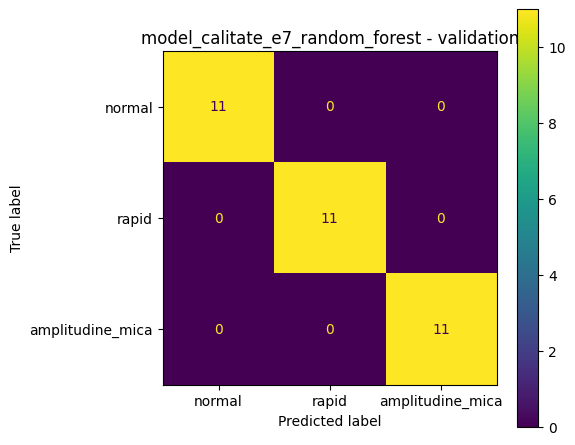

Matrice salvata in:
D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\modele_v2\confusion_matrices\calitate_e7\confusion_matrix_model_calitate_e7_random_forest_validation.png

TESTING


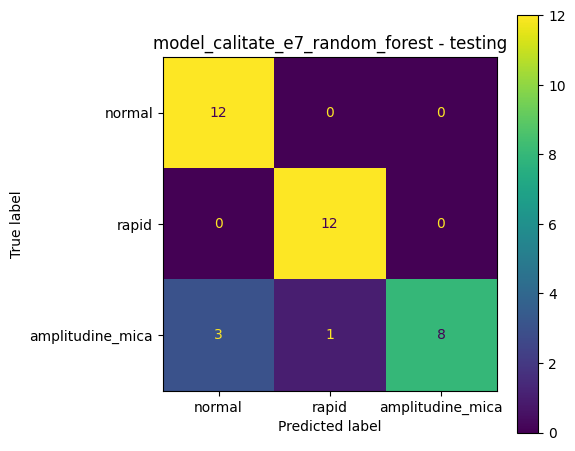

Matrice salvata in:
D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\modele_v2\confusion_matrices\calitate_e7\confusion_matrix_model_calitate_e7_random_forest_testing.png
MODEL CALITATE E7: extra_trees

VALIDATION


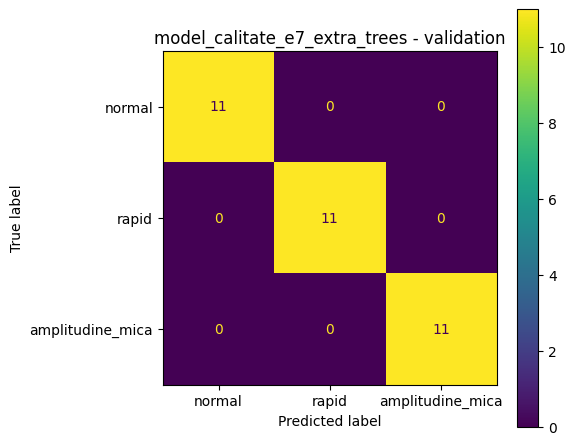

Matrice salvata in:
D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\modele_v2\confusion_matrices\calitate_e7\confusion_matrix_model_calitate_e7_extra_trees_validation.png

TESTING


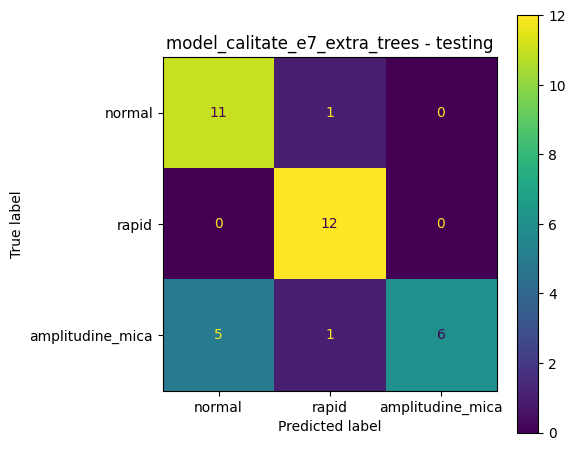

Matrice salvata in:
D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\modele_v2\confusion_matrices\calitate_e7\confusion_matrix_model_calitate_e7_extra_trees_testing.png
MODEL CALITATE E7: svm_rbf

VALIDATION


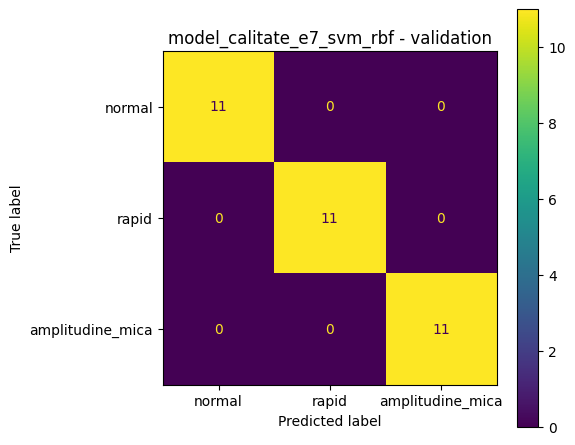

Matrice salvata in:
D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\modele_v2\confusion_matrices\calitate_e7\confusion_matrix_model_calitate_e7_svm_rbf_validation.png

TESTING


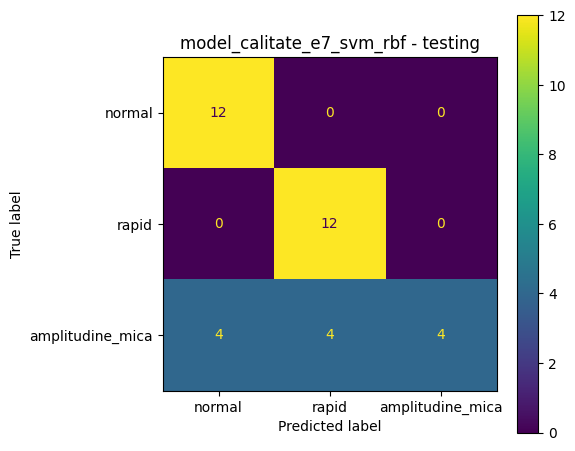

Matrice salvata in:
D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\modele_v2\confusion_matrices\calitate_e7\confusion_matrix_model_calitate_e7_svm_rbf_testing.png
MODEL CALITATE E7: logistic_regression

VALIDATION


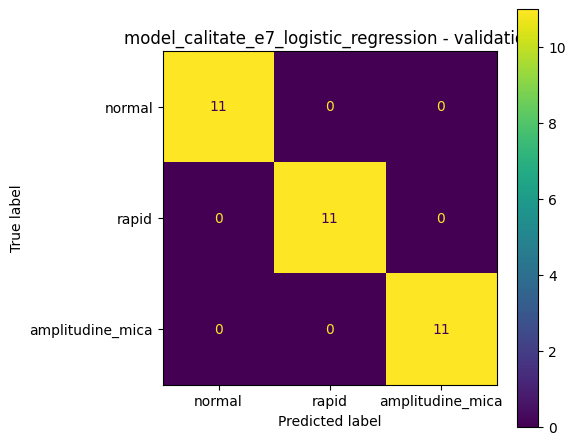

Matrice salvata in:
D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\modele_v2\confusion_matrices\calitate_e7\confusion_matrix_model_calitate_e7_logistic_regression_validation.png

TESTING


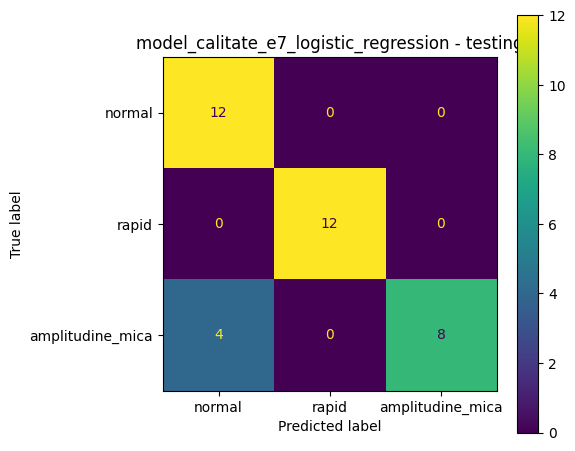

Matrice salvata in:
D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\modele_v2\confusion_matrices\calitate_e7\confusion_matrix_model_calitate_e7_logistic_regression_testing.png


In [122]:
# CELULA 57 - Reprezentare grafica matrici de confuzie pentru modelele e7
# NOU: pozele se salveaza in confusion_matrices/calitate_e7
# NOU: generam matrici atat pentru validation, cat si pentru testing

quality_e7_confusion_matrices = {}

quality_e7_confusion_dir = get_confusion_matrices_dir(
    "calitate_e7"
)

for model_name in quality_e7_candidate_models.keys():
    print("=" * 100)
    print(f"MODEL CALITATE E7: {model_name}")
    print("=" * 100)

    print()
    print("VALIDATION")

    validation_cm = afiseaza_si_salveaza_matrice_confuzie(
        y_true=y_validation_quality_e7,
        y_pred=quality_e7_predictions[model_name]["validation_pred"],
        labels=QUALITY_LABELS,
        display_labels=QUALITY_TARGET_NAMES,
        model_name=f"model_calitate_e7_{model_name}",
        set_name="validation",
        output_dir=quality_e7_confusion_dir,
    )

    print()
    print("TESTING")

    test_cm = afiseaza_si_salveaza_matrice_confuzie(
        y_true=y_test_quality_e7,
        y_pred=quality_e7_predictions[model_name]["test_pred"],
        labels=QUALITY_LABELS,
        display_labels=QUALITY_TARGET_NAMES,
        model_name=f"model_calitate_e7_{model_name}",
        set_name="testing",
        output_dir=quality_e7_confusion_dir,
    )

    quality_e7_confusion_matrices[model_name] = {
        "validation": validation_cm,
        "testing": test_cm,
    }

In [123]:
# CELULA 58 - Rapoarte detaliate pentru toate modelele de calitate e7
# NOU: pastram si raportul text, pe langa matricea grafica
# NOU: afisam classification report si confusion matrix tabelar pentru validation si testing

for model_name, model in quality_e7_candidate_models.items():
    print("=" * 100)
    print(f"MODEL CALITATE E7: {model_name}")
    print("=" * 100)

    print()
    print("VALIDATION")
    print(
        classification_report(
            y_validation_quality_e7,
            quality_e7_predictions[model_name]["validation_pred"],
            labels=QUALITY_LABELS,
            target_names=QUALITY_TARGET_NAMES,
            zero_division=0,
        )
    )

    validation_cm = confusion_matrix(
        y_validation_quality_e7,
        quality_e7_predictions[model_name]["validation_pred"],
        labels=QUALITY_LABELS,
    )

    validation_cm_df = pd.DataFrame(
        validation_cm,
        index=QUALITY_TARGET_NAMES,
        columns=QUALITY_TARGET_NAMES,
    )

    print("Confusion matrix validation:")
    display(
        validation_cm_df
    )

    print()
    print("TESTING")
    print(
        classification_report(
            y_test_quality_e7,
            quality_e7_predictions[model_name]["test_pred"],
            labels=QUALITY_LABELS,
            target_names=QUALITY_TARGET_NAMES,
            zero_division=0,
        )
    )

    test_cm = confusion_matrix(
        y_test_quality_e7,
        quality_e7_predictions[model_name]["test_pred"],
        labels=QUALITY_LABELS,
    )

    test_cm_df = pd.DataFrame(
        test_cm,
        index=QUALITY_TARGET_NAMES,
        columns=QUALITY_TARGET_NAMES,
    )

    print("Confusion matrix testing:")
    display(
        test_cm_df
    )

MODEL CALITATE E7: random_forest

VALIDATION
                  precision    recall  f1-score   support

          normal       1.00      1.00      1.00        11
           rapid       1.00      1.00      1.00        11
amplitudine_mica       1.00      1.00      1.00        11

        accuracy                           1.00        33
       macro avg       1.00      1.00      1.00        33
    weighted avg       1.00      1.00      1.00        33

Confusion matrix validation:


,normal,rapid,amplitudine_mica
normal,11,0,0
rapid,0,11,0
amplitudine_mica,0,0,11



TESTING
                  precision    recall  f1-score   support

          normal       0.80      1.00      0.89        12
           rapid       0.92      1.00      0.96        12
amplitudine_mica       1.00      0.67      0.80        12

        accuracy                           0.89        36
       macro avg       0.91      0.89      0.88        36
    weighted avg       0.91      0.89      0.88        36

Confusion matrix testing:


,normal,rapid,amplitudine_mica
normal,12,0,0
rapid,0,12,0
amplitudine_mica,3,1,8


MODEL CALITATE E7: extra_trees

VALIDATION
                  precision    recall  f1-score   support

          normal       1.00      1.00      1.00        11
           rapid       1.00      1.00      1.00        11
amplitudine_mica       1.00      1.00      1.00        11

        accuracy                           1.00        33
       macro avg       1.00      1.00      1.00        33
    weighted avg       1.00      1.00      1.00        33

Confusion matrix validation:


...

,normal,rapid,amplitudine_mica
normal,12,0,0
rapid,0,12,0
amplitudine_mica,4,4,4


MODEL CALITATE E7: logistic_regression

VALIDATION
                  precision    recall  f1-score   support

          normal       1.00      1.00      1.00        11
           rapid       1.00      1.00      1.00        11
amplitudine_mica       1.00      1.00      1.00        11

        accuracy                           1.00        33
       macro avg       1.00      1.00      1.00        33
    weighted avg       1.00      1.00      1.00        33

Confusion matrix validation:


,normal,rapid,amplitudine_mica
normal,11,0,0
rapid,0,11,0
amplitudine_mica,0,0,11



TESTING
                  precision    recall  f1-score   support

          normal       0.75      1.00      0.86        12
           rapid       1.00      1.00      1.00        12
amplitudine_mica       1.00      0.67      0.80        12

        accuracy                           0.89        36
       macro avg       0.92      0.89      0.89        36
    weighted avg       0.92      0.89      0.89        36

Confusion matrix testing:


,normal,rapid,amplitudine_mica
normal,12,0,0
rapid,0,12,0
amplitudine_mica,4,0,8


In [124]:
# CELULA 59 - Salvare rezultate comparatie modele calitate e7
# NOU: rezultatele se salveaza ca Excel in modele_joblib/calitate_e7
# NOU: salvam si CSV in acelasi folder

quality_e7_full_results_df = quality_e7_full_results_df.sort_values(
    by=[
        "combined_f1_macro",
        "combined_accuracy",
        "test_f1_macro",
        "test_accuracy",
    ],
    ascending=False,
).reset_index(
    drop=True
)

best_quality_e7_model_name = quality_e7_full_results_df.iloc[0]["model_name"]

best_quality_e7_model = quality_e7_candidate_models[
    best_quality_e7_model_name
]

print("=" * 80)
print("Model selectat pentru model_calitate_e7:")
print(best_quality_e7_model_name)

print()
print("Rezultate finale e7:")
display(
    quality_e7_full_results_df
)

quality_e7_results_excel_path = salveaza_rezultate_excel(
    rezultate_df=quality_e7_full_results_df,
    task_name="calitate_e7",
    nume_fisier="rezultate_calitate_e7.xlsx",
)

quality_e7_results_csv_path = get_joblib_models_dir(
    "calitate_e7"
) / "rezultate_calitate_e7.csv"

quality_e7_full_results_df.to_csv(
    quality_e7_results_csv_path,
    index=False,
)

print("Rezultatele e7 au fost salvate si ca CSV:")
print(quality_e7_results_csv_path)

Model selectat pentru model_calitate_e7:
logistic_regression

Rezultate finale e7:


,model_name,validation_accuracy,validation_precision_macro,validation_recall_macro,validation_f1_macro,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,combined_f1_macro,combined_accuracy
0,logistic_regression,1.0,1.0,1.0,1.0,0.888889,0.916667,0.888889,0.885714,0.942857,0.944444
1,random_forest,1.0,1.0,1.0,1.0,0.888889,0.907692,0.888889,0.882963,0.941481,0.944444
2,extra_trees,1.0,1.0,1.0,1.0,0.805556,0.848214,0.805556,0.791819,0.895910,0.902778
3,svm_rbf,1.0,1.0,1.0,1.0,0.777778,0.833333,0.777778,0.738095,0.869048,0.888889


Rezultatele au fost salvate in Excel:
D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\modele_v2\modele_joblib\calitate_e7\rezultate_calitate_e7.xlsx
Rezultatele e7 au fost salvate si ca CSV:
D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\modele_v2\modele_joblib\calitate_e7\rezultate_calitate_e7.csv


In [125]:
# CELULA 60 - Salvare toate modelele candidate pentru calitate e7
# NOU: modelele se salveaza in modele_joblib/calitate_e7

saved_quality_e7_model_paths = {}

quality_e7_models_dir = get_joblib_models_dir(
    "calitate_e7"
)

for model_name, model in quality_e7_candidate_models.items():
    model_path = quality_e7_models_dir / f"model_calitate_e7_{model_name}.joblib"

    joblib.dump(
        model,
        model_path,
    )

    saved_quality_e7_model_paths[model_name] = str(
        model_path
    )

    print(f"Model e7 salvat: {model_name}")
    print(model_path)
    print()

print("=" * 80)
print("Toate modelele pentru calitate e7 au fost salvate.")

Model e7 salvat: random_forest
D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\modele_v2\modele_joblib\calitate_e7\model_calitate_e7_random_forest.joblib

Model e7 salvat: extra_trees
D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\modele_v2\modele_joblib\calitate_e7\model_calitate_e7_extra_trees.joblib

Model e7 salvat: svm_rbf
D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\modele_v2\modele_joblib\calitate_e7\model_calitate_e7_svm_rbf.joblib

Model e7 salvat: logistic_regression
D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\modele_v2\modele_joblib\calitate_e7\model_calitate_e7_logistic_regression.joblib

Toate modelele pentru calitate e7 au fost salvate.


In [126]:
# CELULA 61 - Salvare model_calitate_e7 selectat pentru GUI
# NOU: modelul standard se salveaza in modele_joblib/calitate_e7

quality_e7_models_dir = get_joblib_models_dir(
    "calitate_e7"
)

model_calitate_e7_path = quality_e7_models_dir / "model_calitate_e7.joblib"

joblib.dump(
    best_quality_e7_model,
    model_calitate_e7_path,
)

print("Modelul selectat pentru GUI la e7 este:")
print(best_quality_e7_model_name)

print()
print("Modelul a fost salvat cu numele standard:")
print(model_calitate_e7_path)

Modelul selectat pentru GUI la e7 este:
logistic_regression

Modelul a fost salvat cu numele standard:
D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\modele_v2\modele_joblib\calitate_e7\model_calitate_e7.joblib


In [127]:
# Trecem la model_calitate_e8

In [128]:
# CELULA 62 - Pregatire date pentru modelul de calitate e8
# Modelul e8 va clasifica executia in: normal, rapid, amplitudine_mica
# Folosim doar exemplele la care exercitiul este e8

EXERCISE_FOR_QUALITY = 8

train_mask_e8 = (
    y_train_exercise == EXERCISE_FOR_QUALITY
)

validation_mask_e8 = (
    y_validation_exercise == EXERCISE_FOR_QUALITY
)

test_mask_e8 = (
    y_test_exercise == EXERCISE_FOR_QUALITY
)

X_train_e8 = X_train[
    train_mask_e8
]

y_train_quality_e8 = y_train_quality[
    train_mask_e8
]

X_validation_e8 = X_validation[
    validation_mask_e8
]

y_validation_quality_e8 = y_validation_quality[
    validation_mask_e8
]

X_test_e8 = X_test[
    test_mask_e8
]

y_test_quality_e8 = y_test_quality[
    test_mask_e8
]

print("=" * 80)
print("Date pentru model_calitate_e8")

print()
print("Training:")
print("X_train_e8:", X_train_e8.shape)
print("y_train_quality_e8:", y_train_quality_e8.shape)

print()
print("Validation:")
print("X_validation_e8:", X_validation_e8.shape)
print("y_validation_quality_e8:", y_validation_quality_e8.shape)

print()
print("Testing:")
print("X_test_e8:", X_test_e8.shape)
print("y_test_quality_e8:", y_test_quality_e8.shape)

train_distribution_e8 = afiseaza_distributie_calitate(
    y_train_quality_e8,
    "training",
)

validation_distribution_e8 = afiseaza_distributie_calitate(
    y_validation_quality_e8,
    "validation",
)

test_distribution_e8 = afiseaza_distributie_calitate(
    y_test_quality_e8,
    "testing",
)

Date pentru model_calitate_e8

Training:
X_train_e8: (75, 112)
y_train_quality_e8: (75,)

Validation:
X_validation_e8: (57, 112)
y_validation_quality_e8: (57,)

Testing:
X_test_e8: (36, 112)
y_test_quality_e8: (36,)

Distributie clase training:


,quality_label,quality_name,numar_exemple
0,1,normal,25
1,2,rapid,25
2,3,amplitudine_mica,25



Distributie clase validation:


,quality_label,quality_name,numar_exemple
0,1,normal,19
1,2,rapid,19
2,3,amplitudine_mica,19



Distributie clase testing:


,quality_label,quality_name,numar_exemple
0,1,normal,12
1,2,rapid,12
2,3,amplitudine_mica,12


In [129]:
# CELULA 63 - Definire modele candidate pentru modelul de calitate e8
# NOU: folosim aceiasi 4 clasificatori ca la e6 si e7
# NOU: cream modele noi, curate, special pentru calitatea exercitiului e8

quality_e8_candidate_models = creeaza_modele_candidate_calitate()

print("Modele candidate pentru model_calitate_e8:")
print(
    list(
        quality_e8_candidate_models.keys()
    )
)

Modele candidate pentru model_calitate_e8:
['random_forest', 'extra_trees', 'svm_rbf', 'logistic_regression']


In [130]:
# CELULA 64 - Antrenare modele candidate pentru modelul de calitate e8
# NOU: antrenam toate cele 4 modele pentru calitatea exercitiului e8
# NOU: validam fiecare model pe X_validation_e8 si y_validation_quality_e8

quality_e8_validation_results = []

for model_name, model in quality_e8_candidate_models.items():
    print("=" * 80)
    print(f"Antrenez modelul pentru e8: {model_name}")

    model.fit(
        X_train_e8,
        y_train_quality_e8,
    )

    y_validation_pred = model.predict(
        X_validation_e8
    )

    validation_accuracy = accuracy_score(
        y_validation_quality_e8,
        y_validation_pred,
    )

    validation_f1_macro = f1_score(
        y_validation_quality_e8,
        y_validation_pred,
        average="macro",
        zero_division=0,
    )

    quality_e8_validation_results.append({
        "model_name": model_name,
        "validation_accuracy": validation_accuracy,
        "validation_f1_macro": validation_f1_macro,
    })

    print("Validation accuracy:", validation_accuracy)
    print("Validation F1 macro:", validation_f1_macro)

quality_e8_validation_results_df = pd.DataFrame(
    quality_e8_validation_results
).sort_values(
    by=[
        "validation_f1_macro",
        "validation_accuracy",
    ],
    ascending=False,
).reset_index(
    drop=True
)

display(
    quality_e8_validation_results_df
)

Antrenez modelul pentru e8: random_forest
Validation accuracy: 1.0
Validation F1 macro: 1.0
Antrenez modelul pentru e8: extra_trees
Validation accuracy: 1.0
Validation F1 macro: 1.0
Antrenez modelul pentru e8: svm_rbf
Validation accuracy: 1.0
Validation F1 macro: 1.0
Antrenez modelul pentru e8: logistic_regression
Validation accuracy: 1.0
Validation F1 macro: 1.0


,model_name,validation_accuracy,validation_f1_macro
0,random_forest,1.0,1.0
1,extra_trees,1.0,1.0
2,svm_rbf,1.0,1.0
3,logistic_regression,1.0,1.0


In [131]:
# CELULA 65 - Evaluare toate modelele candidate pentru calitate e8 pe validation si testing
# NOU: pastram toate cele 4 modele pana la testare
# NOU: calculam accuracy, precision_macro, recall_macro si f1_macro
# NOU: comparam modelele atat pe validation, cat si pe testing

quality_e8_full_results = []
quality_e8_predictions = {}

for model_name, model in quality_e8_candidate_models.items():
    print("=" * 80)
    print(f"Evaluez modelul pentru e8: {model_name}")

    validation_metrics = calculeaza_metrici_clasificare(
        model,
        X_validation_e8,
        y_validation_quality_e8,
    )

    test_metrics = calculeaza_metrici_clasificare(
        model,
        X_test_e8,
        y_test_quality_e8,
    )

    quality_e8_predictions[model_name] = {
        "validation_pred": validation_metrics["y_pred"],
        "test_pred": test_metrics["y_pred"],
    }

    quality_e8_full_results.append({
        "model_name": model_name,

        "validation_accuracy": validation_metrics["accuracy"],
        "validation_precision_macro": validation_metrics["precision_macro"],
        "validation_recall_macro": validation_metrics["recall_macro"],
        "validation_f1_macro": validation_metrics["f1_macro"],

        "test_accuracy": test_metrics["accuracy"],
        "test_precision_macro": test_metrics["precision_macro"],
        "test_recall_macro": test_metrics["recall_macro"],
        "test_f1_macro": test_metrics["f1_macro"],
    })

quality_e8_full_results_df = pd.DataFrame(
    quality_e8_full_results
)

quality_e8_full_results_df["combined_f1_macro"] = (
    quality_e8_full_results_df["validation_f1_macro"]
    + quality_e8_full_results_df["test_f1_macro"]
) / 2

quality_e8_full_results_df["combined_accuracy"] = (
    quality_e8_full_results_df["validation_accuracy"]
    + quality_e8_full_results_df["test_accuracy"]
) / 2

quality_e8_full_results_df = quality_e8_full_results_df.sort_values(
    by=[
        "combined_f1_macro",
        "combined_accuracy",
        "test_f1_macro",
        "test_accuracy",
    ],
    ascending=False,
).reset_index(
    drop=True
)

display(
    quality_e8_full_results_df
)

Evaluez modelul pentru e8: random_forest
Evaluez modelul pentru e8: extra_trees
Evaluez modelul pentru e8: svm_rbf
Evaluez modelul pentru e8: logistic_regression


,model_name,validation_accuracy,validation_precision_macro,validation_recall_macro,validation_f1_macro,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,combined_f1_macro,combined_accuracy
0,random_forest,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1,extra_trees,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2,svm_rbf,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
3,logistic_regression,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [132]:
# CELULA 66 - Alegere model recomandat pentru model_calitate_e8
# NOU: alegem modelul dupa scor combinat validation + testing

best_quality_e8_model_name = quality_e8_full_results_df.iloc[0]["model_name"]

best_quality_e8_model = quality_e8_candidate_models[
    best_quality_e8_model_name
]

print("=" * 80)
print("Rezultate modele calitate e8, sortate dupa scor combinat")
display(
    quality_e8_full_results_df
)

print("=" * 80)
print("Model selectat pentru model_calitate_e8:")
print(best_quality_e8_model_name)

print()
print("Criteriu folosit:")
print("combined_f1_macro = media dintre validation_f1_macro si test_f1_macro")

Rezultate modele calitate e8, sortate dupa scor combinat


,model_name,validation_accuracy,validation_precision_macro,validation_recall_macro,validation_f1_macro,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,combined_f1_macro,combined_accuracy
0,random_forest,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1,extra_trees,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2,svm_rbf,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
3,logistic_regression,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


Model selectat pentru model_calitate_e8:
random_forest

Criteriu folosit:
combined_f1_macro = media dintre validation_f1_macro si test_f1_macro


MODEL CALITATE E8: random_forest

VALIDATION


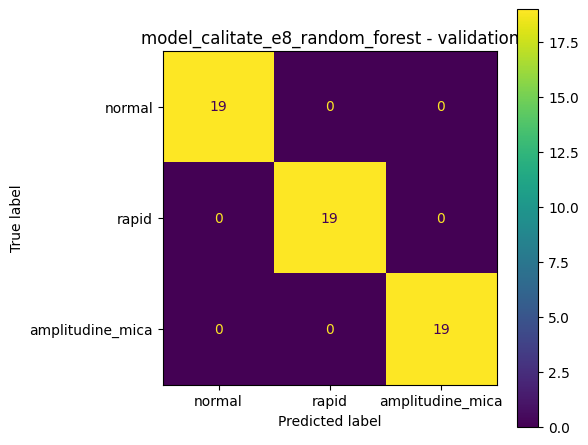

Matrice salvata in:
D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\modele_v2\confusion_matrices\calitate_e8\confusion_matrix_model_calitate_e8_random_forest_validation.png

TESTING


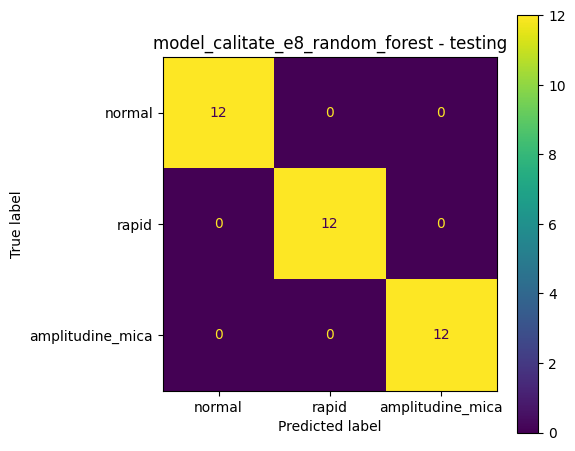

Matrice salvata in:
D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\modele_v2\confusion_matrices\calitate_e8\confusion_matrix_model_calitate_e8_random_forest_testing.png
MODEL CALITATE E8: extra_trees

VALIDATION


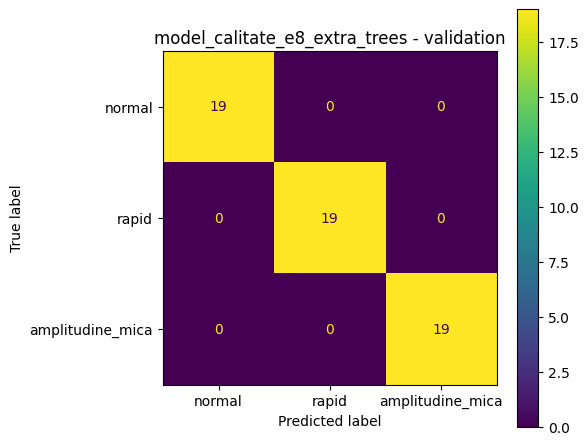

Matrice salvata in:
D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\modele_v2\confusion_matrices\calitate_e8\confusion_matrix_model_calitate_e8_extra_trees_validation.png

TESTING


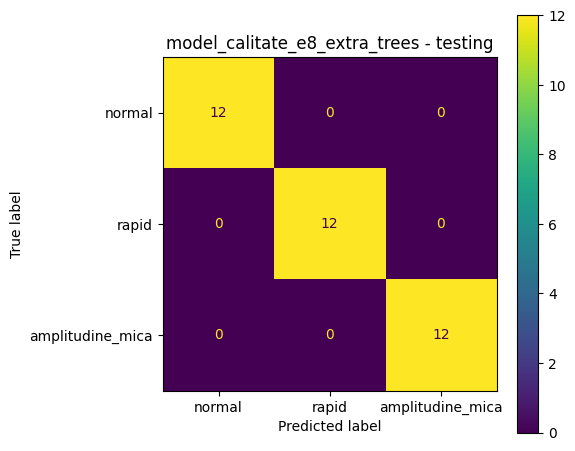

Matrice salvata in:
D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\modele_v2\confusion_matrices\calitate_e8\confusion_matrix_model_calitate_e8_extra_trees_testing.png
MODEL CALITATE E8: svm_rbf

VALIDATION


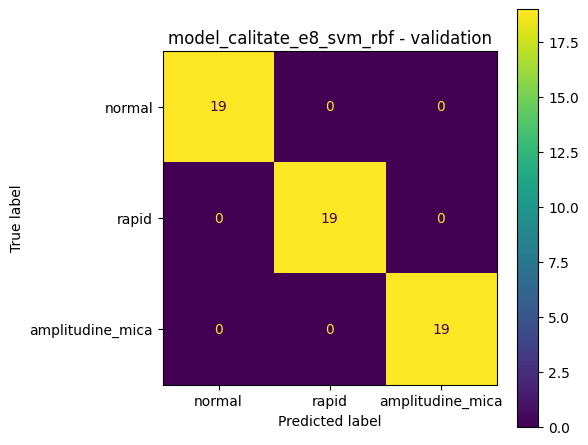

Matrice salvata in:
D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\modele_v2\confusion_matrices\calitate_e8\confusion_matrix_model_calitate_e8_svm_rbf_validation.png

TESTING


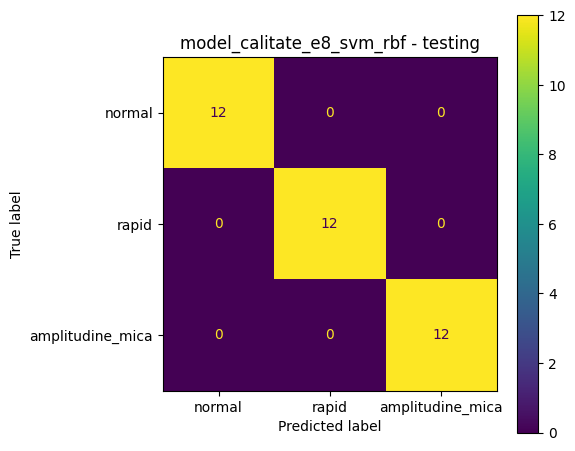

Matrice salvata in:
D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\modele_v2\confusion_matrices\calitate_e8\confusion_matrix_model_calitate_e8_svm_rbf_testing.png
MODEL CALITATE E8: logistic_regression

VALIDATION


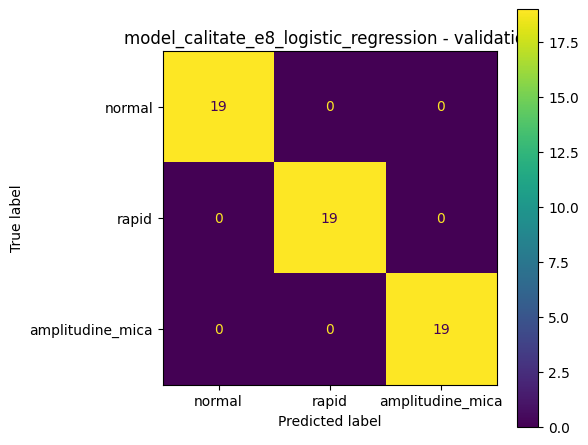

Matrice salvata in:
D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\modele_v2\confusion_matrices\calitate_e8\confusion_matrix_model_calitate_e8_logistic_regression_validation.png

TESTING


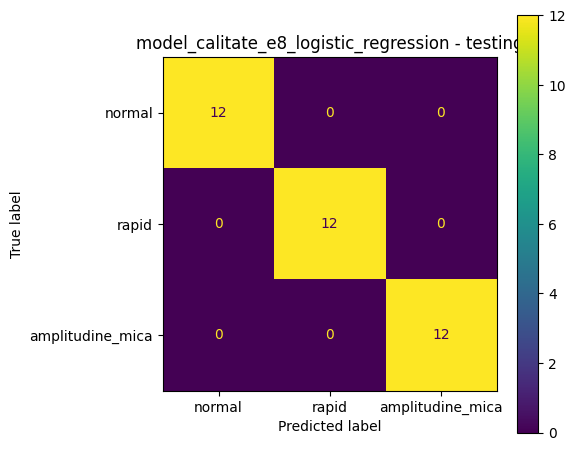

Matrice salvata in:
D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\modele_v2\confusion_matrices\calitate_e8\confusion_matrix_model_calitate_e8_logistic_regression_testing.png


In [133]:
# CELULA 67 - Reprezentare grafica matrici de confuzie pentru modelele e8
# NOU: pozele se salveaza in confusion_matrices/calitate_e8
# NOU: generam matrici atat pentru validation, cat si pentru testing

quality_e8_confusion_matrices = {}

quality_e8_confusion_dir = get_confusion_matrices_dir(
    "calitate_e8"
)

for model_name in quality_e8_candidate_models.keys():
    print("=" * 100)
    print(f"MODEL CALITATE E8: {model_name}")
    print("=" * 100)

    print()
    print("VALIDATION")

    validation_cm = afiseaza_si_salveaza_matrice_confuzie(
        y_true=y_validation_quality_e8,
        y_pred=quality_e8_predictions[model_name]["validation_pred"],
        labels=QUALITY_LABELS,
        display_labels=QUALITY_TARGET_NAMES,
        model_name=f"model_calitate_e8_{model_name}",
        set_name="validation",
        output_dir=quality_e8_confusion_dir,
    )

    print()
    print("TESTING")

    test_cm = afiseaza_si_salveaza_matrice_confuzie(
        y_true=y_test_quality_e8,
        y_pred=quality_e8_predictions[model_name]["test_pred"],
        labels=QUALITY_LABELS,
        display_labels=QUALITY_TARGET_NAMES,
        model_name=f"model_calitate_e8_{model_name}",
        set_name="testing",
        output_dir=quality_e8_confusion_dir,
    )

    quality_e8_confusion_matrices[model_name] = {
        "validation": validation_cm,
        "testing": test_cm,
    }

In [134]:
# CELULA 68 - Rapoarte detaliate pentru toate modelele de calitate e8
# NOU: pastram si raportul text, pe langa matricea grafica
# NOU: afisam classification report si confusion matrix tabelar pentru validation si testing

for model_name, model in quality_e8_candidate_models.items():
    print("=" * 100)
    print(f"MODEL CALITATE E8: {model_name}")
    print("=" * 100)

    print()
    print("VALIDATION")
    print(
        classification_report(
            y_validation_quality_e8,
            quality_e8_predictions[model_name]["validation_pred"],
            labels=QUALITY_LABELS,
            target_names=QUALITY_TARGET_NAMES,
            zero_division=0,
        )
    )

    validation_cm = confusion_matrix(
        y_validation_quality_e8,
        quality_e8_predictions[model_name]["validation_pred"],
        labels=QUALITY_LABELS,
    )

    validation_cm_df = pd.DataFrame(
        validation_cm,
        index=QUALITY_TARGET_NAMES,
        columns=QUALITY_TARGET_NAMES,
    )

    print("Confusion matrix validation:")
    display(
        validation_cm_df
    )

    print()
    print("TESTING")
    print(
        classification_report(
            y_test_quality_e8,
            quality_e8_predictions[model_name]["test_pred"],
            labels=QUALITY_LABELS,
            target_names=QUALITY_TARGET_NAMES,
            zero_division=0,
        )
    )

    test_cm = confusion_matrix(
        y_test_quality_e8,
        quality_e8_predictions[model_name]["test_pred"],
        labels=QUALITY_LABELS,
    )

    test_cm_df = pd.DataFrame(
        test_cm,
        index=QUALITY_TARGET_NAMES,
        columns=QUALITY_TARGET_NAMES,
    )

    print("Confusion matrix testing:")
    display(
        test_cm_df
    )

MODEL CALITATE E8: random_forest

VALIDATION
                  precision    recall  f1-score   support

          normal       1.00      1.00      1.00        19
           rapid       1.00      1.00      1.00        19
amplitudine_mica       1.00      1.00      1.00        19

        accuracy                           1.00        57
       macro avg       1.00      1.00      1.00        57
    weighted avg       1.00      1.00      1.00        57

Confusion matrix validation:


,normal,rapid,amplitudine_mica
normal,19,0,0
rapid,0,19,0
amplitudine_mica,0,0,19



TESTING
                  precision    recall  f1-score   support

          normal       1.00      1.00      1.00        12
           rapid       1.00      1.00      1.00        12
amplitudine_mica       1.00      1.00      1.00        12

        accuracy                           1.00        36
       macro avg       1.00      1.00      1.00        36
    weighted avg       1.00      1.00      1.00        36

Confusion matrix testing:


,normal,rapid,amplitudine_mica
normal,12,0,0
rapid,0,12,0
amplitudine_mica,0,0,12


MODEL CALITATE E8: extra_trees

VALIDATION
                  precision    recall  f1-score   support

          normal       1.00      1.00      1.00        19
           rapid       1.00      1.00      1.00        19
amplitudine_mica       1.00      1.00      1.00        19

        accuracy                           1.00        57
       macro avg       1.00      1.00      1.00        57
    weighted avg       1.00      1.00      1.00        57

Confusion matrix validation:


...

,normal,rapid,amplitudine_mica
normal,12,0,0
rapid,0,12,0
amplitudine_mica,0,0,12


MODEL CALITATE E8: logistic_regression

VALIDATION
                  precision    recall  f1-score   support

          normal       1.00      1.00      1.00        19
           rapid       1.00      1.00      1.00        19
amplitudine_mica       1.00      1.00      1.00        19

        accuracy                           1.00        57
       macro avg       1.00      1.00      1.00        57
    weighted avg       1.00      1.00      1.00        57

Confusion matrix validation:


,normal,rapid,amplitudine_mica
normal,19,0,0
rapid,0,19,0
amplitudine_mica,0,0,19



TESTING
                  precision    recall  f1-score   support

          normal       1.00      1.00      1.00        12
           rapid       1.00      1.00      1.00        12
amplitudine_mica       1.00      1.00      1.00        12

        accuracy                           1.00        36
       macro avg       1.00      1.00      1.00        36
    weighted avg       1.00      1.00      1.00        36

Confusion matrix testing:


,normal,rapid,amplitudine_mica
normal,12,0,0
rapid,0,12,0
amplitudine_mica,0,0,12


In [146]:
# CELULA 69 - Salvare rezultate comparatie modele calitate e8
# NOU: rezultatele se salveaza ca Excel in modele_joblib/calitate_e8
# NOU: salvam si CSV in acelasi folder

quality_e8_full_results_df = quality_e8_full_results_df.sort_values(
    by=[
        "combined_f1_macro",
        "combined_accuracy",
        "test_f1_macro",
        "test_accuracy",
    ],
    ascending=False,
).reset_index(
    drop=True
)

best_quality_e8_model_name = quality_e8_full_results_df.iloc[0]["model_name"]

best_quality_e8_model = quality_e8_candidate_models[
    best_quality_e8_model_name
]

print("=" * 80)
print("Model selectat pentru model_calitate_e8:")
print(best_quality_e8_model_name)

print()
print("Rezultate finale e8:")
display(
    quality_e8_full_results_df
)

quality_e8_results_excel_path = salveaza_rezultate_excel(
    rezultate_df=quality_e8_full_results_df,
    task_name="calitate_e8",
    nume_fisier="rezultate_calitate_e8.xlsx",
)

quality_e8_results_csv_path = get_joblib_models_dir(
    "calitate_e8"
) / "rezultate_calitate_e8.csv"

quality_e8_full_results_df.to_csv(
    quality_e8_results_csv_path,
    index=False,
)

print("Rezultatele e8 au fost salvate si ca CSV:")
print(quality_e8_results_csv_path)

Model selectat pentru model_calitate_e8:
random_forest

Rezultate finale e8:


,model_name,validation_accuracy,validation_precision_macro,validation_recall_macro,validation_f1_macro,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,combined_f1_macro,combined_accuracy
0,random_forest,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1,extra_trees,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2,svm_rbf,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
3,logistic_regression,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


Rezultatele au fost salvate in Excel:
D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\modele_v2\modele_joblib\calitate_e8\rezultate_calitate_e8.xlsx
Rezultatele e8 au fost salvate si ca CSV:
D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\modele_v2\modele_joblib\calitate_e8\rezultate_calitate_e8.csv


In [147]:
# CELULA 70 - Salvare toate modelele candidate pentru calitate e8
# NOU: modelele se salveaza in modele_joblib/calitate_e8

saved_quality_e8_model_paths = {}

quality_e8_models_dir = get_joblib_models_dir(
    "calitate_e8"
)

for model_name, model in quality_e8_candidate_models.items():
    model_path = quality_e8_models_dir / f"model_calitate_e8_{model_name}.joblib"

    joblib.dump(
        model,
        model_path,
    )

    saved_quality_e8_model_paths[model_name] = str(
        model_path
    )

    print(f"Model e8 salvat: {model_name}")
    print(model_path)
    print()

print("=" * 80)
print("Toate modelele pentru calitate e8 au fost salvate.")

Model e8 salvat: random_forest
D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\modele_v2\modele_joblib\calitate_e8\model_calitate_e8_random_forest.joblib

Model e8 salvat: extra_trees
D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\modele_v2\modele_joblib\calitate_e8\model_calitate_e8_extra_trees.joblib

Model e8 salvat: svm_rbf
D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\modele_v2\modele_joblib\calitate_e8\model_calitate_e8_svm_rbf.joblib

Model e8 salvat: logistic_regression
D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\modele_v2\modele_joblib\calitate_e8\model_calitate_e8_logistic_regression.joblib

Toate modelele pentru calitate e8 au fost salvate.


In [148]:
# CELULA 71 - Salvare model_calitate_e8 selectat pentru GUI
# NOU: modelul standard se salveaza in modele_joblib/calitate_e8

quality_e8_models_dir = get_joblib_models_dir(
    "calitate_e8"
)

model_calitate_e8_path = quality_e8_models_dir / "model_calitate_e8.joblib"

joblib.dump(
    best_quality_e8_model,
    model_calitate_e8_path,
)

print("Modelul selectat pentru GUI la e8 este:")
print(best_quality_e8_model_name)

print()
print("Modelul a fost salvat cu numele standard:")
print(model_calitate_e8_path)

Modelul selectat pentru GUI la e8 este:
random_forest

Modelul a fost salvat cu numele standard:
D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\modele_v2\modele_joblib\calitate_e8\model_calitate_e8.joblib


In [ ]:
# Scor cam suspicios de bun, verificam datele in e8, daca exista leakage

In [138]:
# CELULA 72 - Verificare distributie e8 pe subiecti si surse
# NOU: verificam daca e8 are date prea similare intre training, validation si testing
# NOU: verificam pacientii, folderele originale si fisierele sursa pentru e8

metadata_train_e8 = metadata_train[
    metadata_train["exercise_label"] == 8
].copy()

metadata_validation_e8 = metadata_validation[
    metadata_validation["exercise_label"] == 8
].copy()

metadata_test_e8 = metadata_test[
    metadata_test["exercise_label"] == 8
].copy()


def afiseaza_rezumat_metadata_e8(metadata_df, nume_set):
    print("=" * 80)
    print(f"Rezumat metadata e8 - {nume_set}")
    print("=" * 80)

    print("Numar exemple:", len(metadata_df))

    print()
    print("Distributie original_subject:")
    display(
        metadata_df["original_subject"]
        .value_counts()
        .sort_index()
        .reset_index()
        .rename(
            columns={
                "index": "original_subject",
                "original_subject": "numar_exemple",
            }
        )
    )

    print()
    print("Distributie subject:")
    display(
        metadata_df["subject"]
        .value_counts()
        .sort_index()
        .reset_index()
        .rename(
            columns={
                "index": "subject",
                "subject": "numar_exemple",
            }
        )
    )

    print()
    print("Distributie source_kind:")
    display(
        metadata_df["source_kind"]
        .value_counts()
        .reset_index()
        .rename(
            columns={
                "index": "source_kind",
                "source_kind": "numar_exemple",
            }
        )
    )

    print()
    print("Distributie source_file:")
    display(
        metadata_df["source_file"]
        .value_counts()
        .sort_index()
        .reset_index()
        .rename(
            columns={
                "index": "source_file",
                "source_file": "numar_exemple",
            }
        )
    )


afiseaza_rezumat_metadata_e8(
    metadata_train_e8,
    "training",
)

afiseaza_rezumat_metadata_e8(
    metadata_validation_e8,
    "validation",
)

afiseaza_rezumat_metadata_e8(
    metadata_test_e8,
    "testing",
)

Rezumat metadata e8 - training
Numar exemple: 75

Distributie original_subject:


,numar_exemple,count
0,s11,24
1,s12,24
2,s2,9
3,s3,9
4,s4,9



Distributie subject:


,numar_exemple,count
0,s11,6
1,s11_p1,6
2,s11_p2,6
3,s11_p3,6
4,s12,6
5,s12_p1,6
6,s12_p2,6
7,s12_p3,6
8,s2,3
9,s2_p2,3



Distributie source_kind:


...

,numar_exemple,count
0,s14,6
1,s14_p1,6
2,s14_p2,6
3,s14_p3,6
4,s5,3
5,s5_p1,3
6,s5_p2,3
7,s5_p3,3



Distributie source_kind:


,numar_exemple,count
0,augmented,27
1,original,9



Distributie source_file:


,numar_exemple,count
0,ex8_long_bno055_20260617_184740_448857.txt,12
1,ex8_scrt_bno055_20260617_182746_365845.txt,12
2,template_session.txt,12


In [139]:
# CELULA 73 - Verificare suprapuneri intre split-uri pentru e8
# NOU: verificam daca aceiasi subiecti/fisiere apar in mai multe split-uri

def set_valori(metadata_df, coloana):
    return set(
        metadata_df[coloana]
        .astype(str)
        .unique()
    )


for coloana in [
    "original_subject",
    "subject",
    "source_file",
    "template_file",
]:
    train_values = set_valori(
        metadata_train_e8,
        coloana,
    )

    validation_values = set_valori(
        metadata_validation_e8,
        coloana,
    )

    test_values = set_valori(
        metadata_test_e8,
        coloana,
    )

    print("=" * 80)
    print(f"Verificare suprapunere coloana: {coloana}")

    print("Train ∩ Validation:", sorted(train_values & validation_values))
    print("Train ∩ Test:", sorted(train_values & test_values))
    print("Validation ∩ Test:", sorted(validation_values & test_values))

Verificare suprapunere coloana: original_subject
Train ∩ Validation: ['s2', 's3', 's4']
Train ∩ Test: []
Validation ∩ Test: []
Verificare suprapunere coloana: subject
Train ∩ Validation: []
Train ∩ Test: []
Validation ∩ Test: []
Verificare suprapunere coloana: source_file
Train ∩ Validation: ['template_session.txt']
Train ∩ Test: ['template_session.txt']
Validation ∩ Test: ['template_session.txt']
Verificare suprapunere coloana: template_file
Train ∩ Validation: ['template_times.txt', 'template_times_long.txt', 'template_times_scrt.txt']
Train ∩ Test: ['template_times.txt', 'template_times_long.txt', 'template_times_scrt.txt']
Validation ∩ Test: ['template_times.txt', 'template_times_long.txt', 'template_times_scrt.txt']


In [140]:
# CELULA 74 - Verificare feature-uri importante pentru e8
# NOU: verificam daca anumite feature-uri separa foarte clar clasele de calitate

e8_features_df = test_features_df[
    test_features_df["exercise_label"] == 8
].copy()

feature_columns_to_check = [
    "duration_seconds",
    "acc_energy",
    "gyr_energy",
    "acc_magnitude_mean",
    "acc_magnitude_std",
    "gyr_magnitude_mean",
    "gyr_magnitude_std",
    "acc_jerk_mean_abs",
    "gyr_jerk_mean_abs",
]

feature_columns_to_check = [
    coloana
    for coloana in feature_columns_to_check
    if coloana in e8_features_df.columns
]

e8_feature_summary = e8_features_df.groupby(
    "quality_name"
)[
    feature_columns_to_check
].agg(
    [
        "mean",
        "std",
        "min",
        "max",
    ]
)

display(
    e8_feature_summary
)

duration_seconds                                     \
                             mean        std   min    max       mean   
quality_name                                                           
amplitudine_mica        28.293333  25.085844  3.80  60.92  28.293333   
normal                  28.453333  23.903961  4.24  59.16  28.453333   
rapid                    7.720000   6.436171  2.20  16.32   7.720000   

                                          acc_energy            ...  \
                        std   min    max        mean       std  ...   
quality_name                                                    ...   
amplitudine_mica  25.085844  3.80  60.92   94.617080  3.922012  ...   
normal            23.903961  4.24  59.16   96.921650  6.837208  ...   
rapid              6.436171  2.20  16.32  109.103379  5.806659  ...   

                 gyr_magnitude_std            acc_jerk_mean_abs             \
                               min        max              mean        std   
quality_name                                                                 
amplitudine_mica          0.930599  25.813437         13.823136   8.134931   
normal                    1.522125  43.450435         22.863460  12.386735   
rapid                     1.859235  65.173349         51.025509   8.362516   

                                       gyr_jerk_mean_abs              \
                        min        max              mean         std   
quality_name                                                           
amplitudine_mica   7.333309  25.331354        117.215918   82.127861   
normal            13.877569  40.249888        209.440026  148.401262   
rapid             43.944009  63.464177        718.830573  519.824382   

                                          
                        min          max  
quality_name                              
amplitudine_mica   8.627266   196.598272  
normal            11.282098   344.766926  
rapid             17.570771  1144.560226  

[3 rows x 40 columns]

In [141]:
# CELULA 75 - Verificare e8 doar pe exemple originale din testing
# NOU: verificam performanta pe test original-only, fara fisiere augmentate

metadata_test_e8 = metadata_test[
    metadata_test["exercise_label"] == 8
].copy().reset_index(
    drop=True
)

original_only_mask_e8 = (
    metadata_test_e8["source_kind"] == "original"
).to_numpy()

X_test_e8_original_only = X_test_e8[
    original_only_mask_e8
]

y_test_quality_e8_original_only = y_test_quality_e8[
    original_only_mask_e8
]

print("=" * 80)
print("Testing e8 doar pe exemple originale")
print("X_test_e8_original_only:", X_test_e8_original_only.shape)
print("y_test_quality_e8_original_only:", y_test_quality_e8_original_only.shape)

quality_e8_original_only_results = []

for model_name, model in quality_e8_candidate_models.items():
    metrics = calculeaza_metrici_clasificare(
        model,
        X_test_e8_original_only,
        y_test_quality_e8_original_only,
    )

    quality_e8_original_only_results.append({
        "model_name": model_name,
        "test_original_only_accuracy": metrics["accuracy"],
        "test_original_only_precision_macro": metrics["precision_macro"],
        "test_original_only_recall_macro": metrics["recall_macro"],
        "test_original_only_f1_macro": metrics["f1_macro"],
    })

quality_e8_original_only_results_df = pd.DataFrame(
    quality_e8_original_only_results
).sort_values(
    by=[
        "test_original_only_f1_macro",
        "test_original_only_accuracy",
    ],
    ascending=False,
).reset_index(
    drop=True
)

display(
    quality_e8_original_only_results_df
)

Testing e8 doar pe exemple originale
X_test_e8_original_only: (9, 112)
y_test_quality_e8_original_only: (9,)


,model_name,test_original_only_accuracy,test_original_only_precision_macro,test_original_only_recall_macro,test_original_only_f1_macro
0,random_forest,1.0,1.0,1.0,1.0
1,extra_trees,1.0,1.0,1.0,1.0
2,svm_rbf,1.0,1.0,1.0,1.0
3,logistic_regression,1.0,1.0,1.0,1.0


In [142]:
# CELULA 76 - Verificare e8 fara feature-uri legate direct de durata
# NOU: eliminam duration_seconds pentru a vedea daca scorul ramane foarte bun

features_to_remove_for_check = [
    "duration_seconds",
]

feature_indices_without_duration = [
    index
    for index, feature_name in enumerate(FEATURE_NAMES)
    if feature_name not in features_to_remove_for_check
]

X_train_e8_no_duration = X_train_e8[
    :,
    feature_indices_without_duration
]

X_validation_e8_no_duration = X_validation_e8[
    :,
    feature_indices_without_duration
]

X_test_e8_no_duration = X_test_e8[
    :,
    feature_indices_without_duration
]

quality_e8_no_duration_models = creeaza_modele_candidate_calitate()

quality_e8_no_duration_results = []

for model_name, model in quality_e8_no_duration_models.items():
    print("=" * 80)
    print(f"Antrenez e8 fara duration_seconds: {model_name}")

    model.fit(
        X_train_e8_no_duration,
        y_train_quality_e8,
    )

    validation_metrics = calculeaza_metrici_clasificare(
        model,
        X_validation_e8_no_duration,
        y_validation_quality_e8,
    )

    test_metrics = calculeaza_metrici_clasificare(
        model,
        X_test_e8_no_duration,
        y_test_quality_e8,
    )

    quality_e8_no_duration_results.append({
        "model_name": model_name,
        "validation_accuracy": validation_metrics["accuracy"],
        "validation_f1_macro": validation_metrics["f1_macro"],
        "test_accuracy": test_metrics["accuracy"],
        "test_f1_macro": test_metrics["f1_macro"],
    })

quality_e8_no_duration_results_df = pd.DataFrame(
    quality_e8_no_duration_results
).sort_values(
    by=[
        "test_f1_macro",
        "test_accuracy",
        "validation_f1_macro",
    ],
    ascending=False,
).reset_index(
    drop=True
)

display(
    quality_e8_no_duration_results_df
)

Antrenez e8 fara duration_seconds: random_forest
Antrenez e8 fara duration_seconds: extra_trees
Antrenez e8 fara duration_seconds: svm_rbf
Antrenez e8 fara duration_seconds: logistic_regression


,model_name,validation_accuracy,validation_f1_macro,test_accuracy,test_f1_macro
0,random_forest,1.0,1.0,1.0,1.0
1,extra_trees,1.0,1.0,1.0,1.0
2,svm_rbf,1.0,1.0,1.0,1.0
3,logistic_regression,1.0,1.0,1.0,1.0


In [149]:
# Rezumat final modele selectate pentru GUI

In [150]:
# CELULA 77 - Rezumat final al modelelor selectate pentru GUI
# NOU: verificam modelele standard care vor fi incarcate in interfata GUI
# NOU: verificam daca fisierele .joblib exista pe disc
# NOU: centralizam ce clasificator a fost ales pentru fiecare task

modele_gui_summary = [
    {
        "task": "identificare_exercitii",
        "model_standard": "model_identificare_exercitii.joblib",
        "clasificator_selectat": best_exercise_model_name,
        "cale_model": get_joblib_models_dir("identificare_exercitii") / "model_identificare_exercitii.joblib",
    },
    {
        "task": "calitate_e6",
        "model_standard": "model_calitate_e6.joblib",
        "clasificator_selectat": best_quality_e6_model_name,
        "cale_model": get_joblib_models_dir("calitate_e6") / "model_calitate_e6.joblib",
    },
    {
        "task": "calitate_e7",
        "model_standard": "model_calitate_e7.joblib",
        "clasificator_selectat": best_quality_e7_model_name,
        "cale_model": get_joblib_models_dir("calitate_e7") / "model_calitate_e7.joblib",
    },
    {
        "task": "calitate_e8",
        "model_standard": "model_calitate_e8.joblib",
        "clasificator_selectat": best_quality_e8_model_name,
        "cale_model": get_joblib_models_dir("calitate_e8") / "model_calitate_e8.joblib",
    },
]

modele_gui_summary_df = pd.DataFrame(
    modele_gui_summary
)

modele_gui_summary_df["exista_fisier"] = modele_gui_summary_df[
    "cale_model"
].apply(
    lambda cale: Path(cale).exists()
)

modele_gui_summary_df["cale_model"] = modele_gui_summary_df[
    "cale_model"
].astype(
    str
)

display(
    modele_gui_summary_df
)

,task,model_standard,clasificator_selectat,cale_model,exista_fisier
0,identificare_exercitii,model_identificare_exercitii.joblib,svm_rbf,D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\a...,True
1,calitate_e6,model_calitate_e6.joblib,random_forest,D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\a...,True
2,calitate_e7,model_calitate_e7.joblib,logistic_regression,D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\a...,True
3,calitate_e8,model_calitate_e8.joblib,random_forest,D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\a...,True


In [151]:
# CELULA 78 - Salvare rezumat final al modelelor pentru GUI
# NOU: salvam un Excel centralizat cu modelele finale selectate pentru interfata

rezumat_gui_path = JOBLIB_MODELS_ROOT / "rezumat_modele_gui.xlsx"

modele_gui_summary_df.to_excel(
    rezumat_gui_path,
    index=False,
    sheet_name="modele_gui",
)

print("Rezumatul modelelor pentru GUI a fost salvat in:")
print(rezumat_gui_path)

Rezumatul modelelor pentru GUI a fost salvat in:
D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\modele_v2\modele_joblib\rezumat_modele_gui.xlsx


In [152]:
# Testam pipeline-ul final exact cum va functiona în GUI

In [153]:
# CELULA 79 - Configurare pipeline final pentru GUI
# NOU: pregatim modelele finale standard care vor fi folosite impreuna
# NOU: modelul de identificare alege exercitiul
# NOU: modelul de calitate este ales in functie de exercitiul prezis

FINAL_EXERCISE_MODEL = best_exercise_model

FINAL_QUALITY_MODELS = {
    6: best_quality_e6_model,
    7: best_quality_e7_model,
    8: best_quality_e8_model,
}

EXERCISE_LABEL_TO_NAME = {
    6: "e6",
    7: "e7",
    8: "e8",
}

QUALITY_LABEL_TO_NAME = {
    1: "normal",
    2: "rapid",
    3: "amplitudine_mica",
}

print("Model identificare exercitii:")
print(best_exercise_model_name)

print()
print("Modele calitate:")
print("e6:", best_quality_e6_model_name)
print("e7:", best_quality_e7_model_name)
print("e8:", best_quality_e8_model_name)

Model identificare exercitii:
svm_rbf

Modele calitate:
e6: random_forest
e7: logistic_regression
e8: random_forest


In [154]:
# CELULA 80 - Functie pentru predictia completa exercitiu + calitate
# NOU: simuleaza exact fluxul care va fi folosit in GUI

def prezice_pipeline_final(X):
    """
    Primeste matricea de feature-uri X.

    Pasul 1:
    prezice exercitiul cu modelul de identificare.

    Pasul 2:
    pentru fiecare exemplu, alege modelul de calitate corespunzator
    exercitiului prezis.

    Returneaza:
    - exercitiile prezise
    - calitatile prezise
    """

    y_pred_exercise = FINAL_EXERCISE_MODEL.predict(
        X
    )

    y_pred_quality = []

    for index, predicted_exercise in enumerate(y_pred_exercise):
        predicted_exercise = int(
            predicted_exercise
        )

        if predicted_exercise not in FINAL_QUALITY_MODELS:
            raise ValueError(
                f"Exercitiu prezis necunoscut: {predicted_exercise}"
            )

        quality_model = FINAL_QUALITY_MODELS[
            predicted_exercise
        ]

        x_single = X[
            index:index + 1
        ]

        predicted_quality = quality_model.predict(
            x_single
        )[0]

        y_pred_quality.append(
            int(predicted_quality)
        )

    y_pred_quality = np.asarray(
        y_pred_quality,
        dtype=int,
    )

    return y_pred_exercise, y_pred_quality

In [155]:
# CELULA 81 - Testare pipeline final pe setul de testing
# NOU: evaluam sistemul complet, nu doar modelele separat
# NOU: verificam daca prezice corect atat exercitiul, cat si calitatea

y_test_pred_exercise_final, y_test_pred_quality_final = prezice_pipeline_final(
    X_test
)

exercise_final_accuracy = accuracy_score(
    y_test_exercise,
    y_test_pred_exercise_final,
)

quality_final_accuracy = accuracy_score(
    y_test_quality,
    y_test_pred_quality_final,
)

exercise_final_f1 = f1_score(
    y_test_exercise,
    y_test_pred_exercise_final,
    average="macro",
    zero_division=0,
)

quality_final_f1 = f1_score(
    y_test_quality,
    y_test_pred_quality_final,
    average="macro",
    zero_division=0,
)

both_correct = (
    (y_test_exercise == y_test_pred_exercise_final)
    &
    (y_test_quality == y_test_pred_quality_final)
)

pipeline_final_accuracy = both_correct.mean()

print("=" * 80)
print("Rezultate pipeline final pe testing")
print("=" * 80)

print("Accuracy identificare exercitiu:", exercise_final_accuracy)
print("F1 macro identificare exercitiu:", exercise_final_f1)

print()
print("Accuracy calitate executie:", quality_final_accuracy)
print("F1 macro calitate executie:", quality_final_f1)

print()
print("Accuracy pipeline complet:")
print("exercitiu corect + calitate corecta:", pipeline_final_accuracy)

Rezultate pipeline final pe testing
Accuracy identificare exercitiu: 0.8888888888888888
F1 macro identificare exercitiu: 0.8857142857142858

Accuracy calitate executie: 0.9351851851851852
F1 macro calitate executie: 0.9350953532097771

Accuracy pipeline complet:
exercitiu corect + calitate corecta: 0.8240740740740741


In [156]:
# CELULA 82 - Tabel detaliat cu predictiile pipeline-ului final
# NOU: salvam pentru fiecare exemplu din test ce a prezis sistemul complet

pipeline_test_results_df = metadata_test.copy()

pipeline_test_results_df["true_exercise_label"] = y_test_exercise
pipeline_test_results_df["pred_exercise_label"] = y_test_pred_exercise_final

pipeline_test_results_df["true_exercise_name"] = pipeline_test_results_df[
    "true_exercise_label"
].map(
    EXERCISE_LABEL_TO_NAME
)

pipeline_test_results_df["pred_exercise_name"] = pipeline_test_results_df[
    "pred_exercise_label"
].map(
    EXERCISE_LABEL_TO_NAME
)

pipeline_test_results_df["true_quality_label"] = y_test_quality
pipeline_test_results_df["pred_quality_label"] = y_test_pred_quality_final

pipeline_test_results_df["true_quality_name"] = pipeline_test_results_df[
    "true_quality_label"
].map(
    QUALITY_LABEL_TO_NAME
)

pipeline_test_results_df["pred_quality_name"] = pipeline_test_results_df[
    "pred_quality_label"
].map(
    QUALITY_LABEL_TO_NAME
)

pipeline_test_results_df["exercise_correct"] = (
    pipeline_test_results_df["true_exercise_label"]
    ==
    pipeline_test_results_df["pred_exercise_label"]
)

pipeline_test_results_df["quality_correct"] = (
    pipeline_test_results_df["true_quality_label"]
    ==
    pipeline_test_results_df["pred_quality_label"]
)

pipeline_test_results_df["pipeline_correct"] = (
    pipeline_test_results_df["exercise_correct"]
    &
    pipeline_test_results_df["quality_correct"]
)

display(
    pipeline_test_results_df.head(30)
)

print("=" * 80)
print("Numar exemple test:", len(pipeline_test_results_df))
print("Exercitiu corect:", pipeline_test_results_df["exercise_correct"].sum())
print("Calitate corecta:", pipeline_test_results_df["quality_correct"].sum())
print("Pipeline complet corect:", pipeline_test_results_df["pipeline_correct"].sum())

,split,source_kind,original_subject,subject,exercise,exercise_label,quality_label,quality_name,source_file,template_file,...,pred_exercise_label,true_exercise_name,pred_exercise_name,true_quality_label,pred_quality_label,true_quality_name,pred_quality_name,exercise_correct,quality_correct,pipeline_correct
0,testing,original,s14,s14,e6,6,1,normal,ex6_long_bno055_20260617_181320_274509.txt,template_times_long.txt,...,6,e6,e6,1,1,normal,normal,True,True,True
1,testing,original,s14,s14,e6,6,2,rapid,ex6_long_bno055_20260617_181320_274509.txt,template_times_long.txt,...,6,e6,e6,2,2,rapid,rapid,True,True,True
2,testing,original,s14,s14,e6,6,3,amplitudine_mica,ex6_long_bno055_20260617_181320_274509.txt,template_times_long.txt,...,6,e6,e6,3,3,amplitudine_mica,amplitudine_mica,True,True,True
3,testing,original,s14,s14,e6,6,1,normal,ex6_scrt_bno055_20260617_181110_220994.txt,template_times_scrt.txt,...,6,e6,e6,1,1,normal,normal,True,True,True
4,testing,original,s14,s14,e6,6,2,rapid,ex6_scrt_bno055_20260617_181110_220994.txt,template_times_scrt.txt,...,6,e6,e6,2,2,rapid,rapid,True,True,True
5,testing,original,s14,s14,e6,6,3,amplitudine_mica,ex6_scrt_bno055_20260617_181110_220994.txt,template_times_scrt.txt,...,6,e6,e6,3,3,amplitudine_mica,amplitudine_mica,True,True,True
6,testing,original,s14,s14,e7,7,1,normal,ex7_long_bno055_20260617_182325_861269.txt,template_times_long.txt,...,7,e7,e7,1,1,normal,normal,True,True,True
7,testing,original,s14,s14,e7,7,2,rapid,ex7_long_bno055_20260617_182325_861269.txt,template_times_long.txt,...,7,e7,e7,2,2,rapid,rapid,True,True,True
8,testing,original,s14,s14,e7,7,3,amplitudine_mica,ex7_long_bno055_20260617_182325_861269.txt,template_times_long.txt,...,7,e7,e7,3,1,amplitudine_mica,normal,True,False,False
9,testing,original,s14,s14,e7,7,1,normal,ex7_scrt_bno055_20260617_182004_248754.txt,template_times_scrt.txt,...,7,e7,e7,1,1,normal,normal,True,True,True


Numar exemple test: 108
Exercitiu corect: 96
Calitate corecta: 101
Pipeline complet corect: 89


In [157]:
# CELULA 83 - Salvare rezultate pipeline final
# NOU: salvam rezultatele pipeline-ului complet in Excel si CSV

pipeline_final_dir = get_joblib_models_dir(
    "pipeline_final"
)

pipeline_results_excel_path = pipeline_final_dir / "rezultate_pipeline_final_testing.xlsx"
pipeline_results_csv_path = pipeline_final_dir / "rezultate_pipeline_final_testing.csv"

pipeline_test_results_df.to_excel(
    pipeline_results_excel_path,
    index=False,
    sheet_name="pipeline_testing",
)

pipeline_test_results_df.to_csv(
    pipeline_results_csv_path,
    index=False,
)

print("Rezultatele pipeline-ului final au fost salvate in:")
print(pipeline_results_excel_path)
print(pipeline_results_csv_path)

Rezultatele pipeline-ului final au fost salvate in:
D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\modele_v2\modele_joblib\pipeline_final\rezultate_pipeline_final_testing.xlsx
D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\modele_v2\modele_joblib\pipeline_final\rezultate_pipeline_final_testing.csv


In [158]:
# salvare configuratie pentru GUI

In [159]:
# CELULA 84 - Salvare configuratie pentru GUI
# NOU: salvam informatii necesare pentru interfata GUI
# NOU: salvam lista feature-urilor, etichetele si caile modelelor standard

import json

gui_config = {
    "feature_names": FEATURE_NAMES,
    "signal_columns": SIGNAL_COLUMNS,
    "fs": FS,

    "exercise_label_to_name": {
        "6": "e6",
        "7": "e7",
        "8": "e8",
    },

    "quality_label_to_name": {
        "1": "normal",
        "2": "rapid",
        "3": "amplitudine_mica",
    },

    "selected_models": {
        "identificare_exercitii": best_exercise_model_name,
        "calitate_e6": best_quality_e6_model_name,
        "calitate_e7": best_quality_e7_model_name,
        "calitate_e8": best_quality_e8_model_name,
    },

    "model_paths": {
        "identificare_exercitii": str(
            get_joblib_models_dir("identificare_exercitii")
            / "model_identificare_exercitii.joblib"
        ),
        "calitate_e6": str(
            get_joblib_models_dir("calitate_e6")
            / "model_calitate_e6.joblib"
        ),
        "calitate_e7": str(
            get_joblib_models_dir("calitate_e7")
            / "model_calitate_e7.joblib"
        ),
        "calitate_e8": str(
            get_joblib_models_dir("calitate_e8")
            / "model_calitate_e8.joblib"
        ),
    },
}

gui_config_path = JOBLIB_MODELS_ROOT / "gui_config.json"

with open(
    gui_config_path,
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        gui_config,
        file,
        indent=4,
        ensure_ascii=False,
    )

print("Configuratia pentru GUI a fost salvata in:")
print(gui_config_path)

Configuratia pentru GUI a fost salvata in:
D:\Personal\FAKULTHA\AC\anul4\LICENTA\Roxana\atnecilpp\exerc\physical+therapy+exercises+dataset\modele_v2\modele_joblib\gui_config.json


In [160]:
# CELULA 85 - Incarcare modele standard de pe disc
# NOU: verificam ca modelele salvate pot fi incarcate corect
# NOU: aceste modele sunt exact cele care vor fi folosite in GUI

loaded_exercise_model = joblib.load(
    get_joblib_models_dir("identificare_exercitii")
    / "model_identificare_exercitii.joblib"
)

loaded_quality_models = {
    6: joblib.load(
        get_joblib_models_dir("calitate_e6")
        / "model_calitate_e6.joblib"
    ),
    7: joblib.load(
        get_joblib_models_dir("calitate_e7")
        / "model_calitate_e7.joblib"
    ),
    8: joblib.load(
        get_joblib_models_dir("calitate_e8")
        / "model_calitate_e8.joblib"
    ),
}

print("Modelele standard au fost incarcate de pe disc.")
print("Model identificare exercitii:", type(loaded_exercise_model))
print("Model calitate e6:", type(loaded_quality_models[6]))
print("Model calitate e7:", type(loaded_quality_models[7]))
print("Model calitate e8:", type(loaded_quality_models[8]))

Modelele standard au fost incarcate de pe disc.
Model identificare exercitii: <class 'sklearn.pipeline.Pipeline'>
Model calitate e6: <class 'sklearn.ensemble._forest.RandomForestClassifier'>
Model calitate e7: <class 'sklearn.pipeline.Pipeline'>
Model calitate e8: <class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [161]:
# CELULA 86 - Testare pipeline final cu modelele incarcate de pe disc
# NOU: simulam exact comportamentul GUI-ului
# NOU: folosim doar modelele .joblib incarcate, nu variabilele antrenate in memorie

def prezice_pipeline_final_din_fisiere(X):
    y_pred_exercise = loaded_exercise_model.predict(
        X
    )

    y_pred_quality = []

    for index, predicted_exercise in enumerate(y_pred_exercise):
        predicted_exercise = int(
            predicted_exercise
        )

        quality_model = loaded_quality_models[
            predicted_exercise
        ]

        x_single = X[
            index:index + 1
        ]

        predicted_quality = quality_model.predict(
            x_single
        )[0]

        y_pred_quality.append(
            int(predicted_quality)
        )

    return (
        np.asarray(
            y_pred_exercise,
            dtype=int,
        ),
        np.asarray(
            y_pred_quality,
            dtype=int,
        ),
    )


y_test_pred_exercise_loaded, y_test_pred_quality_loaded = prezice_pipeline_final_din_fisiere(
    X_test
)

exercise_loaded_accuracy = accuracy_score(
    y_test_exercise,
    y_test_pred_exercise_loaded,
)

quality_loaded_accuracy = accuracy_score(
    y_test_quality,
    y_test_pred_quality_loaded,
)

both_correct_loaded = (
    (y_test_exercise == y_test_pred_exercise_loaded)
    &
    (y_test_quality == y_test_pred_quality_loaded)
)

pipeline_loaded_accuracy = both_correct_loaded.mean()

print("=" * 80)
print("Rezultate pipeline final cu modele incarcate de pe disc")
print("=" * 80)

print("Accuracy identificare exercitiu:", exercise_loaded_accuracy)
print("Accuracy calitate executie:", quality_loaded_accuracy)
print("Accuracy pipeline complet:", pipeline_loaded_accuracy)

print()
print("Verificare:")
print("Daca aceste rezultate sunt similare cu cele din Celula 81, modelele salvate sunt OK.")

Rezultate pipeline final cu modele incarcate de pe disc
Accuracy identificare exercitiu: 0.8888888888888888
Accuracy calitate executie: 0.9351851851851852
Accuracy pipeline complet: 0.8240740740740741

Verificare:
Daca aceste rezultate sunt similare cu cele din Celula 81, modelele salvate sunt OK.
